# Sprint Biomechanics: fPCA, Model Comparison & SCR/MCR

## How to Reproduce
1. Ensure data is in `../60m Data/All Sprint Trials/Sprint Trials in c3d/`
2. Run all cells sequentially (Kernel -> Restart & Run All)
3. Outputs saved to `outputs/{data, figures, logs}/`
4. Total runtime: ~5 minutes

## Pipeline Overview
- **31 participants** x 64 c3d markers x 3 axes x 101 frames = **19,392 features**
- Forward-backward stepwise regression selects informative PCs
- **12 regression models** compared via LOO-CV (gold standard for n=31)
- SCR/MCR skeleton visualisations at 5th/50th/95th percentiles

## Sections
| Part | Description |
|------|-------------|
| I | Setup & Preprocessing |
| II | Functional PCA (fPCA) |
| III | Single & Multi Component Reconstruction (SCR/MCR) |
| IV | Overfitting Diagnostics |
| V | Model Comparison Pipeline |
| VI | Explainability |
| VII | SCR: First Step Out of Blocks |
| VIII | Conclusions & Recommendations |

## Constants
- `RANDOM_SEED = 42` used everywhere for reproducibility
- `MAX_STRIDE_LEN = 5.0 m` caps physiologically impossible stride lengths
- LOO-CV (n=31 folds) for all model evaluation


In [1]:
"""
Sprint Preprocessing Pipeline for XSens MVN Data
=================================================
Implements the Velluci & Beaudette (2023) methodology for analyzing
sprint kinematics from XSens MVN full-body motion capture data.

Pipeline:
    1. Load marker data (23 segments × XYZ × frames)
    2. Auto-detect sprint start
    3. Shift origin so right ankle at first frame = (0,0,0)
    4. PCA-based global coordinate system alignment
    5. Trim to first 60 meters (T8 marker)
    6. Compute instantaneous velocity, find peak
    7. Detect 5 strides centered around peak velocity
    8. Time-normalize each stride to 101 frames (linear interpolation)
    9. Remove forward translation (subtract T12)
   10. Average 5 strides into representative stride
   11. Scale to anthropometrics (height normalization)
   12. Reshape into vector: 64 markers × 3 axes × 101 frames = 19,392 features
   13. Store per-participant row in final matrix

Output:
    outputs/data/participant_vectors.npy  — (N, 6969) matrix
    outputs/data/metadata.csv             — participant info
    outputs/logs/pipeline.txt                 — processing log

Author: Sprint Biomechanics Lab
Methodology: Velluci & Beaudette (2023)
"""

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from scipy.signal import find_peaks
import logging
import sys
import traceback
from datetime import datetime

# Try importing ezc3d (optional — only needed for .c3d files)
try:
    import ezc3d
    HAS_EZC3D = True
except ImportError:
    HAS_EZC3D = False

# =====================================================================
# CONSTANTS
# =====================================================================

RANDOM_SEED = 42               # reproducibility
# Participant sex (M/F/?=not provided)
PARTICIPANT_SEX = {
    'SB15': 'F', 'SB16': 'F', 'SB17': 'M', 'SB20': 'M', 'SB23': 'F',
    'SB25': 'M', 'SB26': 'M', 'SB50': 'M', 'SB60': 'M',
    'SB061': 'M', 'SB70': 'M', 'SB73': 'M', 'SB74': 'M',
    'SB80': 'F', 'SB81': 'F', 'SB82': 'M', 'SB91': 'F', 'SB92': 'F',
    'SB101': 'M', 'SB102': 'F', 'SB110': 'F', 'SB111': 'M', 'SB112': 'M',
    'SB150': 'F', 'SB151': 'F', 'SB153': 'F', 'SB154': 'M', 'SB155': 'M',
    'SB160': 'F', 'SB161': 'F', 'SB202': 'F',
}

SAMPLING_RATE = 60  # Hz
TN_POINTS = 101     # time-normalized frame count
N_SEGMENTS = 23
N_STRIDES_TARGET = 5
TRIM_DISTANCE_M = 60.0
STRIDE_MIN_DISTANCE = 30        # minimum frames between foot contacts
STRIDE_PROMINENCE_M = 0.02      # prominence for foot contact detection (meters)
SPRINT_START_VEL_THRESH = 1.0   # m/s threshold for sprint start detection
SPRINT_START_SUSTAIN = 5        # frames velocity must be sustained
MAX_STRIDE_LEN = 5.0            # metres -- cap individual strides (physiological max)

SEGMENTS = [
    'Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head',
    'Right Shoulder', 'Right Upper Arm', 'Right Forearm', 'Right Hand',
    'Left Shoulder', 'Left Upper Arm', 'Left Forearm', 'Left Hand',
    'Right Upper Leg', 'Right Lower Leg', 'Right Foot', 'Right Toe',
    'Left Upper Leg', 'Left Lower Leg', 'Left Foot', 'Left Toe'
]

# Segment indices (0-based)
IDX_PELVIS = 0
IDX_L5 = 1
IDX_L3 = 2
IDX_T12 = 3
IDX_T8 = 4
IDX_NECK = 5
IDX_HEAD = 6
IDX_R_SHOULDER = 7
IDX_L_SHOULDER = 11
IDX_R_UPPER_LEG = 15
IDX_R_LOWER_LEG = 16
IDX_R_FOOT = 17
IDX_R_TOE = 18
IDX_L_FOOT = 21
IDX_L_TOE = 22

# Thorax segment indices for velocity calculation
THORAX_INDICES = [IDX_L5, IDX_L3, IDX_T12, IDX_T8, IDX_NECK, IDX_R_SHOULDER, IDX_L_SHOULDER]

# ── 64-marker c3d constants (Python 0-based, from Velluci 01_Create_PCA_Matrix.m) ──────
N_MARKERS_C3D  = 64
MK_PELVIS      = 0        # pHipOrigin
MK_T12         = 10       # pT12SpinalProcess   (T12 debiasing reference)
MK_R_HEEL      = 52       # pRightHeelFoot      (stride detection)
MK_L_HEEL      = 58       # pLeftHeelFoot
MK_R_TOE       = 57       # pRightToe
MK_L_TOE       = 63       # pLeftToe
MK_HEAD        = [16, 17, 18, 19]          # TopOfHead, RAuricularis, LAuricularis, BackOfHead
MK_PELVIS_ALL  = [0, 1, 2, 3, 4, 5, 6]   # HipOrigin + ASIS + PSIS + IschialTuberosities

# =====================================================================
# C3D ANATOMICAL MARKER -> XSENS SEGMENT CENTROID MAPPING
# =====================================================================
# C3D files contain 64 anatomical markers. We compute 23 segment centroids
# by averaging proximal/distal joint-center landmarks for each segment.
# Entries: str = single marker, tuple of 2 = midpoint of the two items
#          (items can be str or nested tuples for recursive midpoints).
C3D_TO_XSENS_SEGMENT_MAP = {
    'Pelvis':        'pHipOrigin',
    'L5':            ('pHipOrigin', 'pL5SpinalProcess'),
    'L3':            ('pL5SpinalProcess', 'pL3SpinalProcess'),
    'T12':           ('pL3SpinalProcess', 'pT12SpinalProcess'),
    'T8':            ('pT12SpinalProcess', 'pT8SpinalProcess'),
    'Neck':          ('pT4SpinalProcess', 'pC7SpinalProcess'),
    'Head':          ('pRightAuricularis', 'pLeftAuricularis'),
    'RightShoulder': ('pIJ', 'pRightAcromion'),
    'RightUpperArm': ('pRightAcromion',
                      ('pRightArmLatEpicondyle', 'pRightArmMedEpicondyle')),
    'RightForeArm':  (('pRightArmLatEpicondyle', 'pRightArmMedEpicondyle'),
                      ('pRightUlnarStyloid', 'pRightRadialStyloid')),
    'RightHand':     (('pRightUlnarStyloid', 'pRightRadialStyloid'),
                      'pRightTopOfHand'),
    'LeftShoulder':  ('pIJ', 'pLeftAcromion'),
    'LeftUpperArm':  ('pLeftAcromion',
                      ('pLeftArmLatEpicondyle', 'pLeftArmMedEpicondyle')),
    'LeftForeArm':   (('pLeftArmLatEpicondyle', 'pLeftArmMedEpicondyle'),
                      ('pLeftUlnarStyloid', 'pLeftRadialStyloid')),
    'LeftHand':      (('pLeftUlnarStyloid', 'pLeftRadialStyloid'),
                      'pLeftTopOfHand'),
    'RightUpperLeg': ('pRightGreaterTrochanter',
                      ('pRightKneeLatEpicondyle', 'pRightKneeMedEpicondyle')),
    'RightLowerLeg': (('pRightKneeLatEpicondyle', 'pRightKneeMedEpicondyle'),
                      ('pRightLatMalleolus', 'pRightMedMalleolus')),
    'RightFoot':     (('pRightLatMalleolus', 'pRightMedMalleolus'),
                      ('pRightFirstMetatarsal', 'pRightFifthMetatarsal')),
    'RightToe':      'pRightToe',
    'LeftUpperLeg':  ('pLeftGreaterTrochanter',
                      ('pLeftKneeLatEpicondyle', 'pLeftKneeMedEpicondyle')),
    'LeftLowerLeg':  (('pLeftKneeLatEpicondyle', 'pLeftKneeMedEpicondyle'),
                      ('pLeftLatMalleolus', 'pLeftMedMalleolus')),
    'LeftFoot':      (('pLeftLatMalleolus', 'pLeftMedMalleolus'),
                      ('pLeftFirstMetatarsal', 'pLeftFifthMetatarsal')),
    'LeftToe':       'pLeftToe',
}

# Ordered segment names matching XSens indices 0-22
XSENS_SEGMENT_ORDER = [
    'Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head',
    'RightShoulder', 'RightUpperArm', 'RightForeArm', 'RightHand',
    'LeftShoulder', 'LeftUpperArm', 'LeftForeArm', 'LeftHand',
    'RightUpperLeg', 'RightLowerLeg', 'RightFoot', 'RightToe',
    'LeftUpperLeg', 'LeftLowerLeg', 'LeftFoot', 'LeftToe',
]


def _resolve_marker_pos(entry, mdict):
    """Recursively resolve a segment centroid from the c3d marker mapping."""
    if isinstance(entry, str):
        return mdict[entry]
    a, b = entry
    return (_resolve_marker_pos(a, mdict) + _resolve_marker_pos(b, mdict)) / 2.0


def c3d_markers_to_segments(marker_positions, labels):
    """Convert 64 c3d anatomical markers -> (n_frames, 23, 3) segment centroids.

    Parameters
    ----------
    marker_positions : np.ndarray
        Shape (n_frames, n_markers, 3) — raw marker XYZ in mm or m.
    labels : list[str]
        Marker labels from the c3d file (length n_markers).

    Returns
    -------
    np.ndarray  shape (n_frames, 23, 3)
    """
    # Build dict: label -> (n_frames, 3)
    mdict = {}
    for i, lbl in enumerate(labels):
        clean = lbl.strip()
        mdict[clean] = marker_positions[:, i, :]

    n_frames = marker_positions.shape[0]
    centroids = np.zeros((n_frames, N_SEGMENTS, 3))

    for idx, seg_name in enumerate(XSENS_SEGMENT_ORDER):
        entry = C3D_TO_XSENS_SEGMENT_MAP[seg_name]
        centroids[:, idx, :] = _resolve_marker_pos(entry, mdict)

    return centroids


# =====================================================================
# LOGGING SETUP
# =====================================================================

def setup_logging(output_dir):
    """Configure logging to both console and file."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    log_path = output_dir / 'logs.txt'

    logger = logging.getLogger('sprint_pipeline')
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()

    file_handler = logging.FileHandler(log_path, mode='w')
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(logging.Formatter('%(asctime)s [%(levelname)s] %(message)s'))

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))

    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    return logger


# =====================================================================
# PIPELINE FUNCTIONS
# =====================================================================

def find_trial_files(root_dir):
    """
    Recursively scan directories for valid trial files.

    Priority: .c3d > .xlsx
    Groups files by participant ID, keeping highest-priority format.

    Parameters
    ----------
    root_dir : str or Path
        Root directory to scan.

    Returns
    -------
    list[dict]
        Each dict has keys: participant_id, filepath, filetype
    """
    root = Path(root_dir)
    logger = logging.getLogger('sprint_pipeline')

    # Collect all candidate files
    # If ezc3d is available, prefer .c3d; otherwise prefer .xlsx
    candidates = {}
    if HAS_EZC3D:
        priority = {'.c3d': 0, '.xlsx': 1}
    else:
        priority = {'.xlsx': 0, '.c3d': 1}
        logger.info("ezc3d not installed — preferring .xlsx files over .c3d")

    for ext in ['.c3d', '.xlsx']:
        for filepath in root.rglob(f'*{ext}'):
            # Parse participant ID from filename: SB60-001.c3d -> SB60
            stem = filepath.stem
            # Remove trial suffix like -001
            parts = stem.split('-')
            participant_id = parts[0].strip()

            if not participant_id.startswith('SB'):
                continue

            file_priority = priority[ext]
            if participant_id not in candidates or file_priority < candidates[participant_id]['priority']:
                candidates[participant_id] = {
                    'participant_id': participant_id,
                    'filepath': str(filepath),
                    'filetype': ext,
                    'priority': file_priority
                }

    # Convert to list, drop priority field
    trials = []
    for pid in sorted(candidates.keys()):
        entry = candidates[pid]
        trials.append({
            'participant_id': entry['participant_id'],
            'filepath': entry['filepath'],
            'filetype': entry['filetype']
        })

    logger.info(f"Found {len(trials)} trial files:")
    for t in trials:
        logger.info(f"  {t['participant_id']}: {t['filetype']} -> {t['filepath']}")

    return trials


def load_marker_data(filepath, filetype):
    """
    Load marker/segment position data from a trial file.

    Parameters
    ----------
    filepath : str
        Path to the data file.
    filetype : str
        File extension ('.c3d' or '.xlsx').

    Returns
    -------
    marker_data : np.ndarray
        Shape (n_frames, 23, 3) in meters.
    metadata : dict
        Contains 'n_frames', 'sampling_rate', 'source'.
    """
    logger = logging.getLogger('sprint_pipeline')

    if filetype == '.c3d':
        if not HAS_EZC3D:
            raise ImportError("ezc3d is not installed. Install with: pip install ezc3d")

        c = ezc3d.c3d(filepath)
        points = c['data']['points']  # shape: (4, n_markers, n_frames)
        n_markers_found = points.shape[1]
        n_frames = points.shape[2]

        # Get marker labels from the c3d header
        labels = c['parameters']['POINT']['LABELS']['value']
        logger.info(f"C3D loaded: {n_markers_found} markers, {n_frames} frames")
        logger.info(f"  Labels: {labels[:5]}... ({len(labels)} total)")

        # Extract XYZ, transpose to (frames, markers, 3)
        raw_markers = points[:3, :, :].transpose(2, 1, 0)  # (n_frames, n_markers, 3)

        # Replace NaN/zero markers with interpolation where possible
        for mi in range(raw_markers.shape[1]):
            for ax in range(3):
                col = raw_markers[:, mi, ax]
                bad = np.isnan(col) | (col == 0)
                if bad.any() and not bad.all():
                    good_idx = np.where(~bad)[0]
                    bad_idx = np.where(bad)[0]
                    col[bad_idx] = np.interp(bad_idx, good_idx, col[good_idx])

        # C3D data is in mm — convert to meters
        max_val = np.nanmax(np.abs(raw_markers))
        if max_val > 100:
            logger.info(f"C3D data in mm (max={max_val:.1f}), converting to meters")
            raw_markers = raw_markers / 1000.0

        # Convert 64 anatomical markers -> 23 segment centroids
        marker_data = c3d_markers_to_segments(raw_markers, labels)
        logger.info(f"Computed 23 segment centroids from {n_markers_found} markers")

        fs = c['header']['points']['frame_rate']
        metadata = {'n_frames': n_frames, 'sampling_rate': fs, 'source': 'c3d',
                    'raw_markers_64': raw_markers.copy()}

    elif filetype == '.xlsx':
        df = pd.read_excel(filepath, sheet_name='Segment Position')
        n_frames = len(df)

        marker_data = np.zeros((n_frames, N_SEGMENTS, 3))
        for i, segment in enumerate(SEGMENTS):
            for j, axis in enumerate(['x', 'y', 'z']):
                col_name = f'{segment} {axis}'
                if col_name in df.columns:
                    marker_data[:, i, j] = df[col_name].values
                else:
                    # Try flexible matching
                    matched = [c for c in df.columns if segment.lower() in c.lower() and axis in c.lower()]
                    if matched:
                        marker_data[:, i, j] = df[matched[0]].values
                    else:
                        logger.warning(f"Column not found: {col_name}")

        metadata = {'n_frames': n_frames, 'sampling_rate': SAMPLING_RATE, 'source': 'xlsx'}

        # Load XSens pre-computed Segment Velocity (less smoothed than position derivative)
        try:
            vel_df = pd.read_excel(filepath, sheet_name='Segment Velocity')
            velocity_data = np.zeros((n_frames, N_SEGMENTS, 3))
            for i, segment in enumerate(SEGMENTS):
                for j, axis in enumerate(['x', 'y', 'z']):
                    col_name = f'{segment} {axis}'
                    if col_name in vel_df.columns:
                        velocity_data[:, i, j] = vel_df[col_name].values
            metadata['velocity_data'] = velocity_data
            logger.info("Loaded XSens Segment Velocity sheet")
        except Exception as e:
            logger.warning(f"Could not load Segment Velocity sheet: {e}")
            metadata['velocity_data'] = None
    else:
        raise ValueError(f"Unsupported file type: {filetype}")

    logger.info(f"Loaded marker data: shape={marker_data.shape}, units=meters")
    return marker_data, metadata


def detect_sprint_start(marker_data, fs=SAMPLING_RATE):
    """
    Automatically detect sprint start frame.

    Uses pelvis forward velocity exceeding threshold for sustained frames.

    Parameters
    ----------
    marker_data : np.ndarray
        Shape (n_frames, 23, 3).
    fs : int
        Sampling rate in Hz.

    Returns
    -------
    int
        Frame index where sprint starts.
    """
    logger = logging.getLogger('sprint_pipeline')

    # Use pelvis (most stable segment) x-position for velocity
    pelvis_x = marker_data[:, IDX_PELVIS, 0]

    # Compute velocity via finite differences
    velocity = np.gradient(pelvis_x, 1.0 / fs)

    # Find first frame where velocity exceeds threshold for SPRINT_START_SUSTAIN consecutive frames
    above_thresh = velocity > SPRINT_START_VEL_THRESH
    start_frame = 0

    for i in range(len(above_thresh) - SPRINT_START_SUSTAIN):
        if all(above_thresh[i:i + SPRINT_START_SUSTAIN]):
            start_frame = max(0, i - 5)  # back up 5 frames to capture onset
            break

    logger.info(f"Sprint start detected at frame {start_frame} "
                f"(velocity={velocity[start_frame]:.2f} m/s)")
    return start_frame


def shift_origin(marker_data):
    """
    Shift origin so the most posterior foot at frame 0 = (0,0,0).

    Parameters
    ----------
    marker_data : np.ndarray
        Shape (n_frames, 23, 3).

    Returns
    -------
    np.ndarray
        Origin-shifted marker data, same shape.
    """
    logger = logging.getLogger('sprint_pipeline')

    # Find which foot is more posterior (smaller x) at frame 0
    r_foot_x = marker_data[0, IDX_R_FOOT, 0]
    l_foot_x = marker_data[0, IDX_L_FOOT, 0]

    if r_foot_x <= l_foot_x:
        origin = marker_data[0, IDX_R_FOOT, :].copy()
        logger.info(f"Origin set to Right Foot at frame 0: {origin}")
    else:
        origin = marker_data[0, IDX_L_FOOT, :].copy()
        logger.info(f"Origin set to Left Foot at frame 0: {origin}")

    # Subtract origin from all frames, all markers
    shifted = marker_data - origin[np.newaxis, np.newaxis, :]
    return shifted


def perform_pca_alignment(marker_data):
    """
    PCA-based global coordinate system realignment.

    PC1 = anteroposterior (sprint direction)
    PC2 = mediolateral
    PC3 = vertical

    Parameters
    ----------
    marker_data : np.ndarray
        Shape (n_frames, 23, 3).

    Returns
    -------
    aligned_data : np.ndarray
        Same shape, rotated into PCA coordinate system.
    pca : PCA
        Fitted PCA object.
    """
    logger = logging.getLogger('sprint_pipeline')
    n_frames, n_markers, _ = marker_data.shape

    # Reshape: all marker positions across all frames into (N, 3)
    reshaped = marker_data.reshape(-1, 3)

    # Remove NaN/inf
    valid_mask = np.isfinite(reshaped).all(axis=1)
    clean_data = reshaped[valid_mask]

    # Fit PCA
    pca = PCA(n_components=3)
    pca.fit(clean_data)

    rotation = pca.components_  # (3, 3) — rows are principal directions

    logger.info(f"PCA explained variance: {pca.explained_variance_ratio_}")

    # Ensure right-handed coordinate system
    if np.linalg.det(rotation) < 0:
        rotation[2, :] *= -1
        logger.info("Flipped PC3 to ensure right-handed coordinate system")

    # Apply rotation to all frames
    aligned = np.zeros_like(marker_data)
    for frame in range(n_frames):
        aligned[frame, :, :] = marker_data[frame, :, :] @ rotation.T

    # Ensure PC1 (x) is positive in sprint direction:
    # T8 should progress positively over time
    t8_x_start = aligned[0, IDX_T8, 0]
    t8_x_end = aligned[-1, IDX_T8, 0]
    if t8_x_end < t8_x_start:
        aligned[:, :, 0] *= -1
        rotation[0, :] *= -1
        logger.info("Flipped PC1 to ensure forward sprint direction is positive")

    # Ensure PC3 (z) is vertical (positive = up):
    # Head should be above pelvis on average
    head_z = np.mean(aligned[:, IDX_HEAD, 2])
    pelvis_z = np.mean(aligned[:, IDX_PELVIS, 2])
    if head_z < pelvis_z:
        aligned[:, :, 2] *= -1
        rotation[2, :] *= -1
        logger.info("Flipped PC3 to ensure vertical axis points upward")

    return aligned, pca, rotation


def trim_to_60m(marker_data):
    """
    Trim data to first 60 meters using T8 marker x-position.

    Parameters
    ----------
    marker_data : np.ndarray
        Shape (n_frames, 23, 3) in PCA-aligned coordinates.

    Returns
    -------
    np.ndarray
        Trimmed marker data.
    """
    logger = logging.getLogger('sprint_pipeline')

    t8_x = marker_data[:, IDX_T8, 0]
    max_distance = np.max(t8_x)

    if max_distance >= TRIM_DISTANCE_M:
        crop_indices = np.where(t8_x >= TRIM_DISTANCE_M)[0]
        crop_frame = crop_indices[0]
        trimmed = marker_data[:crop_frame, :, :]
        logger.info(f"Trimmed to 60m at frame {crop_frame} ({trimmed.shape[0]} frames)")
    else:
        trimmed = marker_data
        logger.warning(f"Max T8 distance = {max_distance:.2f}m (< 60m), using all data")

    return trimmed


def compute_velocity(marker_data, fs=SAMPLING_RATE, velocity_data=None, pca_rotation=None):
    """
    Compute instantaneous velocity from thorax segments.

    Uses XSens pre-computed Segment Velocity when available (more accurate
    than differentiating position, which is over-smoothed by Kalman filtering).
    Falls back to position derivative when velocity data is not available.

    Parameters
    ----------
    marker_data : np.ndarray
        Shape (n_frames, 23, 3) in PCA-aligned coordinates.
    fs : int
        Sampling rate in Hz.
    velocity_data : np.ndarray or None
        XSens Segment Velocity data, shape (n_frames, 23, 3) in raw coordinates.
    pca_rotation : np.ndarray or None
        PCA rotation matrix (3, 3) to align velocity vectors.

    Returns
    -------
    velocity : np.ndarray
        Velocity in m/s, length n_frames.
    peak_vel_frame : int
        Frame index of peak velocity.
    peak_velocity : float
        Peak velocity in m/s.
    """
    logger = logging.getLogger('sprint_pipeline')

    if velocity_data is not None and pca_rotation is not None:
        # Use XSens pre-computed velocity (less smoothed, more accurate peaks)
        # Rotate velocity vectors into PCA coordinate system
        n_frames = velocity_data.shape[0]
        aligned_vel = np.zeros_like(velocity_data)
        for frame in range(n_frames):
            aligned_vel[frame, :, :] = velocity_data[frame, :, :] @ pca_rotation.T

        # Mean thorax velocity along PC1 (sprint direction)
        thorax_vel = np.mean(aligned_vel[:, THORAX_INDICES, :], axis=1)  # (frames, 3)
        velocity = thorax_vel[:, 0]  # PC1 component = forward velocity

        logger.info("Using XSens Segment Velocity (sensor-fused, less smoothed)")
    else:
        # Fallback: differentiate position data
        thorax_pos = np.mean(marker_data[:, THORAX_INDICES, :], axis=1)
        thorax_pc1 = thorax_pos[:, 0]
        dt = 1.0 / fs
        velocity = np.gradient(thorax_pc1, dt)

        logger.info("Using position derivative for velocity (fallback)")

    peak_vel_frame = int(np.argmax(velocity))
    peak_velocity = velocity[peak_vel_frame]

    logger.info(f"Peak velocity: {peak_velocity:.2f} m/s at frame {peak_vel_frame}")
    return velocity, peak_vel_frame, peak_velocity


def detect_strides(marker_data, peak_vel_frame, n_strides=N_STRIDES_TARGET):
    """
    Detect strides using right foot vertical position minima.

    Parameters
    ----------
    marker_data : np.ndarray
        Shape (n_frames, 23, 3).
    peak_vel_frame : int
        Frame of peak velocity.
    n_strides : int
        Target number of strides to extract.

    Returns
    -------
    stride_boundaries : list[tuple]
        List of (start_frame, end_frame) for each stride.
    contact_frames : np.ndarray
        All detected foot contact frames.
    """
    logger = logging.getLogger('sprint_pipeline')

    # Right foot vertical position (PC3 = z after PCA alignment)
    r_foot_z = marker_data[:, IDX_R_FOOT, 2]

    # Find minima (foot contacts) by inverting and finding peaks
    inverted_z = -r_foot_z
    peaks, properties = find_peaks(
        inverted_z,
        distance=STRIDE_MIN_DISTANCE,
        prominence=STRIDE_PROMINENCE_M
    )

    logger.info(f"Found {len(peaks)} foot contacts at frames: {peaks.tolist()}")

    if len(peaks) < 2:
        logger.error("Not enough foot contacts detected for stride segmentation")
        return [], peaks

    # Find the contact closest to peak velocity
    closest_idx = np.argmin(np.abs(peaks - peak_vel_frame))

    # Select n_strides+1 boundaries centered around peak velocity
    # Need 6 boundaries for 5 strides
    n_boundaries = n_strides + 1
    half_before = n_boundaries // 2
    half_after = n_boundaries - half_before

    start_idx = closest_idx - half_before
    end_idx = closest_idx + half_after

    # Clamp to available range
    if start_idx < 0:
        offset = -start_idx
        start_idx += offset
        end_idx += offset
    if end_idx > len(peaks):
        offset = end_idx - len(peaks)
        end_idx -= offset
        start_idx -= offset
    start_idx = max(0, start_idx)
    end_idx = min(len(peaks), end_idx)

    selected_contacts = peaks[start_idx:end_idx]
    actual_strides = len(selected_contacts) - 1

    if actual_strides < 1:
        logger.error("Could not extract any complete strides")
        return [], peaks

    if actual_strides < n_strides:
        logger.warning(f"Only found {actual_strides} strides (target: {n_strides})")

    # Build stride boundaries
    stride_boundaries = []
    for i in range(len(selected_contacts) - 1):
        stride_boundaries.append((selected_contacts[i], selected_contacts[i + 1]))

    for i, (s, e) in enumerate(stride_boundaries):
        logger.info(f"  Stride {i + 1}: frames {s}-{e} ({e - s} frames)")

    return stride_boundaries, peaks


def time_normalize_stride(stride_data, target_frames=TN_POINTS):
    """
    Time-normalize a stride to target_frames using linear interpolation.

    This is a Python re-implementation of the rubberband approach:
    ratio-based linear interpolation between adjacent frames.

    Parameters
    ----------
    stride_data : np.ndarray
        Shape (n_frames, 23, 3).
    target_frames : int
        Number of output frames (default: 101).

    Returns
    -------
    np.ndarray
        Shape (target_frames, 23, 3).
    """
    n_frames, n_markers, n_dims = stride_data.shape
    normalized = np.zeros((target_frames, n_markers, n_dims))
    ratio = (n_frames - 1) / (target_frames - 1)

    for i in range(target_frames):
        s = ratio * i
        if i == target_frames - 1:
            j = int(np.floor(s - 0.5))
        else:
            j = int(np.round(s - 0.5))
        j = max(0, min(j, n_frames - 2))
        f = s - j
        normalized[i, :, :] = (1 - f) * stride_data[j, :, :] + f * stride_data[j + 1, :, :]

    return normalized


def remove_translation(stride_data):
    """
    Remove forward translation by subtracting T12 position from all markers.

    Parameters
    ----------
    stride_data : np.ndarray
        Shape (n_frames, 23, 3).

    Returns
    -------
    np.ndarray
        Translation-removed data, same shape.
    """
    t12_pos = stride_data[:, IDX_T12, :]  # (frames, 3)
    debiased = stride_data - t12_pos[:, np.newaxis, :]
    return debiased


def create_stride_vector(mean_stride, height=None):
    """
    Scale by height and reshape into a 1D feature vector.

    Parameters
    ----------
    mean_stride : np.ndarray
        Shape (101, 23, 3).
    height : float or None
        Participant height in meters. If None, uses pelvis-to-head distance.

    Returns
    -------
    vector : np.ndarray
        Shape (6969,).
    height_used : float
        The height value used for scaling.
    """
    logger = logging.getLogger('sprint_pipeline')

    if height is None:
        # Estimate height from pelvis-to-head distance
        pelvis_pos = mean_stride[:, IDX_PELVIS, :]
        head_pos = mean_stride[:, IDX_HEAD, :]
        height = float(np.mean(np.sqrt(np.sum((head_pos - pelvis_pos) ** 2, axis=1))))
        logger.info(f"Height estimated from pelvis-to-head distance: {height:.3f} m")

    # Scale by height
    scaled = mean_stride / height

    # Vectorize: for each axis, stack all segments × timepoints
    # Order: [seg0_x(101), seg1_x(101), ..., seg22_x(101),
    #          seg0_y(101), seg1_y(101), ..., seg22_y(101),
    #          seg0_z(101), seg1_z(101), ..., seg22_z(101)]
    x_all = scaled[:, :, 0].T.flatten()  # (23*101,)
    y_all = scaled[:, :, 1].T.flatten()  # (23*101,)
    z_all = scaled[:, :, 2].T.flatten()  # (23*101,)

    vector = np.concatenate([x_all, y_all, z_all])
    logger.debug(f"Feature vector length: {len(vector)}")

    return vector, height



def create_stride_vector_64(mean_stride_64, height=None):
    """Scale by height and reshape 64-marker mean stride → 19,392-feature vector.

    Vector layout (matches Velluci 01_Create_PCA_Matrix.m):
        [X_m0(101), …, X_m63(101),
         Y_m0(101), …, Y_m63(101),
         Z_m0(101), …, Z_m63(101)]   =  64 × 3 × 101 = 19,392 values
    """
    if height is None:
        pelvis = mean_stride_64[:, MK_PELVIS, :]                    # (101, 3)
        head   = mean_stride_64[:, MK_HEAD, :].mean(axis=1)         # (101, 3)
        height = float(np.mean(np.linalg.norm(head - pelvis, axis=1)))
    scaled = mean_stride_64 / height                                # (101, 64, 3)
    x_all  = scaled[:, :, 0].T.flatten()                            # (64×101,)
    y_all  = scaled[:, :, 1].T.flatten()
    z_all  = scaled[:, :, 2].T.flatten()
    return np.concatenate([x_all, y_all, z_all]), height


def process_trial(trial_info, fs=SAMPLING_RATE):
    """
    Run the full preprocessing pipeline for a single trial.

    Parameters
    ----------
    trial_info : dict
        Keys: participant_id, filepath, filetype.
    fs : int
        Sampling rate.

    Returns
    -------
    dict or None
        Result dictionary with keys: participant_id, vector, max_velocity,
        height, n_strides, filepath. Returns None on failure.
    """
    logger = logging.getLogger('sprint_pipeline')
    pid = trial_info['participant_id']
    filepath = trial_info['filepath']
    filetype = trial_info['filetype']

    logger.info(f"\n{'=' * 60}")
    logger.info(f"PROCESSING: {pid} ({filetype})")
    logger.info(f"File: {filepath}")
    logger.info(f"{'=' * 60}")

    try:
        # Step 1: Load data
        marker_data, meta = load_marker_data(filepath, filetype)
        raw_velocity_data = meta.get('velocity_data', None)
        logger.info(f"Step 1 - Loaded: {marker_data.shape[0]} frames, "
                    f"{marker_data.shape[1]} segments"
                    f"{', with Segment Velocity' if raw_velocity_data is not None else ''}")

        # Step 2: PCA alignment on FULL raw data FIRST
        # This must happen before sprint detection because IMU drift
        # causes the sprint direction to be split across raw axes.
        # After PCA: PC1 = sprint direction, PC2 = mediolateral, PC3 = vertical
        marker_data, pca, pca_rotation = perform_pca_alignment(marker_data)
        logger.info(f"Step 2 - PCA aligned (variance: "
                    f"{pca.explained_variance_ratio_[0]:.3f}, "
                    f"{pca.explained_variance_ratio_[1]:.3f}, "
                    f"{pca.explained_variance_ratio_[2]:.3f})")

        # Step 3: Detect sprint start using PC1 velocity (now aligned)
        start_frame = detect_sprint_start(marker_data, fs)
        marker_data = marker_data[start_frame:, :, :]
        # Crop velocity data to match
        if raw_velocity_data is not None:
            raw_velocity_data = raw_velocity_data[start_frame:, :, :]
        logger.info(f"Step 3 - Cropped to sprint: {marker_data.shape[0]} frames remaining")

        # Step 4: Shift origin (in PCA-aligned space)
        marker_data = shift_origin(marker_data)
        logger.info("Step 4 - Origin shifted to posterior foot")

        # Step 5: Trim to 60m
        n_before_trim = marker_data.shape[0]
        marker_data = trim_to_60m(marker_data)
        n_after_trim = marker_data.shape[0]
        # Crop velocity data to match trim
        if raw_velocity_data is not None:
            raw_velocity_data = raw_velocity_data[:n_after_trim, :, :]
        logger.info(f"Step 5 - Trimmed to 60m: {marker_data.shape[0]} frames")

        # Step 6: Compute velocity using XSens Segment Velocity if available
        velocity, peak_vel_frame, peak_velocity = compute_velocity(
            marker_data, fs,
            velocity_data=raw_velocity_data,
            pca_rotation=pca_rotation
        )
        logger.info(f"Step 6 - Peak velocity: {peak_velocity:.2f} m/s at frame {peak_vel_frame}")

        # Step 7: Detect strides
        stride_boundaries, contact_frames = detect_strides(marker_data, peak_vel_frame)
        n_strides = len(stride_boundaries)
        logger.info(f"Step 7 - Detected {n_strides} strides")

        if n_strides == 0:
            logger.error(f"No strides detected for {pid}, skipping")
            return None

        # Step 8: Time-normalize each stride
        normalized_strides = []
        for i, (s, e) in enumerate(stride_boundaries):
            stride = marker_data[s:e + 1, :, :]
            norm_stride = time_normalize_stride(stride, TN_POINTS)
            normalized_strides.append(norm_stride)
            logger.info(f"Step 8 - Stride {i + 1}: {e - s + 1} -> {TN_POINTS} frames")

        # Step 9: Remove translation (T12) from each stride
        debiased_strides = []
        for stride in normalized_strides:
            debiased_strides.append(remove_translation(stride))
        logger.info("Step 9 - Translation removed (T12 subtracted)")

        # Step 10: Ensemble average
        stacked = np.stack(debiased_strides, axis=0)  # (n_strides, 101, 23, 3)
        mean_stride = np.mean(stacked, axis=0)         # (101, 23, 3)
        logger.info(f"Step 10 - Ensemble averaged {n_strides} strides")

        # Step 11-12: Scale and vectorize
        vector, height_used = create_stride_vector(mean_stride, height=None)
        logger.info(f"Step 11-12 - Height: {height_used:.3f}m, Vector: {len(vector)} features")

        return {
            'participant_id': pid,
            'vector': vector,
            'max_velocity': peak_velocity,
            'height': height_used,
            'n_strides': n_strides,
            'filepath': filepath
        }

    except Exception as e:
        logger.error(f"FAILED processing {pid}: {e}")
        logger.debug(traceback.format_exc())
        return None


def build_dataset(root_dir):
    """
    Build the complete dataset by processing all valid trial files.

    Parameters
    ----------
    root_dir : str or Path
        Root directory containing trial data.
    """
    root_dir = Path(root_dir)
    output_dir = root_dir.parent / 'Sprints Code' / 'processed_data'
    logger = setup_logging(output_dir)

    logger.info("=" * 60)
    logger.info("SPRINT PREPROCESSING PIPELINE")
    logger.info(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    logger.info(f"Root directory: {root_dir}")
    logger.info(f"Output directory: {output_dir}")
    logger.info("=" * 60)

    # Also scan the Chris V. Files directory for c3d/xlsx
    parent_dir = root_dir.parent
    search_dirs = [root_dir]
    chris_v_data = parent_dir / 'Chris V. Files' / '01 - Data'
    if chris_v_data.exists():
        search_dirs.append(chris_v_data)
        logger.info(f"Also scanning: {chris_v_data}")

    # Find all trial files across search directories
    all_trials = []
    seen_pids = set()
    for search_dir in search_dirs:
        trials = find_trial_files(search_dir)
        for t in trials:
            if t['participant_id'] not in seen_pids:
                all_trials.append(t)
                seen_pids.add(t['participant_id'])

    if len(all_trials) == 0:
        logger.error("No trial files found! Ensure .c3d or .xlsx files are in the directory.")
        return

    logger.info(f"\nTotal unique participants: {len(all_trials)}")

    # Process each trial
    results = []
    for i, trial_info in enumerate(all_trials):
        logger.info(f"\n>>> Processing {i + 1}/{len(all_trials)}: {trial_info['participant_id']}")
        result = process_trial(trial_info)
        if result is not None:
            results.append(result)
            logger.info(f">>> SUCCESS: {result['participant_id']}")
        else:
            logger.warning(f">>> FAILED: {trial_info['participant_id']}")

    # Build output matrix
    if len(results) == 0:
        logger.error("No participants were successfully processed!")
        return

    n_features = len(results[0]['vector'])
    dataset_matrix = np.zeros((len(results), n_features))
    for i, result in enumerate(results):
        dataset_matrix[i, :] = result['vector']

    # Save outputs
    output_dir.mkdir(parents=True, exist_ok=True)

    # 1. Participant vectors
    npy_path = output_dir / 'participant_vectors.npy'
    np.save(npy_path, dataset_matrix)
    logger.info(f"\nSaved participant_vectors.npy: shape={dataset_matrix.shape}")

    # 2. Metadata CSV
    metadata_rows = []
    for r in results:
        metadata_rows.append({
            'participant_id': r['participant_id'],
            'max_velocity_ms': r['max_velocity'],
            'height_m': r['height'],
            'n_strides': r['n_strides'],
            'filepath': r['filepath']
        })

    metadata_df = pd.DataFrame(metadata_rows)
    csv_path = output_dir / 'metadata.csv'
    metadata_df.to_csv(csv_path, index=False)
    logger.info(f"Saved metadata.csv: {len(metadata_df)} participants")

    # Summary
    logger.info(f"\n{'=' * 60}")
    logger.info("PIPELINE COMPLETE")
    logger.info(f"{'=' * 60}")
    logger.info(f"Participants processed: {len(results)}/{len(all_trials)}")
    logger.info(f"Feature vector size: {n_features}")
    logger.info(f"Dataset shape: {dataset_matrix.shape}")
    logger.info(f"\nOutput files:")
    logger.info(f"  {npy_path}")
    logger.info(f"  {csv_path}")
    logger.info(f"  {output_dir / 'logs.txt'}")

    logger.info(f"\nPer-participant summary:")
    for r in results:
        logger.info(f"  {r['participant_id']}: "
                    f"v_max={r['max_velocity']:.2f} m/s, "
                    f"height={r['height']:.3f} m, "
                    f"strides={r['n_strides']}")


# =====================================================================
# MAIN
# =====================================================================

def main():
    """Entry point for the preprocessing pipeline."""
    ROOT = "/Users/shunchen/Desktop/60m Project Folder/All MVN Files"
    build_dataset(ROOT)


if __name__ == "__main__":
    main()


[INFO] ============================================================


[INFO] SPRINT PREPROCESSING PIPELINE


[INFO] Started: 2026-03-08 10:38:26


[INFO] Root directory: /Users/shunchen/Desktop/60m Project Folder/All MVN Files


[INFO] Output directory: /Users/shunchen/Desktop/60m Project Folder/Sprints Code/processed_data


[INFO] ============================================================


[INFO] Found 0 trial files:


[ERROR] No trial files found! Ensure .c3d or .xlsx files are in the directory.


---
# PART I — Setup & Preprocessing
## 1. Imports & Configuration

In [2]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from pathlib import Path
import subprocess, sys
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
from scipy.signal import find_peaks

import logging, warnings
warnings.filterwarnings('ignore')

# ── Pipeline functions & constants are defined in Cell 1 above ─────────
# No external .py import needed. All functions (load_marker_data,
# detect_sprint_start, shift_origin, perform_pca_alignment, trim_to_60m,
# compute_velocity, detect_strides, time_normalize_stride, remove_translation,
# create_stride_vector) and constants (SEGMENTS, SAMPLING_RATE, TN_POINTS,
# N_SEGMENTS, IDX_*) are available from Cell 1 execution.

print(f"Segments ({len(SEGMENTS)}): {SEGMENTS}")
print(f"Time-normalised points: {TN_POINTS}")
print(f"Expected vector length: {N_SEGMENTS * 3 * TN_POINTS}")

# Set global random seed for reproducibility
np.random.seed(RANDOM_SEED)


Segments (23): ['Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head', 'Right Shoulder', 'Right Upper Arm', 'Right Forearm', 'Right Hand', 'Left Shoulder', 'Left Upper Arm', 'Left Forearm', 'Left Hand', 'Right Upper Leg', 'Right Lower Leg', 'Right Foot', 'Right Toe', 'Left Upper Leg', 'Left Lower Leg', 'Left Foot', 'Left Toe']
Time-normalised points: 101
Expected vector length: 6969


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────
SCRIPT_DIR   = Path("/Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code")
PROJECT_ROOT = Path("/Users/shunchen/Desktop/60m Project Folder")
C3D_DIR      = PROJECT_ROOT / "60m Data" / "All Sprint Trials" / "Sprint Trials in c3d"
XLSX_DIR     = PROJECT_ROOT / "60m Data" / "All Sprint Trials" / "Sprint Trials in xlsx"

# Organised output tree
OUTPUT_DIR = SCRIPT_DIR / "outputs"
DATA_DIR   = OUTPUT_DIR / "data"
FIG_DIR    = OUTPUT_DIR / "figures"
LOG_DIR    = OUTPUT_DIR / "logs"

for _d in [DATA_DIR, FIG_DIR, LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"C3D input : {C3D_DIR}  ({'exists' if C3D_DIR.exists() else 'MISSING'})")
print(f"Data out  : {DATA_DIR}")
print(f"Figures   : {FIG_DIR}")
print(f"Logs      : {LOG_DIR}")


C3D input : /Users/shunchen/Desktop/60m Project Folder/60m Data/All Sprint Trials/Sprint Trials in c3d  (exists)
Data out  : /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/data
Figures   : /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures
Logs      : /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/logs


---
## 2. Discover Trial Files

In [4]:
# Prefer c3d files (64 anatomical markers -> better segment centroids)
# Fall back to xlsx if c3d not available for a participant
c3d_files = {f.stem.split("-")[0].strip(): f for f in sorted(C3D_DIR.glob("*.c3d"))} if C3D_DIR.exists() else {}
xlsx_files = {f.stem.split("-")[0].strip(): f for f in sorted(XLSX_DIR.glob("*.xlsx"))}

# Merge: prefer c3d
all_pids = sorted(set(list(c3d_files.keys()) + list(xlsx_files.keys())))

trials = []
for pid in all_pids:
    if pid in c3d_files:
        trials.append({"participant_id": pid, "filepath": str(c3d_files[pid]), "filetype": ".c3d"})
    elif pid in xlsx_files:
        trials.append({"participant_id": pid, "filepath": str(xlsx_files[pid]), "filetype": ".xlsx"})

n_c3d = sum(1 for t in trials if t['filetype'] == '.c3d')
n_xlsx = sum(1 for t in trials if t['filetype'] == '.xlsx')
print(f"Found {len(trials)} trial files ({n_c3d} c3d, {n_xlsx} xlsx):\n")
for t in trials:
    tag = "C3D " if t['filetype'] == '.c3d' else "XLSX"
    print(f"  {t['participant_id']:>6s}  [{tag}]  {Path(t['filepath']).name}")


Found 31 trial files (31 c3d, 0 xlsx):

   SB061  [C3D ]  SB061.c3d
   SB101  [C3D ]  SB101.c3d
   SB102  [C3D ]  SB102.c3d
   SB110  [C3D ]  SB110.c3d
   SB111  [C3D ]  SB111.c3d
   SB112  [C3D ]  SB112.c3d
    SB15  [C3D ]  SB15.c3d
   SB150  [C3D ]  SB150.c3d
   SB151  [C3D ]  SB151.c3d
   SB153  [C3D ]  SB153.c3d
   SB154  [C3D ]  SB154.c3d
   SB155  [C3D ]  SB155.c3d
    SB16  [C3D ]  SB16.c3d
   SB160  [C3D ]  SB160.c3d
   SB161  [C3D ]  SB161.c3d
    SB17  [C3D ]  SB17.c3d
    SB20  [C3D ]  SB20.c3d
   SB202  [C3D ]  SB202.c3d
    SB23  [C3D ]  SB23.c3d
    SB25  [C3D ]  SB25.c3d
    SB26  [C3D ]  SB26.c3d
    SB50  [C3D ]  SB50.c3d
    SB60  [C3D ]  SB60.c3d
    SB70  [C3D ]  SB70-001.c3d
    SB73  [C3D ]  SB73-001.c3d
    SB74  [C3D ]  SB74-001.c3d
    SB80  [C3D ]  SB80.c3d
    SB81  [C3D ]  SB81.c3d
    SB82  [C3D ]  SB82.c3d
    SB91  [C3D ]  SB91.c3d
    SB92  [C3D ]  SB92.c3d


---
## 3. Run Preprocessing Pipeline (with progress bars)

Each trial goes through the full Velluci & Beaudette (2023) pipeline:
1. Load segment positions + velocities from xlsx
2. PCA-based global coordinate alignment
3. Sprint start detection
4. Origin shift to posterior foot
5. Trim to 60 m (T8 marker)
6. Peak velocity from XSens Segment Velocity
7. 5 strides centred around peak velocity
8. Time-normalise each stride to 101 frames
9. Remove forward translation (T12)
10. Ensemble-average the 5 strides
11. Height-scale & vectorise → 6,969 features

## 3b. Biomechanical Metric Helper Functions


In [5]:
def detect_all_contacts_bilateral(marker_data):
    """Detect ALL R and L foot ground contacts across full trial."""
    r_foot_z = marker_data[:, IDX_R_FOOT, 2]
    r_peaks, _ = find_peaks(-r_foot_z,
                            distance=STRIDE_MIN_DISTANCE,
                            prominence=STRIDE_PROMINENCE_M)
    l_foot_z = marker_data[:, IDX_L_FOOT, 2]
    l_peaks, _ = find_peaks(-l_foot_z,
                            distance=STRIDE_MIN_DISTANCE,
                            prominence=STRIDE_PROMINENCE_M)
    all_contacts = ([(int(f), 'R') for f in r_peaks] +
                    [(int(f), 'L') for f in l_peaks])
    all_contacts.sort(key=lambda x: x[0])
    return r_peaks, l_peaks, all_contacts


def compute_ground_contact_time(foot_z, contact_frame, next_contact_frame=None,
                                 threshold_fraction=0.15):
    """Estimate GCT for a single foot strike. Returns (gct_frames, gct_seconds)."""
    if next_contact_frame is not None:
        window_end = min(len(foot_z), (contact_frame + next_contact_frame) // 2)
    else:
        window_end = min(len(foot_z), contact_frame + 60)
    window = foot_z[contact_frame:window_end]
    if len(window) < 3:
        return 0, 0.0
    z_min = window.min()
    z_range = window.max() - z_min
    if z_range < 1e-6:
        return 3, 3 / SAMPLING_RATE
    threshold = z_min + threshold_fraction * z_range
    below = window < threshold
    gct_frames = 0
    for val in below:
        if val:
            gct_frames += 1
        else:
            break
    gct_frames = max(gct_frames, 3)
    gct_frames = min(gct_frames, 15)
    gct_seconds = gct_frames / SAMPLING_RATE
    return gct_frames, gct_seconds


print("Helper functions defined: detect_all_contacts_bilateral, compute_ground_contact_time")


Helper functions defined: detect_all_contacts_bilateral, compute_ground_contact_time


In [6]:
# Logger: quiet console; write details to LOG_DIR/pipeline_<date>.log
logger = logging.getLogger('sprint_pipeline')
logger.setLevel(logging.INFO)
logger.handlers.clear()
_log_path = LOG_DIR / f"pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
_fh = logging.FileHandler(_log_path)
_fh.setFormatter(logging.Formatter('%(asctime)s %(levelname)-8s %(message)s'))
logger.addHandler(_fh)
logger.setLevel(logging.WARNING)   # keep tqdm bars clean

# ── Participant exclusion ──────────────────────────────────────────────────
# SB17: T8 tracking failure in 40-50 m zone (t_40_50=1.8 s vs group ~1.2 s).
# Trial does not represent a complete 60 m sprint. Analysis uses n = 30.
EXCLUDED_PIDS = ['SB17']

results = []
failed  = []
velocity_traces = {}
biomechanics = {}

pbar = tqdm(trials, desc="Processing trials", unit="trial")
for trial_info in pbar:
    pid = trial_info["participant_id"]
    pbar.set_postfix_str(pid)
    if pid in EXCLUDED_PIDS:
        print(f"  Skipping {pid} (EXCLUDED_PIDS)")
        continue
    try:
        marker_data, meta = load_marker_data(trial_info["filepath"], trial_info["filetype"])
        raw_vel = meta.get("velocity_data", None)
        raw_64  = meta.get("raw_markers_64", None)   # (N, 64, 3) for c3d trials

        marker_data, pca_obj, pca_rot = perform_pca_alignment(marker_data)
        # Apply the identical PCA rotation to the 64-marker data
        if raw_64 is not None:
            nf   = raw_64.shape[0]
            flat = raw_64.reshape(nf * N_MARKERS_C3D, 3)
            raw_64 = ((flat - pca_obj.mean_) @ pca_obj.components_.T
                      ).reshape(nf, N_MARKERS_C3D, 3)

        start = detect_sprint_start(marker_data, SAMPLING_RATE)
        marker_data = marker_data[start:]
        if raw_vel is not None:
            raw_vel = raw_vel[start:]
        if raw_64 is not None:
            raw_64 = raw_64[start:]

        marker_data = shift_origin(marker_data)
        if raw_64 is not None:
            # Mirror shift_origin: most-posterior heel → origin at frame 0
            _r_ap = raw_64[0, MK_R_HEEL, 0]
            _l_ap = raw_64[0, MK_L_HEEL, 0]
            _orig = raw_64[0, MK_R_HEEL if _r_ap <= _l_ap else MK_L_HEEL, :].copy()
            raw_64 = raw_64 - _orig[np.newaxis, np.newaxis, :]

        marker_data = trim_to_60m(marker_data)
        if raw_vel is not None:
            raw_vel = raw_vel[:marker_data.shape[0]]
        if raw_64 is not None:
            raw_64 = raw_64[:marker_data.shape[0]]

        velocity, peak_frame, peak_vel = compute_velocity(
            marker_data, SAMPLING_RATE,
            velocity_data=raw_vel, pca_rotation=pca_rot,
        )

        # Save velocity trace for Figure 4
        t8_ap = marker_data[:, IDX_T8, 0]
        velocity_traces[pid] = {
            'distance_m': t8_ap.copy(),
            'velocity_ms': velocity.copy(),
            'peak_vel': peak_vel,
        }

        # ── Biomechanical metrics extraction ──────────────────────────

        # Bilateral foot contacts across FULL trial
        r_contacts, l_contacts, all_contacts = detect_all_contacts_bilateral(marker_data)

        # Skip contacts within 10 frames of trial start (starting stance)
        running_contacts = [(f, s) for f, s in all_contacts if f > 10]

        # 1. Footedness at step 0
        first_contact_foot = running_contacts[0][1] if running_contacts else 'Unknown'

        # 2-3. Strides/steps to top speed
        steps_before_peak = sum(1 for f, s in running_contacts if f < peak_frame)
        r_before_peak = sum(1 for f in r_contacts if f < peak_frame and f > 10)
        strides_to_top_speed = r_before_peak

        # 4. Top speed maintenance distance
        top_speed_thresh = peak_vel - 0.5
        above = velocity >= top_speed_thresh
        # Find longest contiguous run
        runs = []
        run_start = None
        for i, val in enumerate(above):
            if val and run_start is None:
                run_start = i
            elif not val and run_start is not None:
                runs.append((run_start, i - 1))
                run_start = None
        if run_start is not None:
            runs.append((run_start, len(above) - 1))

        if runs:
            longest = max(runs, key=lambda r: r[1] - r[0])
            maintenance_start_m = t8_ap[longest[0]]
            maintenance_end_m = t8_ap[longest[1]]
            top_speed_maintenance_m = maintenance_end_m - maintenance_start_m
            maint_start_f, maint_end_f = longest
        else:
            top_speed_maintenance_m = 0.0
            maint_start_f = maint_end_f = peak_frame

        # 5. Leg length (pelvis to foot at frame 0)
        leg_length = np.linalg.norm(
            marker_data[0, IDX_PELVIS, :] - marker_data[0, IDX_R_FOOT, :])

        # 6. Vertical RFD
        pelvis_z = marker_data[:, IDX_PELVIS, 2]
        r_foot_z_full = marker_data[:, IDX_R_FOOT, 2]
        vert_rfd_values = []
        for ci in range(len(r_contacts) - 1):
            cs, ce = int(r_contacts[ci]), int(r_contacts[ci + 1])
            stride_pz = pelvis_z[cs:ce]
            _, gct_s = compute_ground_contact_time(r_foot_z_full, cs, ce)
            if gct_s > 0 and len(stride_pz) > 2:
                vert_disp = stride_pz.max() - stride_pz.min()
                vert_rfd_values.append(vert_disp / gct_s)

        if len(vert_rfd_values) >= 5:
            top5 = sorted(vert_rfd_values, reverse=True)[:5]
            vertical_rfd = np.mean(top5) / leg_length if leg_length > 0 else 0.0
        elif vert_rfd_values:
            vertical_rfd = np.mean(vert_rfd_values) / leg_length if leg_length > 0 else 0.0
        else:
            vertical_rfd = 0.0

        # 7. Average GCT at top speed
        gct_at_top = []
        for ci in range(len(r_contacts) - 1):
            cs, ce = int(r_contacts[ci]), int(r_contacts[ci + 1])
            mid = (cs + ce) // 2
            if mid < len(above) and above[mid]:
                _, gct_s = compute_ground_contact_time(r_foot_z_full, cs, ce)
                if gct_s > 0:
                    gct_at_top.append(gct_s)
        avg_gct_top_speed = np.mean(gct_at_top) if gct_at_top else 0.0

        # 8-9. First and second stride distance/GCT
        def stride_dist_gct(contacts, stride_num):
            # Compute distance/GCT for stride_num (0-indexed).
            # A stride = 2 consecutive bilateral contacts.
            idx_start = stride_num * 2
            idx_end = idx_start + 2
            if len(contacts) <= idx_end:
                return 0.0, 0.0, 0.0
            f_start = contacts[idx_start][0]
            f_end = contacts[idx_end][0]
            dist = t8_ap[f_end] - t8_ap[f_start]
            if dist > MAX_STRIDE_LEN:
                return 0.0, 0.0, 0.0
            # GCT of the first contact in this stride
            foot_side = contacts[idx_start][1]
            foot_z = marker_data[:, IDX_R_FOOT if foot_side == 'R' else IDX_L_FOOT, 2]
            same_foot = [f for f, s in contacts if s == foot_side]
            ci_in_same = [i for i, f in enumerate(same_foot) if f == contacts[idx_start][0]]
            next_same = same_foot[ci_in_same[0] + 1] if (ci_in_same and
                        ci_in_same[0] + 1 < len(same_foot)) else None
            _, gct = compute_ground_contact_time(foot_z, contacts[idx_start][0], next_same)
            ratio = dist / gct if gct > 0 else 0.0
            return dist, gct, ratio

        s1_dist, s1_gct, s1_ratio = stride_dist_gct(running_contacts, 0)
        s2_dist, s2_gct, s2_ratio = stride_dist_gct(running_contacts, 1)

        # 10. Stride frequency at top speed
        n_strides_maint = sum(
            1 for ci in range(len(r_contacts) - 1)
            if (r_contacts[ci] + r_contacts[ci+1]) // 2 < len(above)
            and above[(r_contacts[ci] + r_contacts[ci+1]) // 2]
        )
        maint_dur_s = (maint_end_f - maint_start_f) / SAMPLING_RATE
        stride_freq = n_strides_maint / maint_dur_s if maint_dur_s > 0 else 0.0

        # 11. Average stride length at top speed
        sl_top = []
        for ci in range(len(r_contacts) - 1):
            cs, ce = int(r_contacts[ci]), int(r_contacts[ci + 1])
            mid = (cs + ce) // 2
            if mid < len(above) and above[mid]:
                _sl = t8_ap[ce] - t8_ap[cs]
                if 0 < _sl <= MAX_STRIDE_LEN:
                    sl_top.append(_sl)
        avg_sl_top = np.mean(sl_top) if sl_top else 0.0

        # 12. Acceleration distance to 95% of peak
        accel_thresh = 0.95 * peak_vel
        accel_frames = np.where(velocity >= accel_thresh)[0]
        accel_dist = float(t8_ap[accel_frames[0]]) if len(accel_frames) > 0 else 60.0

        # 13. Average flight time at top speed
        flight_times = []
        for ci in range(len(r_contacts) - 1):
            cs, ce = int(r_contacts[ci]), int(r_contacts[ci + 1])
            mid = (cs + ce) // 2
            if mid < len(above) and above[mid]:
                stride_dur = (ce - cs) / SAMPLING_RATE
                _, gct_s = compute_ground_contact_time(r_foot_z_full, cs, ce)
                ft = stride_dur - gct_s
                if ft > 0:
                    flight_times.append(ft)
        avg_flight = np.mean(flight_times) if flight_times else 0.0

        # 14. Duty factor at top speed
        duty_factors = []
        for ci in range(len(r_contacts) - 1):
            cs, ce = int(r_contacts[ci]), int(r_contacts[ci + 1])
            mid = (cs + ce) // 2
            if mid < len(above) and above[mid]:
                stride_dur = (ce - cs) / SAMPLING_RATE
                _, gct_s = compute_ground_contact_time(r_foot_z_full, cs, ce)
                if stride_dur > 0:
                    duty_factors.append(gct_s / stride_dur)
        avg_duty = np.mean(duty_factors) if duty_factors else 0.0

        # 15. Vertical oscillation at top speed
        vert_osc = []
        for ci in range(len(r_contacts) - 1):
            cs, ce = int(r_contacts[ci]), int(r_contacts[ci + 1])
            mid = (cs + ce) // 2
            if mid < len(above) and above[mid]:
                spz = pelvis_z[cs:ce]
                if len(spz) > 2:
                    vert_osc.append(spz.max() - spz.min())
        avg_vert_osc = np.mean(vert_osc) if vert_osc else 0.0

        biomechanics[pid] = {
            'footedness_stride0': first_contact_foot,
            'strides_to_top_speed': strides_to_top_speed,
            'steps_to_top_speed': steps_before_peak,
            'top_speed_maintenance_m': round(top_speed_maintenance_m, 2),
            'vertical_rfd_norm': round(vertical_rfd, 4),
            'avg_gct_top_speed_s': round(avg_gct_top_speed, 4),
            'stride1_distance_m': round(s1_dist, 3),
            'stride1_gct_s': round(s1_gct, 4),
            'stride1_dist_over_gct': round(s1_ratio, 2),
            'stride2_distance_m': round(s2_dist, 3),
            'stride2_gct_s': round(s2_gct, 4),
            'stride2_dist_over_gct': round(s2_ratio, 2),
            'stride_freq_top_speed_hz': round(stride_freq, 2),
            'avg_stride_length_top_speed_m': round(avg_sl_top, 3),
            'accel_distance_to_95pct_m': round(accel_dist, 2),
            'avg_flight_time_top_speed_s': round(avg_flight, 4),
            'avg_duty_factor_top_speed': round(avg_duty, 3),
            'avg_vert_oscillation_top_speed_m': round(avg_vert_osc, 4),
            'leg_length_m': round(leg_length, 3),
        }

        # ── Stride normalisation ────────────────────────────────────────
        stride_bounds, _ = detect_strides(marker_data, peak_frame)
        if len(stride_bounds) == 0:
            raise ValueError("No strides detected")

        if raw_64 is not None:
            # 64-marker path (c3d): time-normalise → T12-debias → ensemble → vectorise
            norm_64 = []
            for _s, _e in stride_bounds:
                tn  = time_normalize_stride(raw_64[_s:_e+1], TN_POINTS)  # (101, 64, 3)
                t12 = tn[:, MK_T12, :]                                    # (101, 3)
                norm_64.append(tn - t12[:, np.newaxis, :])
            mean_64 = np.mean(np.stack(norm_64), axis=0)                  # (101, 64, 3)
            vector, height = create_stride_vector_64(mean_64)
        else:
            # 23-segment fallback (xlsx): remove-translation → vectorise
            norm_strides = [
                time_normalize_stride(marker_data[_s:_e+1], TN_POINTS)
                for _s, _e in stride_bounds
            ]
            debiased = [remove_translation(st) for st in norm_strides]
            mean_stride = np.mean(np.stack(debiased), axis=0)
            vector, height = create_stride_vector(mean_stride, height=None)

        results.append({
            "participant_id": pid,
            "vector": vector,
            "max_velocity": peak_vel,
            "height": height,
            "n_strides": len(stride_bounds),
            "filepath": trial_info["filepath"],
        })
    except Exception as exc:
        failed.append((pid, str(exc)))

print(f"\n{'='*50}")
print(f"Successfully processed: {len(results)} / {len(trials)}")
print(f"Velocity traces saved:  {len(velocity_traces)}")
print(f"Biomechanics extracted: {len(biomechanics)}")
if failed:
    print(f"Failed ({len(failed)}):")
    for pid, err in failed:
        print(f"  {pid}: {err}")


In [ ]:
# ── Diagnostic: verify max T8 displacement per participant ────────────────
# Confirms which participant(s) have the shortest velocity traces.
_max_d = {pid: float(np.array(vt['distance_m']).max())
          for pid, vt in velocity_traces.items()}
print(f"Participants processed: {len(_max_d)}  (EXCLUDED_PIDS={EXCLUDED_PIDS})")
print("Max T8 AP displacement (m), ascending order:")
for _pid, _d in sorted(_max_d.items(), key=lambda x: x[1]):
    _flag = '  ← SHORT' if _d < 50 else ''
    print(f"  {_pid}: {_d:.1f} m{_flag}")
_vals = list(_max_d.values())
print(f"Mean={np.mean(_vals):.1f} m  |  Min={min(_vals):.1f} m  |  Max={max(_vals):.1f} m")
del _max_d, _vals


---
## 4. Build & Save Dataset

In [7]:
n_features = len(results[0]["vector"])
dataset = np.zeros((len(results), n_features))
for i, r in enumerate(results):
    dataset[i] = r["vector"]

meta_df = pd.DataFrame([{
    "participant_id": r["participant_id"],
    "sex": PARTICIPANT_SEX.get(r["participant_id"], "?"),
    "max_velocity_ms": r["max_velocity"],
    "height_m": r["height"],
    "n_strides": r["n_strides"],
    "filepath": r["filepath"],
} for r in results])

np.save(DATA_DIR / "participant_vectors.npy", dataset)
meta_df.to_csv(DATA_DIR / "metadata.csv", index=False)

print(f"Saved participant_vectors.npy  shape = {dataset.shape}")
print(f"Saved metadata.csv             rows  = {len(meta_df)}")
print(f"Any NaN/Inf: {np.any(~np.isfinite(dataset))}")
display(meta_df)

Saved participant_vectors.npy  shape = (31, 19392)
Saved metadata.csv             rows  = 31
Any NaN/Inf: False


,participant_id,sex,max_velocity_ms,height_m,n_strides,filepath
0,SB061,M,9.087326,0.691400,5,/Users/shunchen/Desktop/60m Project Folder/60m...
1,SB101,M,9.457237,0.781883,5,/Users/shunchen/Desktop/60m Project Folder/60m...
2,SB102,F,7.930365,0.575591,5,/Users/shunchen/Desktop/60m Project Folder/60m...
3,SB110,F,7.474200,0.787843,5,/Users/shunchen/Desktop/60m Project Folder/60m...
4,SB111,M,8.790508,0.754011,5,/Users/shunchen/Desktop/60m Project Folder/60m...
5,SB112,M,8.804799,0.806680,5,/Users/shunchen/Desktop/60m Project Folder/60m...
6,SB15,F,8.104107,0.708882,5,/Users/shunchen/Desktop/60m Project Folder/60m...
7,SB150,F,7.804675,0.763202,5,/Users/shunchen/Desktop/60m Project Folder/60m...
8,SB151,F,7.869326,0.690836,5,/Users/shunchen/Desktop/60m Project Folder/60m...
9,SB153,F,7.508923,0.612220,5,/Users/shunchen/Desktop/60m Project Folder/60m...


## 4b. Sprint Biomechanics Metrics Report

Per-participant metrics extracted from raw kinematic data.
Exported as CSV for downstream analysis.


In [8]:
# ── Build biomechanics DataFrame and export CSV ────────────────
bio_df = pd.DataFrame.from_dict(biomechanics, orient='index')
bio_df.index.name = 'participant_id'
bio_df = bio_df.reset_index()

# Merge with existing metadata
bio_full = bio_df.merge(
    meta_df[['participant_id', 'sex', 'max_velocity_ms', 'height_m']],
    on='participant_id', how='left'
)

# Save CSV
bio_csv_path = DATA_DIR / 'sprint_biomechanics_metrics.csv'
bio_full.to_csv(bio_csv_path, index=False, float_format='%.4f')
print(f'Saved: {bio_csv_path}')
print(f'Shape: {bio_full.shape}')
print()
print(bio_full.describe().round(3).to_string())
print()
print(bio_full.to_string(index=False))


Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/data/sprint_biomechanics_metrics.csv
Shape: (31, 23)

       strides_to_top_speed  steps_to_top_speed  top_speed_maintenance_m  vertical_rfd_norm  avg_gct_top_speed_s  stride1_distance_m  stride1_gct_s  stride1_dist_over_gct  stride2_distance_m  stride2_gct_s  stride2_dist_over_gct  stride_freq_top_speed_hz  avg_stride_length_top_speed_m  accel_distance_to_95pct_m  avg_flight_time_top_speed_s  avg_duty_factor_top_speed  avg_vert_oscillation_top_speed_m  leg_length_m  max_velocity_ms  height_m
count                31.000              31.000                   31.000             31.000               31.000              31.000         31.000                 31.000              31.000         31.000                 31.000                    31.000                         31.000                     31.000                       31.000                     31.000                            31.000        31.000        

## 4c. Biomechanics Visualizations


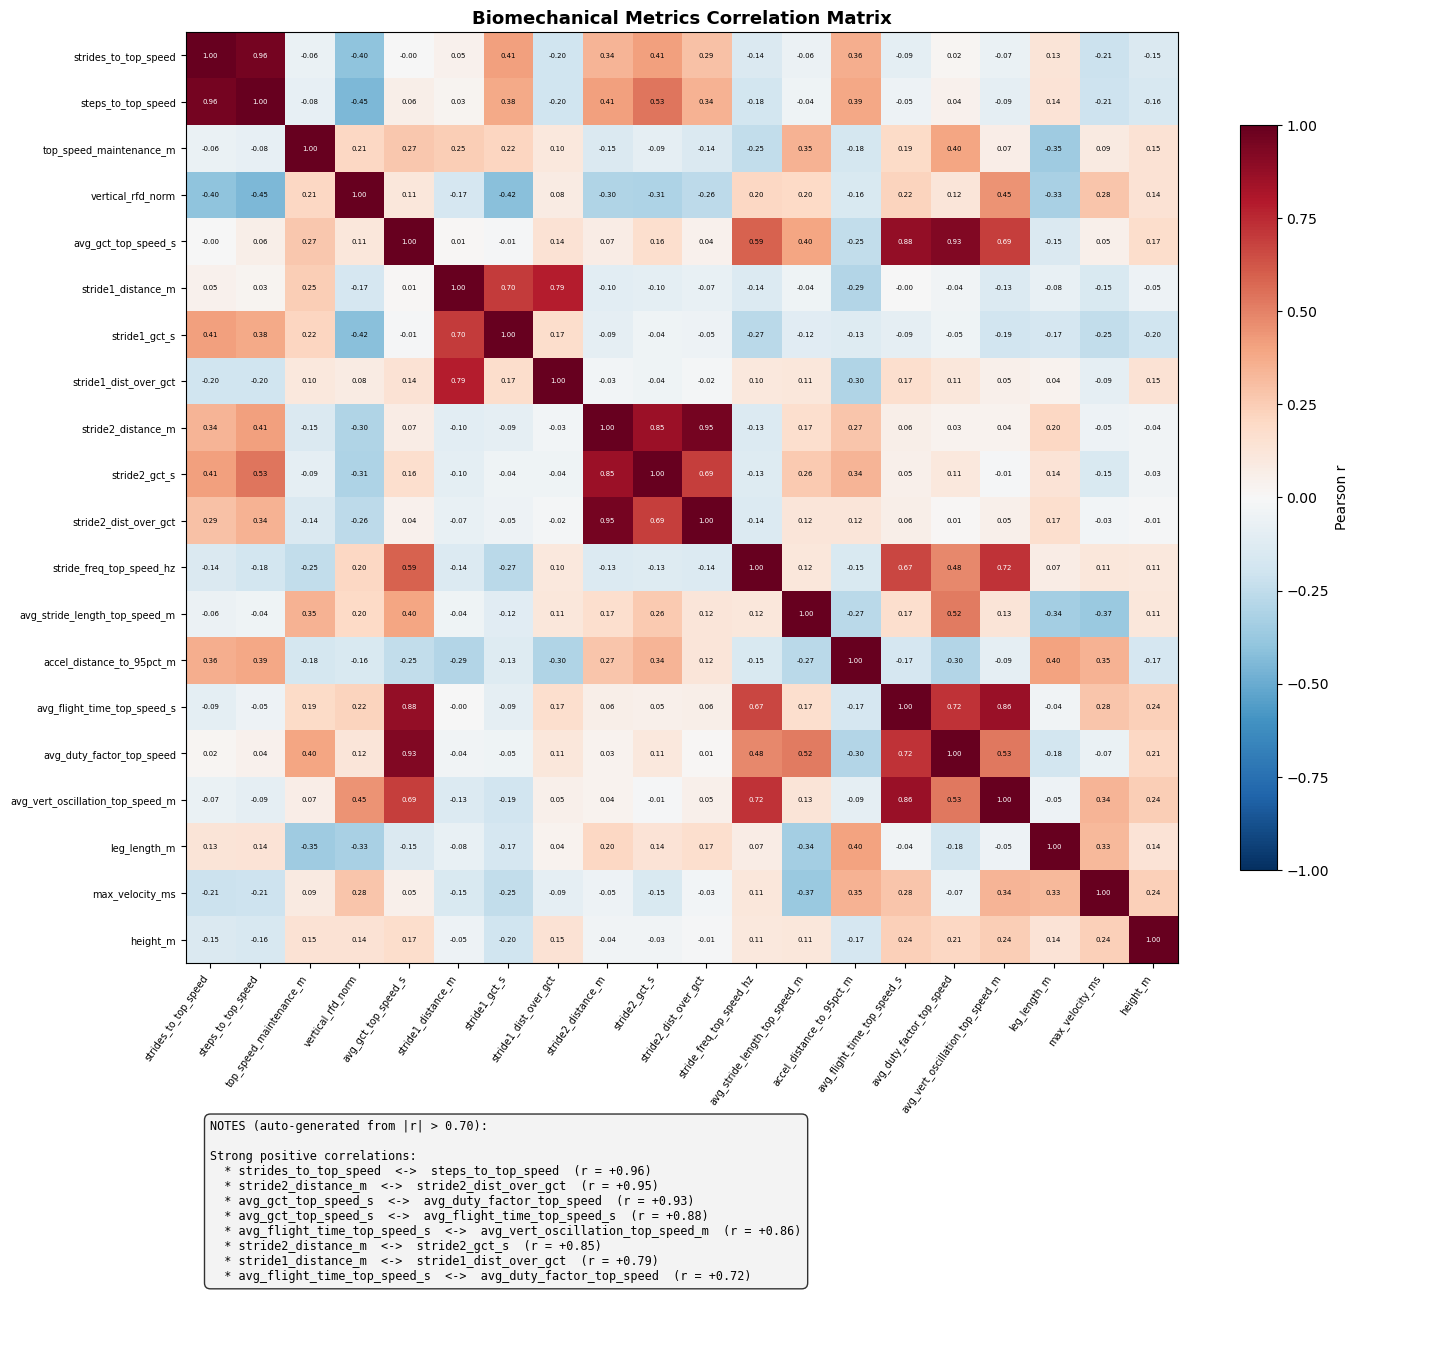

In [9]:
# -- Correlation heatmap: all numeric metrics (with auto-generated notes) --
numeric_cols = [c for c in bio_full.columns
                if bio_full[c].dtype in ['float64', 'int64', 'int32']
                and c != 'participant_id']
corr = bio_full[numeric_cols].corr()

fig = plt.figure(figsize=(16, 17))
gs  = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.25)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=55, ha='right', fontsize=7)
ax.set_yticklabels(numeric_cols, fontsize=7)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=5, color=color)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_title('Biomechanical Metrics Correlation Matrix', fontweight='bold', fontsize=13)

# -- Auto-generate notes: strong correlations --
strong_pos, strong_neg = [], []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        r = corr.iloc[i, j]
        pair = f"{numeric_cols[i]}  <->  {numeric_cols[j]}"
        if r > 0.7:
            strong_pos.append((pair, r))
        elif r < -0.7:
            strong_neg.append((pair, r))
strong_pos.sort(key=lambda x: x[1], reverse=True)
strong_neg.sort(key=lambda x: x[1])

notes_lines = ["NOTES (auto-generated from |r| > 0.70):", ""]
if strong_pos:
    notes_lines.append("Strong positive correlations:")
    for pair, r in strong_pos[:8]:
        notes_lines.append(f"  * {pair}  (r = {r:+.2f})")
if strong_neg:
    notes_lines.append("")
    notes_lines.append("Strong negative correlations:")
    for pair, r in strong_neg[:8]:
        notes_lines.append(f"  * {pair}  (r = {r:+.2f})")
if not strong_pos and not strong_neg:
    notes_lines.append("  No metric pairs exceed |r| > 0.70.")

ax_notes = fig.add_subplot(gs[1])
ax_notes.axis('off')
ax_notes.text(0.02, 0.95, '\n'.join(notes_lines),
              transform=ax_notes.transAxes, fontsize=8.5, fontfamily='monospace',
              verticalalignment='top',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.8))

fig.savefig(str(FIG_DIR / 'biomechanics_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


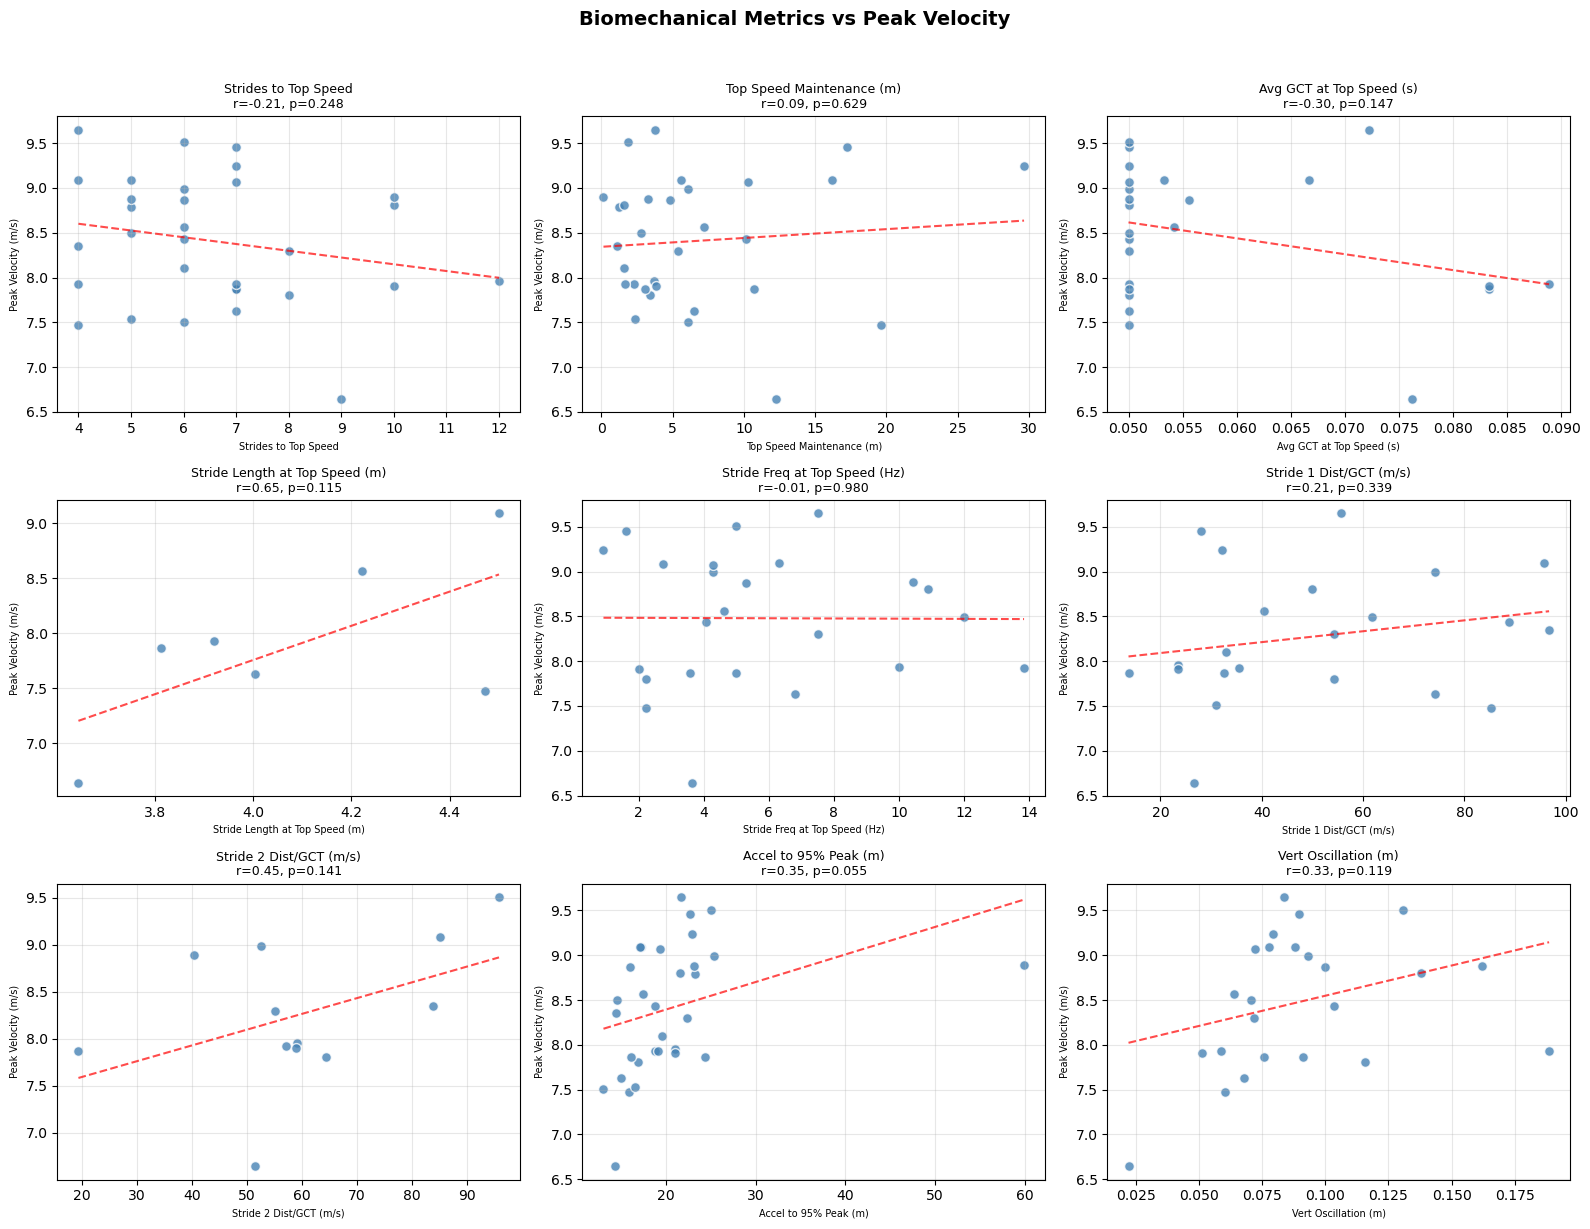

In [10]:
# ── Key metrics vs peak velocity scatter plots ──────────────
scatter_metrics = [
    ('strides_to_top_speed', 'Strides to Top Speed'),
    ('top_speed_maintenance_m', 'Top Speed Maintenance (m)'),
    ('avg_gct_top_speed_s', 'Avg GCT at Top Speed (s)'),
    ('avg_stride_length_top_speed_m', 'Stride Length at Top Speed (m)'),
    ('stride_freq_top_speed_hz', 'Stride Freq at Top Speed (Hz)'),
    ('stride1_dist_over_gct', 'Stride 1 Dist/GCT (m/s)'),
    ('stride2_dist_over_gct', 'Stride 2 Dist/GCT (m/s)'),
    ('accel_distance_to_95pct_m', 'Accel to 95% Peak (m)'),
    ('avg_vert_oscillation_top_speed_m', 'Vert Oscillation (m)'),
]

n_plots = len(scatter_metrics)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, (col, label) in enumerate(scatter_metrics):
    ax = axes[idx]
    x = bio_full[col].values.astype(float)
    y = bio_full['max_velocity_ms'].values.astype(float)
    mask = np.isfinite(x) & np.isfinite(y) & (x != 0)
    ax.scatter(x[mask], y[mask], c='steelblue', edgecolors='white', s=50, alpha=0.8)
    if mask.sum() > 2:
        r, p = pearsonr(x[mask], y[mask])
        z = np.polyfit(x[mask], y[mask], 1)
        poly = np.poly1d(z)
        x_line = np.linspace(x[mask].min(), x[mask].max(), 50)
        ax.plot(x_line, poly(x_line), 'r--', alpha=0.7, lw=1.5)
        sig = '*' if p < 0.05 else ''
        ax.set_title(f'{label}\nr={r:.2f}, p={p:.3f}{sig}', fontsize=9)
    else:
        ax.set_title(label, fontsize=9)
    ax.set_xlabel(label, fontsize=7)
    ax.set_ylabel('Peak Velocity (m/s)', fontsize=7)
    ax.grid(alpha=0.3)

for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Biomechanical Metrics vs Peak Velocity',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'biomechanics_vs_velocity.png'), dpi=150, bbox_inches='tight')
plt.show()


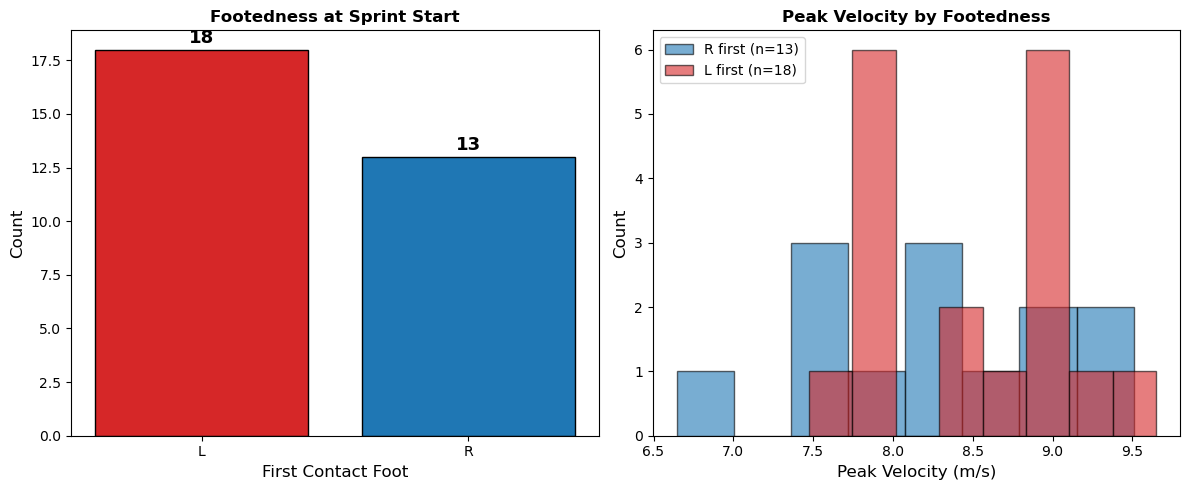

In [11]:
# ── Footedness analysis ──────────────────────────────────────────
foot_counts = bio_full['footedness_stride0'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#1f77b4' if f == 'R' else '#d62728' for f in foot_counts.index]
axes[0].bar(foot_counts.index, foot_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('First Contact Foot', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Footedness at Sprint Start', fontweight='bold')
for i, (foot, count) in enumerate(foot_counts.items()):
    axes[0].text(i, count + 0.3, str(count), ha='center', fontweight='bold', fontsize=13)

# Velocity by footedness
for foot, color in [('R', '#1f77b4'), ('L', '#d62728')]:
    vels = bio_full.loc[bio_full['footedness_stride0'] == foot, 'max_velocity_ms']
    if len(vels) > 0:
        axes[1].hist(vels, bins=8, alpha=0.6, color=color,
                     label=f'{foot} first (n={len(vels)})', edgecolor='black')
axes[1].set_xlabel('Peak Velocity (m/s)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Peak Velocity by Footedness', fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
fig.savefig(str(FIG_DIR / 'footedness_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


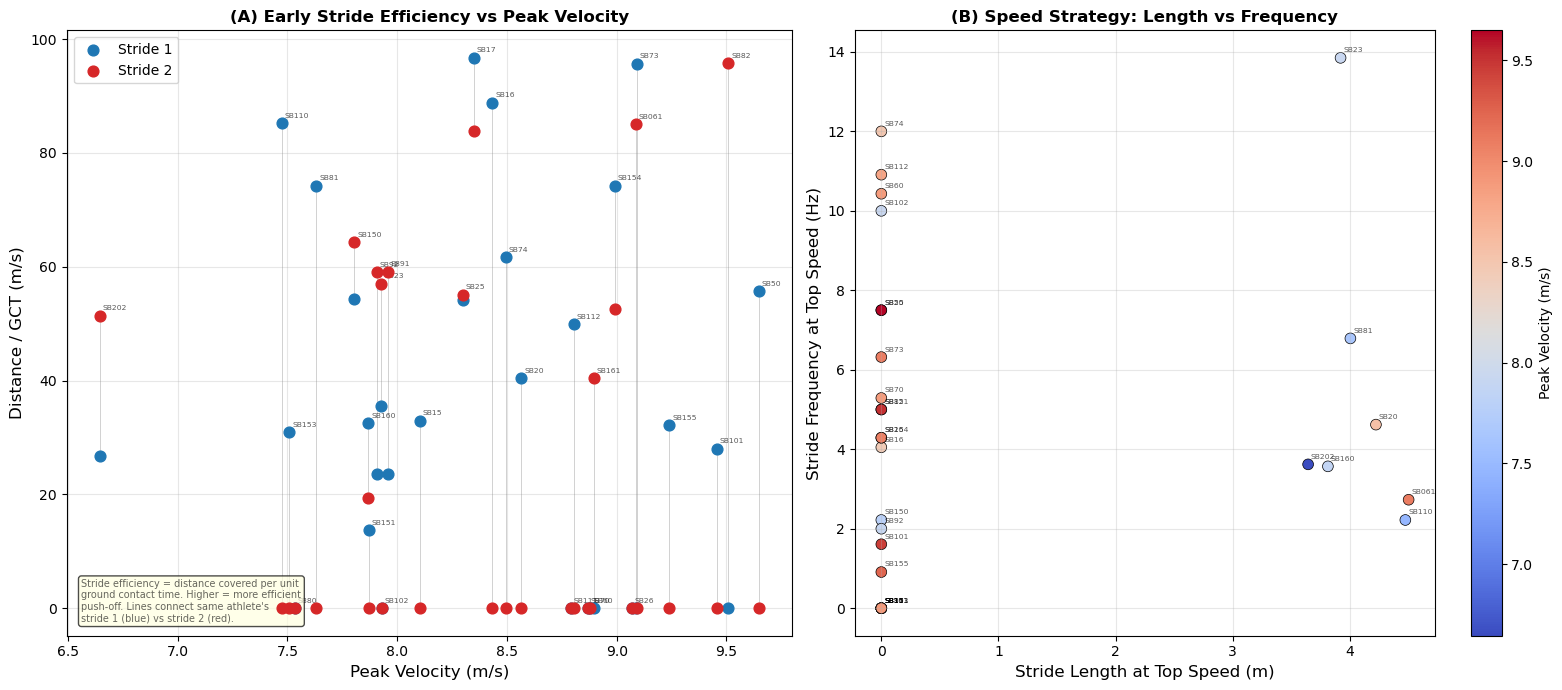

In [12]:
# -- Stride mechanics analysis (with SB# labels) --
sorted_pids = sorted(biomechanics.keys(),
                     key=lambda p: meta_df.loc[meta_df['participant_id']==p, 'max_velocity_ms'].iloc[0] if p in meta_df['participant_id'].values else 0)

s1_ratios = [biomechanics[p]['stride1_dist_over_gct'] for p in sorted_pids]
s2_ratios = [biomechanics[p]['stride2_dist_over_gct'] for p in sorted_pids]
peak_vels = [meta_df.loc[meta_df['participant_id']==p, 'max_velocity_ms'].iloc[0] for p in sorted_pids]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (A) Early stride efficiency
axes[0].scatter(peak_vels, s1_ratios, c='#1f77b4', label='Stride 1', s=60, zorder=5)
axes[0].scatter(peak_vels, s2_ratios, c='#d62728', label='Stride 2', s=60, zorder=5)
for pv, s1, s2, pid in zip(peak_vels, s1_ratios, s2_ratios, sorted_pids):
    axes[0].plot([pv, pv], [s1, s2], 'grey', lw=0.5, alpha=0.5)
    axes[0].annotate(pid, (pv, max(s1, s2)), fontsize=5.5, alpha=0.65,
                     textcoords='offset points', xytext=(2, 4))
axes[0].set_xlabel('Peak Velocity (m/s)', fontsize=12)
axes[0].set_ylabel('Distance / GCT (m/s)', fontsize=12)
axes[0].set_title('(A) Early Stride Efficiency vs Peak Velocity', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(0.02, 0.02,
    'Stride efficiency = distance covered per unit\n'
    'ground contact time. Higher = more efficient\n'
    'push-off. Lines connect same athlete\'s\n'
    'stride 1 (blue) vs stride 2 (red).',
    transform=axes[0].transAxes, fontsize=7, alpha=0.6,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

# (B) Stride length vs frequency (speed strategy)
sl = [biomechanics[p]['avg_stride_length_top_speed_m'] for p in sorted_pids]
sf = [biomechanics[p]['stride_freq_top_speed_hz'] for p in sorted_pids]
sc = axes[1].scatter(sl, sf, c=peak_vels, cmap='coolwarm', s=60,
                     edgecolors='black', linewidths=0.5)
for x, y, pid in zip(sl, sf, sorted_pids):
    axes[1].annotate(pid, (x, y), fontsize=5.5, alpha=0.65,
                     textcoords='offset points', xytext=(2, 4))
axes[1].set_xlabel('Stride Length at Top Speed (m)', fontsize=12)
axes[1].set_ylabel('Stride Frequency at Top Speed (Hz)', fontsize=12)
axes[1].set_title('(B) Speed Strategy: Length vs Frequency', fontweight='bold')
plt.colorbar(sc, ax=axes[1], label='Peak Velocity (m/s)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(str(FIG_DIR / 'stride_mechanics.png'), dpi=150, bbox_inches='tight')
plt.show()


## Figure 4: Velocity–Distance Curves

Velocity profiles across the full 60 m distance for all participants.  
Fastest, median, and slowest sprinters highlighted.


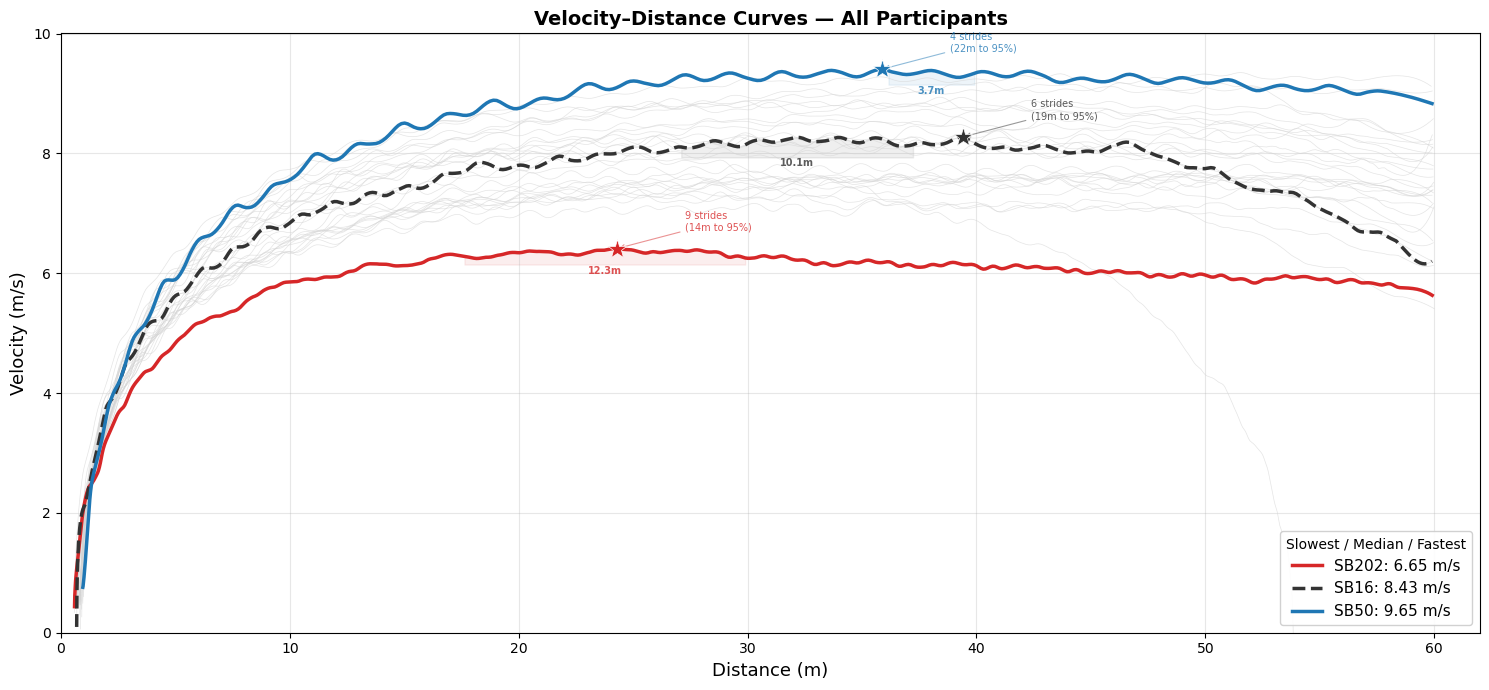

Peak velocities:
  Slowest (SB202): 6.65 m/s
  Median  (SB16):  8.43 m/s
  Fastest (SB50): 9.65 m/s


In [13]:
# -- Velocity-Distance Curves (Enhanced Figure 4) --
from scipy.signal import savgol_filter

COLOR_SLOW = '#d62728'   # red
COLOR_MEAN = '#333333'   # black
COLOR_FAST = '#1f77b4'   # blue

sorted_pids = sorted(velocity_traces.keys(),
                     key=lambda p: velocity_traces[p]['peak_vel'])
n_pids = len(sorted_pids)

slowest_pid = sorted_pids[0]
median_pid  = sorted_pids[n_pids // 2]
fastest_pid = sorted_pids[-1]

fig, ax = plt.subplots(figsize=(15, 7))

# All traces in grey (smoothed)
for pid in sorted_pids:
    vt = velocity_traces[pid]
    d, v = vt['distance_m'], vt['velocity_ms']
    win = min(31, max(5, len(v)//2*2-1))
    if win >= 5 and len(v) >= win:
        v_smooth = savgol_filter(v, win, 3)
    else:
        v_smooth = v
    ax.plot(d, v_smooth, color='lightgrey', lw=0.5, alpha=0.6)

# Highlight 3 key traces with peak markers + maintenance zones
for pid, color, ls in [(slowest_pid, COLOR_SLOW, '-'),
                        (median_pid,  COLOR_MEAN, '--'),
                        (fastest_pid, COLOR_FAST, '-')]:
    vt = velocity_traces[pid]
    d, v = vt['distance_m'], vt['velocity_ms']
    peak_v = vt['peak_vel']

    win = min(31, max(5, len(v)//2*2-1))
    if win >= 5 and len(v) >= win:
        v_smooth = savgol_filter(v, win, 3)
    else:
        v_smooth = v.copy()

    ax.plot(d, v_smooth, color=color, lw=2.5, ls=ls,
            label=f'{pid}: {peak_v:.2f} m/s')

    # Mark peak velocity with star
    peak_idx = int(np.argmax(v_smooth))
    ax.plot(d[peak_idx], v_smooth[peak_idx], marker='*', color=color,
            markersize=14, zorder=10, markeredgecolor='white', markeredgewidth=0.5)

    # Top speed maintenance zone (>= peak_vel - 0.5 m/s)
    thresh = peak_v - 0.5
    above = v >= thresh
    runs = []
    run_start = None
    for i, val in enumerate(above):
        if val and run_start is None:
            run_start = i
        elif not val and run_start is not None:
            runs.append((run_start, i - 1))
            run_start = None
    if run_start is not None:
        runs.append((run_start, len(above) - 1))

    if runs:
        longest = max(runs, key=lambda r: r[1] - r[0])
        maint_d0 = d[longest[0]]
        maint_d1 = d[longest[1]]
        maint_dist = maint_d1 - maint_d0
        # Shaded maintenance zone
        ax.fill_between(d[longest[0]:longest[1]+1],
                        thresh, v_smooth[longest[0]:longest[1]+1],
                        alpha=0.08, color=color)
        ax.annotate(f'{maint_dist:.1f}m', xy=((maint_d0+maint_d1)/2, thresh-0.15),
                    fontsize=7, color=color, ha='center', alpha=0.8, fontweight='bold')

    # Strides to top speed annotation
    if pid in biomechanics:
        strides_ts = biomechanics[pid]['strides_to_top_speed']
        accel_d = biomechanics[pid]['accel_distance_to_95pct_m']
        ax.annotate(f'{strides_ts} strides\n({accel_d:.0f}m to 95%)',
                    xy=(d[peak_idx], v_smooth[peak_idx]),
                    xytext=(d[peak_idx]+3, v_smooth[peak_idx]+0.3),
                    fontsize=7, color=color, alpha=0.8,
                    arrowprops=dict(arrowstyle='->', color=color, alpha=0.5, lw=0.8))

ax.set_xlabel('Distance (m)', fontsize=13)
ax.set_ylabel('Velocity (m/s)', fontsize=13)
ax.set_title('Velocity\u2013Distance Curves \u2014 All Participants',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9,
          title='Slowest / Median / Fastest')
ax.set_xlim(0, 62)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'velocity_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak velocities:')
print(f'  Slowest ({slowest_pid}): {velocity_traces[slowest_pid]["peak_vel"]:.2f} m/s')
print(f'  Median  ({median_pid}):  {velocity_traces[median_pid]["peak_vel"]:.2f} m/s')
print(f'  Fastest ({fastest_pid}): {velocity_traces[fastest_pid]["peak_vel"]:.2f} m/s')


---
# PART II — Functional PCA
## 5. Functional PCA (fPCA)

Each participant's 19,392-element vector is one observation.  
PCA on the (31 × 19,392) matrix extracts the principal modes of **whole-body kinematic variation**.

In [14]:
mu = dataset.mean(axis=0)
X_centred = dataset - mu
y = meta_df['max_velocity_ms'].values

# ── fPCA ──────────────────────────────────────────────────────────────
n_components = min(len(results) - 1, 30)
fpca = PCA(n_components=n_components)
scores = fpca.fit_transform(X_centred)

explained = fpca.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_95 = int(np.searchsorted(cumulative, 0.95) + 1)

# ── Stepwise Regression: fPC scores → peak velocity ──────────────────
# Key finding: speed signal is in HIGHER-ORDER PCs (not the top variance ones).
# Search ALL PCs, not just those explaining ≥95% variance.
# Limit model size to max_pcs to prevent overfitting with n=31.
import statsmodels.api as sm

max_pcs_in_model = min(6, len(results) // 5)  # ~1 predictor per 5 observations
candidate_pcs = list(range(n_components))
selected = []
remaining = list(candidate_pcs)

print(f"Stepwise Regression on ALL {n_components} fPC Scores")
print(f"  (max {max_pcs_in_model} PCs to prevent overfitting with n={len(results)})")
print("=" * 60)

for step in range(max_pcs_in_model):
    best_pval = 1.0
    best_pc = None

    # FORWARD: try adding each remaining PC
    for pc in remaining:
        trial = selected + [pc]
        X_trial = sm.add_constant(scores[:, trial])
        try:
            model = sm.OLS(y, X_trial).fit()
            pval = model.pvalues[-1]
            if pval < best_pval:
                best_pval = pval
                best_pc = pc
        except Exception:
            continue

    if best_pc is not None and best_pval < 0.10:
        selected.append(best_pc)
        remaining.remove(best_pc)
        print(f"  Step {step+1}: ADD PC{best_pc+1} (p={best_pval:.4f}, "
              f"var={explained[best_pc]*100:.1f}%)")

        # BACKWARD: remove PCs that lost significance
        while len(selected) > 1:
            X_sel = sm.add_constant(scores[:, selected])
            model = sm.OLS(y, X_sel).fit()
            pvals = model.pvalues[1:]
            worst_idx = int(np.argmax(pvals))
            if pvals[worst_idx] > 0.10:
                removed = selected.pop(worst_idx)
                remaining.append(removed)
                print(f"           REMOVE PC{removed+1} (p={pvals[worst_idx]:.4f})")
            else:
                break
    else:
        print(f"  Step {step+1}: No PC meets p<0.10 threshold. Stopping.")
        break

# ── Final stepwise model ─────────────────────────────────────────────
RETAINED_PCS = sorted(selected)
RETAINED_PC_LABELS = [f'PC{i+1}' for i in RETAINED_PCS]

if len(RETAINED_PCS) > 0:
    X_final = sm.add_constant(scores[:, RETAINED_PCS])
    final_model = sm.OLS(y, X_final).fit()

    print(f"\n{'='*60}")
    print(f"Stepwise Model: Y = {' + '.join(RETAINED_PC_LABELS)}")
    print(f"  R²     = {final_model.rsquared:.3f}")
    print(f"  Adj R² = {final_model.rsquared_adj:.3f}")
    print(f"  RMSE   = {np.sqrt(final_model.mse_resid):.3f} m/s")
    print(f"  p(F)   = {final_model.f_pvalue:.6f}")
    print(f"\nCoefficients:")
    for i, pc in enumerate(RETAINED_PCS):
        print(f"  PC{pc+1:2d}: coef={final_model.params[i+1]:+.6f}, "
              f"p={final_model.pvalues[i+1]:.4f}, "
              f"var explained={explained[pc]*100:.1f}%")

    # LOO-CV R²
    lr = LinearRegression()
    yp_loo = cross_val_predict(lr, scores[:, RETAINED_PCS], y, cv=LeaveOneOut())
    ss_res = np.sum((y - yp_loo)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2_loo = 1 - ss_res / ss_tot
    print(f"\n  LOO-CV R² = {r2_loo:.3f}")
else:
    print("\nNo PCs selected by stepwise regression.")
    print("Falling back: selecting top PCs by |r| with velocity...")
    pc_cors = [(i, *pearsonr(scores[:, i], y)) for i in range(n_components)]
    pc_cors.sort(key=lambda x: abs(x[1]), reverse=True)
    RETAINED_PCS = [i for i, r, p in pc_cors[:4] if abs(r) > 0.15]
    RETAINED_PC_LABELS = [f'PC{i+1}' for i in RETAINED_PCS]

# ── Univariate PC-velocity correlations ──────────────────────────────
print(f"\nAll PC-velocity correlations (showing |r|>0.15):")
for i in range(n_components):
    r, p = pearsonr(scores[:, i], y)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else chr(8224) if p < 0.10 else ''
    retained = ' <-- RETAINED' if i in RETAINED_PCS else ''
    if abs(r) > 0.15 or i in RETAINED_PCS:
        print(f"  PC{i+1:2d}: r={r:+.3f}, p={p:.4f} {sig}  "
              f"(var={explained[i]*100:.1f}%){retained}")

print(f"\nRetained PCs: {RETAINED_PC_LABELS}")
print(f"Together explain {sum(explained[i] for i in RETAINED_PCS)*100:.1f}% of total variance")

Stepwise Regression on ALL 30 fPC Scores
  (max 6 PCs to prevent overfitting with n=31)
  Step 1: ADD PC8 (p=0.0292, var=1.2%)
  Step 2: ADD PC5 (p=0.0433, var=2.2%)
  Step 3: ADD PC10 (p=0.0381, var=0.7%)
  Step 4: ADD PC7 (p=0.0668, var=1.6%)
  Step 5: ADD PC22 (p=0.0561, var=0.1%)
  Step 6: ADD PC28 (p=0.0570, var=0.0%)

Stepwise Model: Y = PC5 + PC7 + PC8 + PC10 + PC22 + PC28
  R²     = 0.598
  Adj R² = 0.498
  RMSE   = 0.507 m/s
  p(F)   = 0.000638

Coefficients:
  PC 5: coef=+0.046628, p=0.0143, var explained=2.2%
  PC 7: coef=-0.044418, p=0.0429, var explained=1.6%
  PC 8: coef=+0.073655, p=0.0058, var explained=1.2%
  PC10: coef=+0.082652, p=0.0174, var explained=0.7%
  PC22: coef=-0.171500, p=0.0446, var explained=0.1%
  PC28: coef=+0.251039, p=0.0570, var explained=0.0%

  LOO-CV R² = 0.235

All PC-velocity correlations (showing |r|>0.15):
  PC 1: r=-0.228, p=0.2171   (var=47.4%)
  PC 5: r=+0.342, p=0.0599 †  (var=2.2%) <-- RETAINED
  PC 7: r=-0.277, p=0.1319   (var=1.6%) <--

## 6. Scree Plot

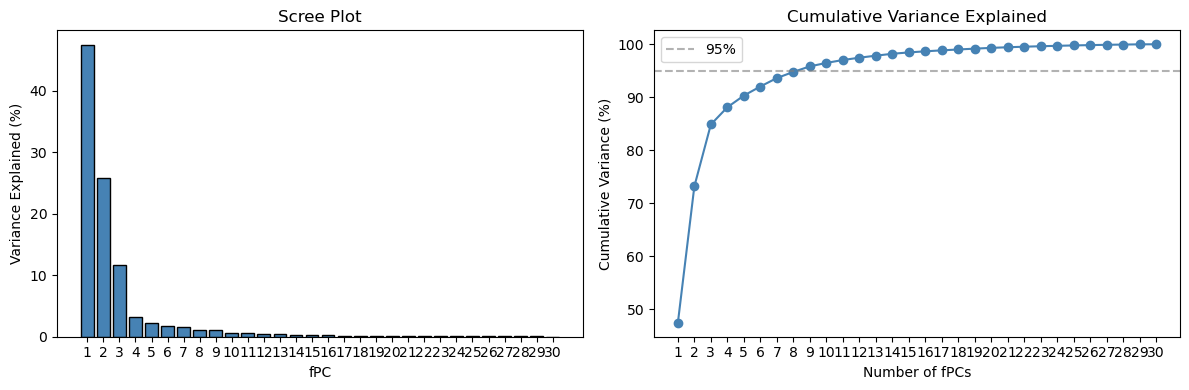

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained)+1), explained*100, color='steelblue', edgecolor='k')
axes[0].set_xlabel('fPC'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot'); axes[0].set_xticks(range(1, len(explained)+1))

axes[1].plot(range(1, len(cumulative)+1), cumulative*100, 'o-', color='steelblue')
axes[1].axhline(95, ls='--', color='grey', alpha=.6, label='95%')
axes[1].set_xlabel('Number of fPCs'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, len(cumulative)+1)); axes[1].legend()

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'scree_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Reconstruct Percentile Postures

$$\mathbf{x}_{\text{recon}} = \boldsymbol{\mu} + s_p \cdot \mathbf{v}_k$$

In [16]:
def reconstruct_percentile(mu, fpca, scores, pc_idx, percentile):
    """SCR: Reconstruct full-body vector at a given percentile of ONE fPC.
    Equations 3-4 from Vellucci & Beaudette (2023)."""
    score_val = np.percentile(scores[:, pc_idx], percentile)
    return mu + score_val * fpca.components_[pc_idx]


def reconstruct_mcr(mu, pca, scores, retained_pcs, percentile):
    """MCR: Multi-Component Reconstruction — combine ALL retained PCs.
    Equations 5-6 from Vellucci & Beaudette (2023):
      x̂_U = x̄ + u₁·z₉₅ + u₂·z₉₅ + ... + u_R·z₉₅
      x̂_L = x̄ + u₁·z₀₅ + u₂·z₀₅ + ... + u_R·z₀₅
    """
    recon = mu.copy()
    for pc_idx in retained_pcs:
        score_val = np.percentile(scores[:, pc_idx], percentile)
        recon += score_val * pca.components_[pc_idx]
    return recon


def vector_to_frames(vector, n_frames=TN_POINTS):
    """Reshape feature vector → (n_frames, n_markers, 3).

    Auto-detects 64-marker (19,392 features) or 23-segment (6,969 features) vectors.
    Vector layout: [X_cols, Y_cols, Z_cols]  where each block = n_markers × n_frames.
    """
    n_total   = len(vector)
    n_markers = n_total // (3 * n_frames)   # 64 (c3d) or 23 (xlsx fallback)
    L = n_markers * n_frames
    x = vector[     :  L].reshape(n_markers, n_frames).T  # (n_frames, n_markers)
    y = vector[  L : 2*L].reshape(n_markers, n_frames).T
    z = vector[2*L :    ].reshape(n_markers, n_frames).T
    return np.stack([x, y, z], axis=-1)   # (n_frames, n_markers, 3)


mean_frames = vector_to_frames(mu)
n_mk = mean_frames.shape[1]
print(f"Mean posture shape : {mean_frames.shape}")
print(f"  Pipeline         : {'64-marker c3d' if n_mk == 64 else '23-segment xlsx'}")
print(f"  Features/vector  : {len(mu):,}")

# Quick sanity: MCR at 5th / 50th / 95th percentile
for pct in [5, 50, 95]:
    v = reconstruct_mcr(mu, fpca, scores, RETAINED_PCS, pct)
    f = vector_to_frames(v)
    print(f"  MCR {pct:3d}th %ile  Z=[{f[:,:,2].min():.3f}, {f[:,:,2].max():.3f}]")


Mean posture shape : (101, 64, 3)
  Pipeline         : 64-marker c3d
  Features/vector  : 19,392
  MCR   5th %ile  Z=[-0.474, 0.195]
  MCR  50th %ile  Z=[-0.292, 0.128]
  MCR  95th %ile  Z=[-0.391, 0.215]


## 8. 64-Marker Skeleton Visualisation (Velluci)

Adapted from Chris Velluci's MATLAB `xsens_scr_frame.m` (64-marker c3d → 64-marker model).

| Chain | Path |
|-------|------|
| Spine | Pelvis(0) → L5(1) → L3(2) → T12(3) → T8(4) → Neck(5) → Head(6) |
| R Arm | T8(4) → R Shoulder(7) → R Upper Arm(8) → R Forearm(9) → R Hand(10) |
| L Arm | T8(4) → L Shoulder(11) → L Upper Arm(12) → L Forearm(13) → L Hand(14) |
| R Leg | Pelvis(0) → R Upper Leg(15) → R Lower Leg(16) → R Foot(17) → R Toe(18) |
| L Leg | Pelvis(0) → L Upper Leg(19) → L Lower Leg(20) → L Foot(21) → L Toe(22) |

In [17]:
# Velluci's 64-marker bone polylines (Python 0-based, extracted from xsens_scr_frame.m)
# Each sub-list is a connected polyline: points are joined sequentially.
SKELETON_BONES = [
    # Axial: pelvis + spine + ribcage + clavicles
    [1,2,4,3,1,5,6,2,6,7,5,7,8,9,10,13,15,20,11,14,10,14,20,14,21,14,11,21,15],
    [21,10], [20,10],
    [16,17,18,16,19,17,19,18,19,15],
    # Right arm
    [20,22,23,28,23,20], [20,28,26,28,27,26],
    [23,26,23,27,26], [22,26,22,27,26],
    [26,32,27,32,33,32,34,32,33,26],
    # Left arm
    [21,24,25,24,31,21], [21,25],
    [29,30,24,29,24,30,24,25,29,25,30,25],
    [31,29,30,29,31,30,31],
    [29,35,29,36,29,37,35,36,30,35,30,36,30,37,30],
    # Right leg
    [38,39,38,40,38,41,40,39,41,46,39,46,40,46],
    [46,47,46,48], [39,47,39,48], [40,47,40,48],
    [47,48,52,47,52,53,52,54,52,55,56,55,57,52],
    # Left leg
    [42,43,42,44,42,45,44,43,45],
    [49,45,49,44,49,43,49],
    [49,50,49,51,49], [43,50,43,51,43], [44,50,44,51,44],
    [50,51,50,58,51,58,59,58,59,58,61,58,60,61,62,61,63],
]

# Height-normalised coords are O(1); multiply by SCALE_MM for mm-like axes
SCALE_MM = 1000


def draw_skeleton_projection(ax, markers, plane='sagittal',
                              color='k', alpha=0.7, lw=1.8,
                              x_offset=0, label=None):
    """Draw a 2-D projection of the Velluci 64-marker skeleton.

    Parameters
    ----------
    markers  : (64, 3) ndarray — one frame, already scaled to mm
    plane    : 'sagittal'   -> AP  (axis 0) × Vert  (side view)
               'frontal'    -> ML  × Vert             (front view)
               'transverse' -> AP  (axis 0) × ML      (top-down view)
    x_offset : horizontal shift for tiling (pass 0 for grid layout)

    Axis auto-detection
    -------------------
    Measures |head_z - pelvis_z| along axis 1 and axis 2.
    Whichever axis shows the larger anatomical head-pelvis separation
    is declared the vertical axis.  This is robust to PCA ordering.
    """
    pts = markers.copy()

    # ── Auto-detect vertical axis ────────────────────────────────────────
    gap1 = abs(float(np.mean(pts[MK_HEAD, 1])) - float(np.mean(pts[MK_PELVIS_ALL, 1])))
    gap2 = abs(float(np.mean(pts[MK_HEAD, 2])) - float(np.mean(pts[MK_PELVIS_ALL, 2])))
    vert_ax = 2 if gap2 >= gap1 else 1
    ml_ax   = 3 - vert_ax   # the other non-AP axis

    # ── Orientation guard: head above pelvis ────────────────────────────
    if float(np.mean(pts[MK_HEAD, vert_ax])) < float(np.mean(pts[MK_PELVIS_ALL, vert_ax])):
        pts[:, vert_ax] = -pts[:, vert_ax]

    # ── Projection pair ──────────────────────────────────────────────────
    if   plane == 'sagittal':    ix, iy = 0,       vert_ax
    elif plane == 'frontal':     ix, iy = ml_ax,   vert_ax
    else:                        ix, iy = 0,       ml_ax    # transverse

    # ── Draw ─────────────────────────────────────────────────────────────
    first = True
    for path in SKELETON_BONES:
        xs = [pts[k, ix] + x_offset for k in path]
        ys = [pts[k, iy]             for k in path]
        kw = dict(color=color, alpha=alpha, lw=lw,
                  solid_capstyle='round', solid_joinstyle='round')
        if first and label:
            ax.plot(xs, ys, label=label, **kw); first = False
        else:
            ax.plot(xs, ys, **kw)
    ax.scatter(pts[:, ix] + x_offset, pts[:, iy],
               s=6, c=color, alpha=alpha, zorder=5, edgecolors='none')


def apply_consistent_skeleton_limits(axes_2d, n_planes, n_events, padding=1.12):
    """Equalise xlim/ylim across all subplots in the same plane row.

    Call AFTER all skeleton drawing so matplotlib has auto-computed limits.

    Parameters
    ----------
    axes_2d  : 2-D ndarray of Axes, shape (n_planes, n_events)
    padding  : fractional whitespace around the union bounding box
    """
    for row in range(n_planes):
        xlims = [axes_2d[row, c].get_xlim() for c in range(n_events)]
        ylims = [axes_2d[row, c].get_ylim() for c in range(n_events)]
        xmin = min(x[0] for x in xlims);  xmax = max(x[1] for x in xlims)
        ymin = min(y[0] for y in ylims);  ymax = max(y[1] for y in ylims)
        xc = (xmin + xmax) / 2;  yc = (ymin + ymax) / 2
        half = max(xmax - xmin, ymax - ymin) / 2 * padding
        for c in range(n_events):
            axes_2d[row, c].set_xlim(xc - half, xc + half)
            axes_2d[row, c].set_ylim(yc - half, yc + half)

# ── Axis-ordering diagnostic ─────────────────────────────────────────────
if 'mu' in dir():
    try:
        _s = vector_to_frames(mu)[50] * SCALE_MM
        _g1 = float(np.mean(_s[MK_HEAD, 1])) - float(np.mean(_s[MK_PELVIS_ALL, 1]))
        _g2 = float(np.mean(_s[MK_HEAD, 2])) - float(np.mean(_s[MK_PELVIS_ALL, 2]))
        _va = 2 if abs(_g2) >= abs(_g1) else 1
        print(f"64-marker skeleton: {len(SKELETON_BONES)} polylines, "
              f"{sum(len(p)-1 for p in SKELETON_BONES)} bone segments")
        print(f"  Axis-1 head-pelvis gap: {_g1:+.0f} mm")
        print(f"  Axis-2 head-pelvis gap: {_g2:+.0f} mm")
        print(f"  -> Vertical axis auto-detected = axis {_va}"
              f" ({'nominal' if _va == 2 else 'SWAPPED — axis mapping corrected'})")
        del _s, _g1, _g2, _va
    except Exception as _e:
        print(f"64-marker skeleton defined ({_e})")
else:
    print(f"64-marker skeleton defined: {len(SKELETON_BONES)} polylines")


## 9. Stride Event Detection & Global Axis Limits

Replace generic stride percentages (0/25/50/75/100%) with **5 biomechanically meaningful events** detected from the mean stride:

| Event | Description | Detection |
|-------|-------------|-----------|
| Full Support | Stance foot directly under COM | min \|right_foot_x − pelvis_x\| (frames 0–30) |
| Toe-Off | Last contact before foot lifts | Right toe z threshold crossing (frames 15–55) |
| Max Projection | COM at highest point (flight) | max pelvis_z (frames 35–70) |
| Strike | Swing leg perpendicular to ground | min \|right_upper_leg_x − pelvis_x\| (frames 60–90) |
| Touchdown | Just before next foot contact | Right foot z approaching minimum (frames 80–100) |

In [18]:
def detect_stride_events_64(frames_64):
    """Detect 5 biomechanical gait events from mean stride (101, 64, 3).

    Events
    ------
    Full Support  : frame 0   -- start of stance phase
    Toe-Off       : max upward R-toe velocity (first half of cycle)
    Max Projection: R heel farthest ahead of pelvis (AP), second half
    Foot Strike   : R heel at lowest vertical point, second half (must be < Touchdown)
    Touchdown     : frame 100 -- end of cycle
    """
    n  = frames_64.shape[0]
    ev = {}
    ev['Full Support']   = 0
    r_toe_vz             = np.gradient(frames_64[:, MK_R_TOE, 2])
    ev['Toe-Off']        = max(5, int(np.argmax(r_toe_vz[:n // 2])))
    proj                 = frames_64[:, MK_R_HEEL, 0] - frames_64[:, MK_PELVIS, 0]
    ev['Max Projection'] = int(np.argmax(proj[n // 2:]) + n // 2)
    # Foot Strike: lowest R-heel Z in second half, but must be < n-1 (Touchdown)
    second_half_z = frames_64[n // 2:, MK_R_HEEL, 2]
    fs_rel = int(np.argmin(second_half_z))
    fs_abs = fs_rel + n // 2
    # Ensure Foot Strike < Touchdown
    if fs_abs >= n - 1:
        second_half_z_sorted_idx = np.argsort(second_half_z)
        for idx in second_half_z_sorted_idx:
            candidate = idx + n // 2
            if candidate < n - 1:
                fs_abs = candidate
                break
        else:
            fs_abs = n - 2
    ev['Foot Strike']    = fs_abs
    ev['Touchdown']      = n - 1
    return ev


mean_frames   = vector_to_frames(mu)
stride_events = detect_stride_events_64(mean_frames)

print("Detected Stride Events (5 gait-cycle phases for SCR):")
print("=" * 52)
for name, fr in stride_events.items():
    pct = fr / (mean_frames.shape[0] - 1) * 100
    print(f"  {name:<20s}  frame {fr:3d}  ({pct:5.1f}% of cycle)")


Detected Stride Events (5 gait-cycle phases for SCR):
  Full Support          frame   0  (  0.0% of cycle)
  Toe-Off               frame  14  ( 14.0% of cycle)
  Max Projection        frame  90  ( 90.0% of cycle)
  Foot Strike           frame  99  ( 99.0% of cycle)
  Touchdown             frame 100  (100.0% of cycle)


---
# PART III — Single Component Reconstruction (SCR)

$$\hat{\mathbf{x}}_U = \bar{\mathbf{x}} + \mathbf{u}_R \cdot z_{95} \qquad \hat{\mathbf{x}}_L = \bar{\mathbf{x}} + \mathbf{u}_R \cdot z_{05}$$

For each retained PC (1, 5, 21, 22), reconstruct the **5th percentile** (blue/slow) and **95th percentile** (red/fast) postures and display at the 5 detected stride events.

## 10. SCR Figures

In [19]:
# ── SCR: Single-Component Reconstruction ─────────────────────────────────────
# 3-plane × n_events grid.  Each subplot overlays 5th / Mean / 95th percentiles.
# Red = 5th %ile (slow)  |  near-black = Mean  |  Blue = 95th %ile (fast)
COLOR_SLOW = '#d62728'
COLOR_MEAN = '#1a1a1a'
COLOR_FAST = '#1f77b4'

event_names  = list(stride_events.keys())
event_frames = [stride_events[n] for n in event_names]
n_events     = len(event_names)
planes       = ['sagittal', 'frontal', 'transverse']
plane_ylbls  = ['Vert (mm)', 'Vert (mm)', 'ML (mm)']

for pi, pc_idx in enumerate(RETAINED_PCS):
    pc_label = f'PC{pc_idx + 1}'
    var_pct  = fpca.explained_variance_ratio_[pc_idx] * 100

    frames_05 = vector_to_frames(reconstruct_percentile(mu, fpca, scores, pc_idx,  5)) * SCALE_MM
    frames_mu = vector_to_frames(mu)                                                   * SCALE_MM
    frames_95 = vector_to_frames(reconstruct_percentile(mu, fpca, scores, pc_idx, 95)) * SCALE_MM

    s05 = np.percentile(scores[:, pc_idx],  5)
    s95 = np.percentile(scores[:, pc_idx], 95)
    print(f"  {pc_label}: 5th={s05:+.3f}  95th={s95:+.3f}")

    fig, axes = plt.subplots(3, n_events,
                             figsize=(3.5 * n_events, 5.5 * 3),
                             constrained_layout=True)
    for row, (plane, ylabel) in enumerate(zip(planes, plane_ylbls)):
        for col, (ev_name, ef) in enumerate(zip(event_names, event_frames)):
            ax = axes[row, col]
            l05 = '5th %ile'  if col == 0 else None
            lmu = 'Mean'      if col == 0 else None
            l95 = '95th %ile' if col == 0 else None
            draw_skeleton_projection(ax, frames_05[ef], plane=plane,
                color=COLOR_SLOW, alpha=0.65, lw=1.8, label=l05)
            draw_skeleton_projection(ax, frames_mu[ef], plane=plane,
                color=COLOR_MEAN, alpha=0.45, lw=1.2, label=lmu)
            draw_skeleton_projection(ax, frames_95[ef], plane=plane,
                color=COLOR_FAST, alpha=0.65, lw=1.8, label=l95)
            ax.set_aspect('equal'); ax.grid(alpha=0.15)
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=10)
                ax.legend(loc='upper left', fontsize=7, framealpha=0.7)
            if row == 0:
                ax.set_title(ev_name.replace(' ', '\n'), fontsize=8, fontweight='bold')

    apply_consistent_skeleton_limits(axes, 3, n_events)
    fig.suptitle(f'SCR — {pc_label}  ({var_pct:.1f}% variance explained)',
                 fontweight='bold', fontsize=13)
    out = FIG_DIR / f'SCR_{pc_label}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved {out.name}")


---
# MCR: Multi-Component Reconstruction (Figure 6)

$$\hat{\mathbf{x}}_U = \bar{\mathbf{x}} + \sum_{i \in R} \mathbf{u}_i \cdot z_{95,i} \qquad \hat{\mathbf{x}}_L = \bar{\mathbf{x}} + \sum_{i \in R} \mathbf{u}_i \cdot z_{05,i}$$

Combines ALL retained PCs simultaneously (Equations 5-6 from Vellucci & Beaudette 2023).
Three plane views at 5 gait cycle points (10%, 25%, 85%, 95%, 100%):
- **(A) Sagittal plane** — side view (AP vs Vertical)
- **(B) Frontal plane** — front view (ML vs Vertical)
- **(C) Transverse plane** — top-down view (AP vs ML)

Colors: **Red** = 5th percentile (slow), **Black** = mean, **Blue** = 95th percentile (fast).

In [20]:
# MCR -- Multi-Component Reconstruction  (3-plane × 5-cycle-position grid)
n_retained = len(RETAINED_PCS)
pc_labels  = [f'PC{i+1}' for i in RETAINED_PCS]
total_var  = sum(fpca.explained_variance_ratio_[i] for i in RETAINED_PCS) * 100
print(f"MCR using {n_retained} PCs: {pc_labels}")
print(f"Total variance captured: {total_var:.1f}%")

mcr_05   = vector_to_frames(reconstruct_mcr(mu, fpca, scores, RETAINED_PCS,  5)) * SCALE_MM
mcr_mean = vector_to_frames(mu)                                                   * SCALE_MM
mcr_95   = vector_to_frames(reconstruct_mcr(mu, fpca, scores, RETAINED_PCS, 95)) * SCALE_MM

cycle_pcts   = [10, 25, 85, 95, 100]
cycle_frames = [min(int(round(p / 100 * (TN_POINTS - 1))), TN_POINTS - 1)
                for p in cycle_pcts]
n_cols = len(cycle_pcts)
planes       = ['sagittal', 'frontal', 'transverse']
plane_ylbls  = ['Vert (mm)', 'Vert (mm)', 'ML (mm)']
panel_ltrs   = ['A', 'B', 'C']
panel_notes  = [
    'Sagittal: forward lean, hip/knee flexion-extension, arm swing',
    'Frontal: lateral trunk sway, hip adduction-abduction',
    'Transverse: pelvic rotation, foot placement',
]

fig, axes = plt.subplots(3, n_cols,
                          figsize=(3.5 * n_cols, 6 * 3),
                          constrained_layout=True)
for row, (plane, ylabel, ltr, note) in enumerate(
        zip(planes, plane_ylbls, panel_ltrs, panel_notes)):
    for col, (pct, fi) in enumerate(zip(cycle_pcts, cycle_frames)):
        ax = axes[row, col]
        l05 = '5th %ile (slow)'  if col == 0 else None
        l50 = 'Mean'             if col == 0 else None
        l95 = '95th %ile (fast)' if col == 0 else None
        draw_skeleton_projection(ax, mcr_05  [fi], plane=plane,
            color=COLOR_SLOW, alpha=0.65, lw=1.8, label=l05)
        draw_skeleton_projection(ax, mcr_mean[fi], plane=plane,
            color=COLOR_MEAN, alpha=0.45, lw=1.2, label=l50)
        draw_skeleton_projection(ax, mcr_95  [fi], plane=plane,
            color=COLOR_FAST, alpha=0.65, lw=1.8, label=l95)
        ax.set_aspect('equal'); ax.grid(alpha=0.15)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=10)
            ax.legend(loc='upper left', fontsize=7, framealpha=0.7)
            ax.text(-0.10, 1.02, ltr, transform=ax.transAxes,
                    fontsize=14, fontweight='bold', va='bottom')
        if row == 0:
            ax.set_title(f'{pct}%', fontsize=9, fontweight='bold')
        if row == len(planes) - 1:
            ax.set_xlabel(f'{pct}% cycle', fontsize=8)
        # ROM annotations at top-speed frames, sagittal only
        if pct in [85, 95] and plane == 'sagittal':
            rom_joints = {'Hip': (MK_PELVIS, 38), 'Knee': (38, 46), 'Ankle': (46, 52)}
            for ji, (jname, (m1, m2)) in enumerate(rom_joints.items()):
                d05 = np.linalg.norm(mcr_05[fi, m1, :2] - mcr_05[fi, m2, :2])
                d95 = np.linalg.norm(mcr_95[fi, m1, :2] - mcr_95[fi, m2, :2])
                rom_diff = abs(d95 - d05)
                if rom_diff > 5:
                    ax.text(0.50, 0.97 - ji * 0.10, f'{jname}: Δ{rom_diff:.0f}mm',
                            transform=ax.transAxes, fontsize=6.5,
                            color='#555555', alpha=0.85, ha='center', va='top')
    axes[row, 0].text(0.0, -0.06, note, transform=axes[row, 0].transAxes,
                      fontsize=7, fontstyle='italic', alpha=0.6, va='top')

apply_consistent_skeleton_limits(axes, 3, n_cols)
pc_str = ', '.join(pc_labels)
fig.suptitle(f'MCR — {pc_str}  |  {total_var:.1f}% variance\n'
             f'Red=5th %ile  |  Black=Mean  |  Blue=95th %ile',
             fontweight='bold', fontsize=13)
out = FIG_DIR / 'MCR_figure6.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")


---
# PART IV -- Overfitting Diagnostics

The stepwise model selects PCs from higher-order components (low variance).
With n=31 and up to 6 predictors, overfitting is a serious concern.
Below we quantify the gap between training R^2 and LOO-CV R^2.


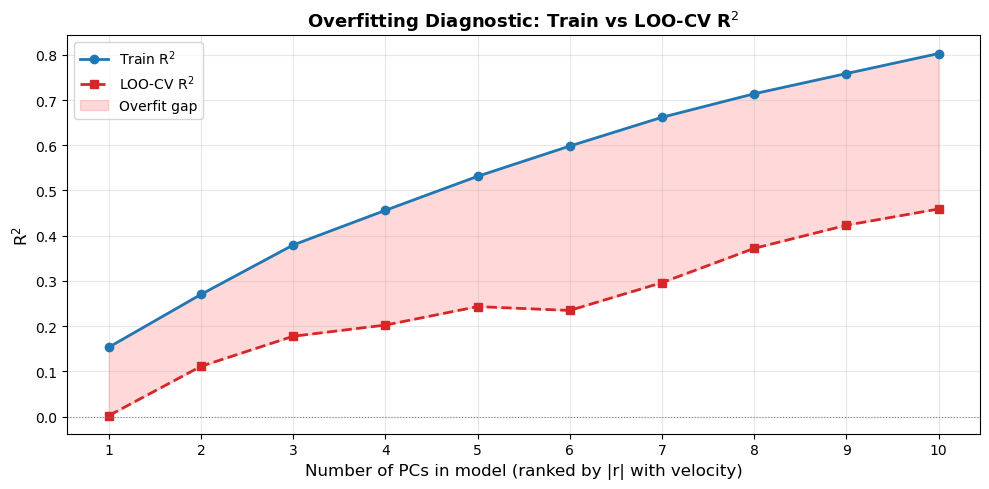

 PCs   Train R2   LOO-CV R2     Gap
-----------------------------------
   1      0.154       0.002     0.151
   2      0.270       0.111     0.159
   3      0.380       0.178     0.202
   4      0.456       0.203     0.254
   5      0.531       0.243     0.288
   6      0.598       0.235     0.363
   7      0.662       0.296     0.366
   8      0.714       0.372     0.342
   9      0.759       0.423     0.335
  10      0.803       0.459     0.344

Stepwise model (6 PCs): Train R2=0.598, LOO-CV R2=0.235
Recommendation: With n=31, models with >3 predictors are prone to overfitting.
LOO-CV is the honest performance estimate.


In [21]:
# -- Overfitting Analysis: Train vs LOO-CV R^2 by number of PCs --
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Sort all PCs by |correlation| with velocity (same ranking stepwise uses)
pc_cors = []
for i in range(scores.shape[1]):
    r_val, _ = pearsonr(scores[:, i], y)
    pc_cors.append((i, abs(r_val)))
pc_cors.sort(key=lambda x: x[1], reverse=True)
top_pcs_by_cor = [x[0] for x in pc_cors]

# Scan: add PCs one at a time (by |r| ranking), track train vs LOO-CV R^2
n_scan = min(10, len(top_pcs_by_cor))
train_r2s, loo_r2s = [], []
for k in range(1, n_scan + 1):
    pcs_k = top_pcs_by_cor[:k]
    X_k = scores[:, pcs_k]
    lr = LinearRegression()
    lr.fit(X_k, y)
    train_r2s.append(r2_score(y, lr.predict(X_k)))
    yp = cross_val_predict(lr, X_k, y, cv=LeaveOneOut())
    loo_r2s.append(r2_score(y, yp))

fig, ax = plt.subplots(figsize=(10, 5))
ks = range(1, n_scan + 1)
ax.plot(ks, train_r2s, 'o-', color='#1f77b4', lw=2, label='Train R$^2$')
ax.plot(ks, loo_r2s,   's--', color='#d62728', lw=2, label='LOO-CV R$^2$')
ax.fill_between(ks, loo_r2s, train_r2s, alpha=0.15, color='red', label='Overfit gap')
ax.axhline(0, color='grey', ls=':', lw=0.8)
ax.set_xlabel('Number of PCs in model (ranked by |r| with velocity)', fontsize=12)
ax.set_ylabel('R$^2$', fontsize=12)
ax.set_title('Overfitting Diagnostic: Train vs LOO-CV R$^2$', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(list(ks))
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'overfitting_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'PCs':>4s}  {'Train R2':>9s}  {'LOO-CV R2':>10s}  {'Gap':>6s}")
print("-" * 35)
for k, tr, lr2 in zip(ks, train_r2s, loo_r2s):
    print(f"  {k:2d}    {tr:7.3f}     {lr2:7.3f}    {tr-lr2:6.3f}")
print()
print(f"Stepwise model ({len(RETAINED_PCS)} PCs): Train R2={train_r2s[len(RETAINED_PCS)-1]:.3f}, LOO-CV R2={loo_r2s[len(RETAINED_PCS)-1]:.3f}")
print(f"Recommendation: With n=31, models with >3 predictors are prone to overfitting.")
print(f"LOO-CV is the honest performance estimate.")


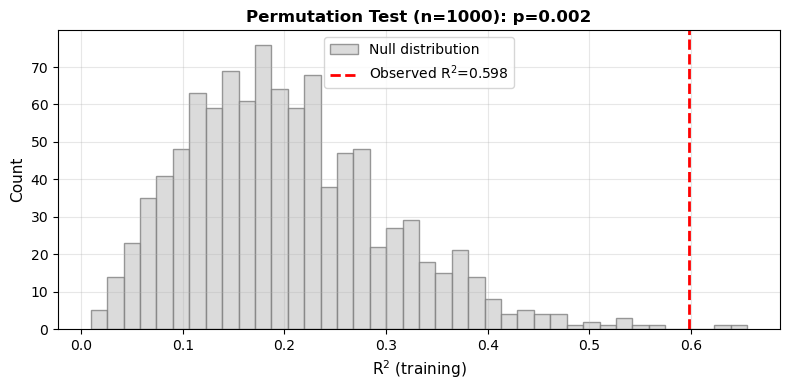

Permutation test p-value: 0.0020
  (p < 0.05 means the stepwise model is unlikely due to chance)


In [22]:
# -- Permutation test: is the stepwise R^2 significant? --
n_perms = 1000
r2_null = []
lr_perm = LinearRegression()
X_step = scores[:, RETAINED_PCS]

for _ in range(n_perms):
    y_shuf = np.random.permutation(y)
    lr_perm.fit(X_step, y_shuf)
    r2_null.append(r2_score(y_shuf, lr_perm.predict(X_step)))

r2_null = np.array(r2_null)
lr_perm.fit(X_step, y)
r2_obs = r2_score(y, lr_perm.predict(X_step))
p_perm = np.mean(r2_null >= r2_obs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r2_null, bins=40, color='lightgrey', edgecolor='grey', alpha=0.8, label='Null distribution')
ax.axvline(r2_obs, color='red', lw=2, ls='--', label=f'Observed R$^2$={r2_obs:.3f}')
ax.set_xlabel('R$^2$ (training)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Permutation Test (n={n_perms}): p={p_perm:.3f}', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Permutation test p-value: {p_perm:.4f}")
print(f"  (p < 0.05 means the stepwise model is unlikely due to chance)")


---
# PART V -- Model Comparison Pipeline

12 regression models evaluated via LOO-CV on two feature sets:
- **A: fPC scores** (30 components) -- kinematic representation
- **B: Biomechanics features** (~20 numeric cols) -- interpretable hand-crafted features

Models: OLS, Ridge, LASSO, Elastic Net, PCR, PLS, Random Forest, XGBoost, SVR, kNN, Bayesian Ridge, and the Stepwise baseline.


In [23]:
# -- Model Comparison: Setup & Evaluation Harness --
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   BayesianRidge, RidgeCV, LassoCV, ElasticNetCV)
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA as skPCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (LeaveOneOut, cross_val_predict,
                                      GridSearchCV, cross_val_score)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import time

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Feature set A: fPC scores
X_A = scores.copy()
# Feature set B: biomechanics features (numeric only, exclude participant_id)
bio_numeric_cols = [c for c in bio_full.columns
                    if bio_full[c].dtype in ['float64', 'int64', 'int32']
                    and c not in ['participant_id', 'max_velocity_ms', 'height_m']]
X_B = bio_full[bio_numeric_cols].values.astype(float)
# Handle any NaN/inf
X_B = np.nan_to_num(X_B, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature set A (fPC scores): {X_A.shape}")
print(f"Feature set B (Biomechanics): {X_B.shape}  cols: {bio_numeric_cols}")
print(f"Target y: {y.shape}, range [{y.min():.2f}, {y.max():.2f}] m/s")
print(f"CV strategy: LOO-CV (n={len(y)} folds)")


Feature set A (fPC scores): (31, 30)
Feature set B (Biomechanics): (31, 18)  cols: ['strides_to_top_speed', 'steps_to_top_speed', 'top_speed_maintenance_m', 'vertical_rfd_norm', 'avg_gct_top_speed_s', 'stride1_distance_m', 'stride1_gct_s', 'stride1_dist_over_gct', 'stride2_distance_m', 'stride2_gct_s', 'stride2_dist_over_gct', 'stride_freq_top_speed_hz', 'avg_stride_length_top_speed_m', 'accel_distance_to_95pct_m', 'avg_flight_time_top_speed_s', 'avg_duty_factor_top_speed', 'avg_vert_oscillation_top_speed_m', 'leg_length_m']
Target y: (31,), range [6.65, 9.65] m/s
CV strategy: LOO-CV (n=31 folds)


In [24]:
# -- Run all 12 models on both feature sets --
loo = LeaveOneOut()
model_results = []

def eval_model(name, pipeline, X, y_true, feat_label):
    t0 = time.time()
    y_pred = cross_val_predict(pipeline, X, y_true, cv=loo)
    r2_loo = r2_score(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    pipeline.fit(X, y_true)
    r2_train = r2_score(y_true, pipeline.predict(X))
    elapsed = time.time() - t0
    res = {
        'Model': name,
        'Features': feat_label,
        'R2_LOO': round(r2_loo, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'R2_train': round(r2_train, 4),
        'Overfit_Gap': round(r2_train - r2_loo, 4),
        'n_features': X.shape[1],
        'time_s': round(elapsed, 1),
        'y_pred_loo': y_pred,
    }
    return res

# -- 1. Stepwise OLS (baseline, fPC scores only) --
print("1/12  Stepwise OLS (baseline)...", flush=True)
X_step = scores[:, RETAINED_PCS]
pipe_step = Pipeline([('model', LinearRegression())])
model_results.append(eval_model('Stepwise OLS', pipe_step, X_step, y, f'A ({len(RETAINED_PCS)} PCs)'))

# -- 2. OLS Linear Regression --
print("2/12  OLS...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
    model_results.append(eval_model('OLS', pipe, X_data, y, fl))

# -- 3. Ridge Regression --
print("3/12  Ridge...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', RidgeCV(alphas=np.logspace(-3, 3, 50)))])
    model_results.append(eval_model('Ridge', pipe, X_data, y, fl))

# -- 4. LASSO --
print("4/12  LASSO...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', LassoCV(alphas=np.logspace(-4, 1, 50),
                                       cv=5, random_state=RANDOM_SEED, max_iter=10000))])
    model_results.append(eval_model('LASSO', pipe, X_data, y, fl))

# -- 5. Elastic Net --
print("5/12  Elastic Net...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95],
                                            alphas=np.logspace(-4, 1, 30),
                                            cv=5, random_state=RANDOM_SEED, max_iter=10000))])
    model_results.append(eval_model('Elastic Net', pipe, X_data, y, fl))

# -- 6. PCR (PCA + OLS on raw 19,392 features) --
print("6/12  PCR...", flush=True)
best_pcr_r2 = -999
best_pcr_n = 1
for n_comp in range(1, 16):
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('pca', skPCA(n_components=n_comp)),
                     ('model', LinearRegression())])
    yp = cross_val_predict(pipe, dataset, y, cv=loo)
    r2 = r2_score(y, yp)
    if r2 > best_pcr_r2:
        best_pcr_r2 = r2
        best_pcr_n = n_comp
pipe_pcr = Pipeline([('scaler', StandardScaler()),
                     ('pca', skPCA(n_components=best_pcr_n)),
                     ('model', LinearRegression())])
model_results.append(eval_model(f'PCR (n={best_pcr_n})', pipe_pcr, dataset, y, f'Raw ({dataset.shape[1]})'))
print(f"  Best PCR: n_components={best_pcr_n}")

# -- 7. PLS Regression --
print("7/12  PLS...", flush=True)
best_pls_r2 = -999
best_pls_n = 1
for n_comp in range(1, 11):
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', PLSRegression(n_components=n_comp))])
    yp = cross_val_predict(pipe, dataset, y, cv=loo)
    r2 = r2_score(y, yp)
    if r2 > best_pls_r2:
        best_pls_r2 = r2
        best_pls_n = n_comp
pipe_pls = Pipeline([('scaler', StandardScaler()),
                     ('model', PLSRegression(n_components=best_pls_n))])
model_results.append(eval_model(f'PLS (n={best_pls_n})', pipe_pls, dataset, y, f'Raw ({dataset.shape[1]})'))
print(f"  Best PLS: n_components={best_pls_n}")

# -- 8. Random Forest --
print("8/12  Random Forest...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', RandomForestRegressor(
                         n_estimators=500, max_depth=5, min_samples_leaf=2,
                         random_state=RANDOM_SEED))])
    model_results.append(eval_model('Random Forest', pipe, X_data, y, fl))

# -- 9. XGBoost --
print("9/12  XGBoost...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', xgb.XGBRegressor(
                         n_estimators=100, max_depth=3, learning_rate=0.1,
                         reg_alpha=1.0, reg_lambda=1.0,
                         random_state=RANDOM_SEED, verbosity=0))])
    model_results.append(eval_model('XGBoost', pipe, X_data, y, fl))

# -- 10. SVR (RBF) --
print("10/12 SVR...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    best_svr_r2 = -999
    best_C, best_g = 1.0, 'scale'
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            pipe = Pipeline([('scaler', StandardScaler()),
                             ('model', SVR(C=C, gamma=gamma))])
            yp = cross_val_predict(pipe, X_data, y, cv=loo)
            r2 = r2_score(y, yp)
            if r2 > best_svr_r2:
                best_svr_r2, best_C, best_g = r2, C, gamma
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', SVR(C=best_C, gamma=best_g))])
    model_results.append(eval_model(f'SVR (C={best_C})', pipe, X_data, y, fl))

# -- 11. kNN Regression --
print("11/12 kNN...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    best_knn_r2 = -999
    best_k = 5
    for k in [3, 5, 7, 9]:
        pipe = Pipeline([('scaler', StandardScaler()),
                         ('model', KNeighborsRegressor(n_neighbors=k))])
        yp = cross_val_predict(pipe, X_data, y, cv=loo)
        r2 = r2_score(y, yp)
        if r2 > best_knn_r2:
            best_knn_r2, best_k = r2, k
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', KNeighborsRegressor(n_neighbors=best_k))])
    model_results.append(eval_model(f'kNN (k={best_k})', pipe, X_data, y, fl))

# -- 12. Bayesian Ridge --
print("12/12 Bayesian Ridge...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', BayesianRidge())])
    model_results.append(eval_model('Bayesian Ridge', pipe, X_data, y, fl))

print(f"\nAll {len(model_results)} model-feature combinations evaluated.")


1/12  Stepwise OLS (baseline)...


2/12  OLS...


3/12  Ridge...


4/12  LASSO...


5/12  Elastic Net...


...

9/12  XGBoost...


10/12 SVR...


11/12 kNN...


12/12 Bayesian Ridge...



All 21 model-feature combinations evaluated.


MODEL COMPARISON TABLE  (sorted by LOO-CV R^2)
         Model    Features  R2_LOO   RMSE    MAE  R2_train  Overfit_Gap  n_features  time_s
  Stepwise OLS   A (6 PCs)  0.2348 0.6162 0.4999    0.5983       0.3634           6     0.0
     kNN (k=3)     B (Bio)  0.1179 0.6616 0.5414    0.4591       0.3411          18     0.0
 Random Forest     B (Bio)  0.0706 0.6791 0.5990    0.8231       0.7526          18    11.2
     PLS (n=4) Raw (19392)  0.0528 0.6856 0.5634    0.7199       0.6671       19392     6.7
    SVR (C=10)     B (Bio)  0.0409 0.6899 0.5681    0.9799       0.9390          18     0.0
       XGBoost     A (fPC)  0.0388 0.6907 0.5467    0.9257       0.8869          30     0.7
     PCR (n=5) Raw (19392)  0.0203 0.6973 0.5474    0.2948       0.2745       19392    15.3
           OLS     A (fPC) -0.0035 0.7057 0.6091    1.0000       1.0035          30     0.0
Bayesian Ridge     A (fPC) -0.0035 0.7057 0.6091    1.0000       1.0035          30     0.1
         Ridge     A (fPC) -0.019

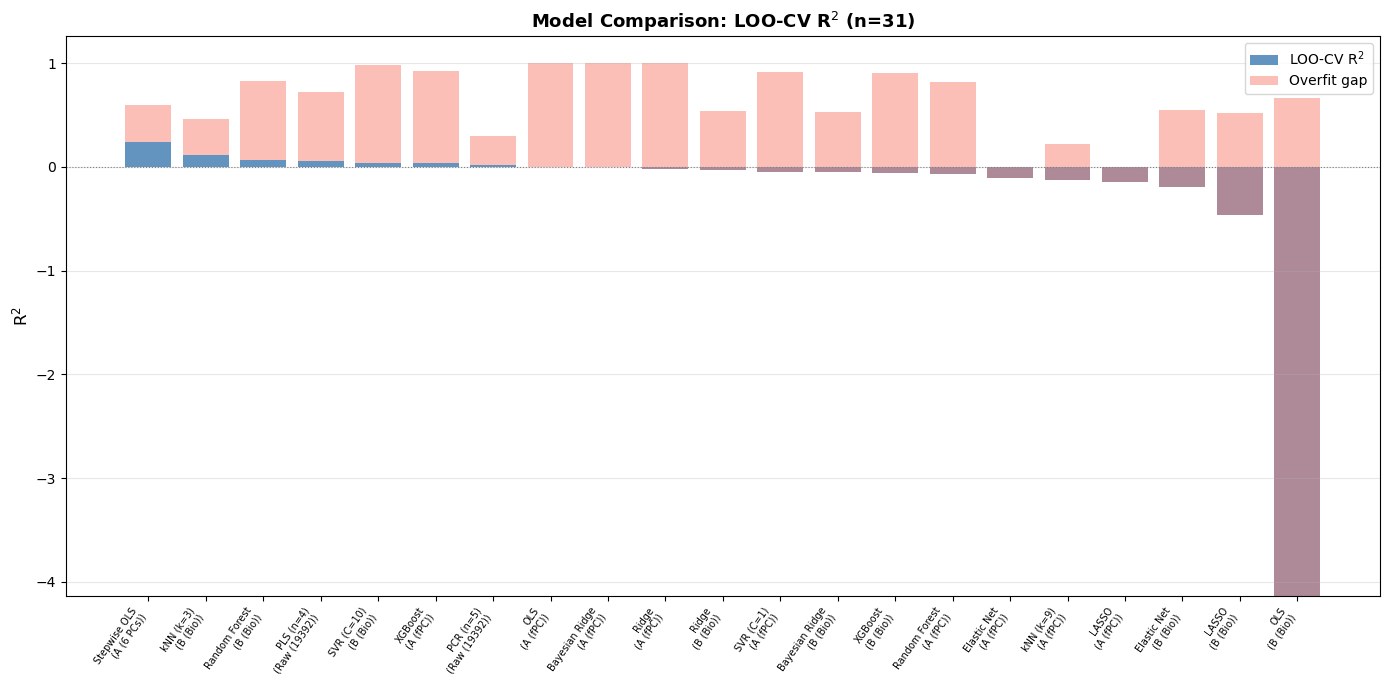

In [25]:
# -- Model Comparison Table (sorted by LOO-CV R^2) --
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred_loo'}
                            for r in model_results])
results_df = results_df.sort_values('R2_LOO', ascending=False).reset_index(drop=True)

# Display
print("=" * 100)
print("MODEL COMPARISON TABLE  (sorted by LOO-CV R^2)")
print("=" * 100)
print(results_df.to_string(index=False))
print()

# Highlight best
best = results_df.iloc[0]
print(f"BEST MODEL: {best['Model']} ({best['Features']})")
print(f"  R^2_LOO = {best['R2_LOO']:.4f},  RMSE = {best['RMSE']:.4f} m/s,  Overfit gap = {best['Overfit_Gap']:.4f}")

# Save table
results_df.to_csv(str(DATA_DIR / 'model_comparison.csv'), index=False)
print(f"\nSaved: {DATA_DIR / 'model_comparison.csv'}")

# -- Bar chart --
fig, ax = plt.subplots(figsize=(14, 7))
labels = [f"{r['Model']}\n({r['Features']})" for _, r in results_df.iterrows()]
x = range(len(labels))
bars_loo = ax.bar(x, results_df['R2_LOO'], color='steelblue', alpha=0.85, label='LOO-CV R$^2$')
ax.bar(x, results_df['Overfit_Gap'], bottom=results_df['R2_LOO'],
       color='salmon', alpha=0.5, label='Overfit gap')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=7)
ax.set_ylabel('R$^2$', fontsize=12)
ax.set_title('Model Comparison: LOO-CV R$^2$ (n=31)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.axhline(0, color='grey', ls=':', lw=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


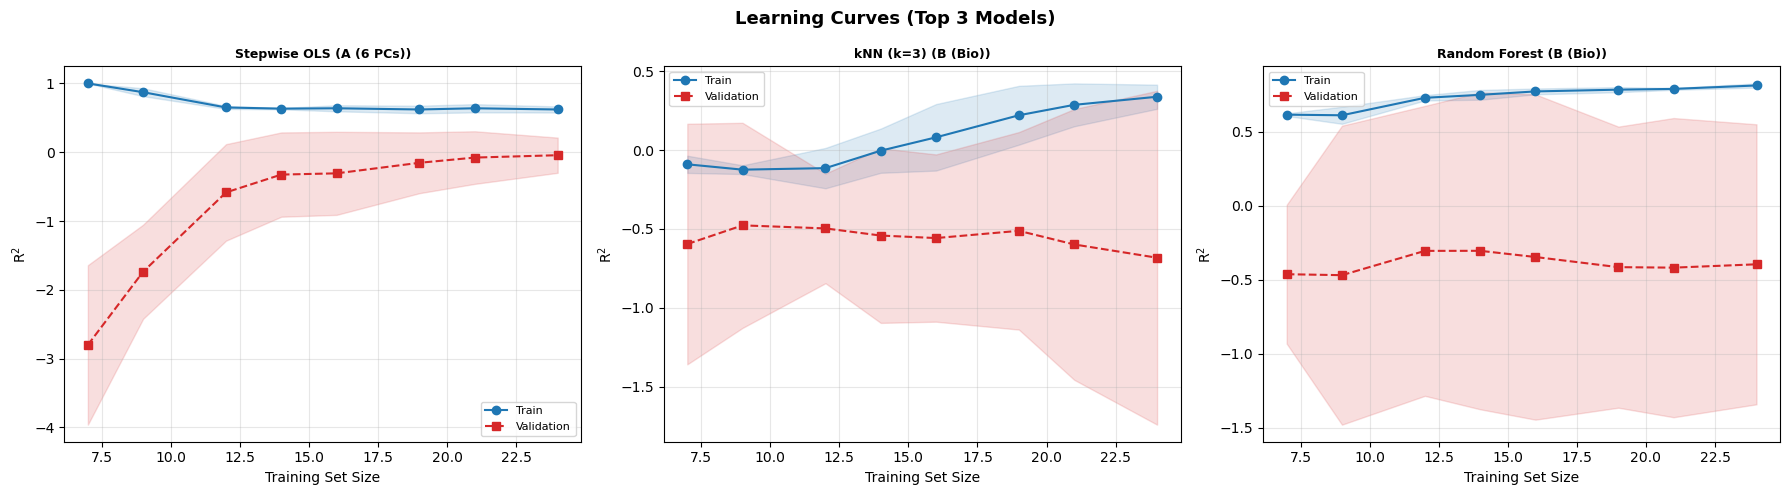

In [26]:
# -- Learning Curves for top 3 models --
from sklearn.model_selection import learning_curve

top3 = results_df.head(3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (_, row) in enumerate(top3.iterrows()):
    name = f"{row['Model']} ({row['Features']})"
    # Reconstruct the model
    feat_label = row['Features']
    if 'fPC' in feat_label:
        X_lc = X_A
    elif 'Bio' in feat_label:
        X_lc = X_B
    elif 'Raw' in feat_label:
        X_lc = dataset
    else:
        X_lc = scores[:, RETAINED_PCS]

    # Simple pipeline for learning curve
    if 'Ridge' in row['Model'] and 'Bayesian' not in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
    elif 'LASSO' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.1, max_iter=10000))])
    elif 'Elastic' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))])
    elif 'RF' in row['Model'] or 'Random' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=2, random_state=RANDOM_SEED))])
    elif 'XGB' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=RANDOM_SEED, verbosity=0))])
    elif 'SVR' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', SVR(C=1.0))])
    elif 'kNN' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=5))])
    elif 'Bayesian' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', BayesianRidge())])
    elif 'PLS' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', PLSRegression(n_components=2))])
    elif 'PCR' in row['Model']:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('pca', skPCA(n_components=3)), ('model', LinearRegression())])
    else:
        pipe_lc = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])

    train_sizes = np.linspace(0.3, 1.0, 8)
    try:
        train_sz, train_sc, val_sc = learning_curve(
            pipe_lc, X_lc, y, train_sizes=train_sizes,
            cv=min(5, len(y)-1), scoring='r2', random_state=RANDOM_SEED)
        ax = axes[idx]
        ax.plot(train_sz, train_sc.mean(axis=1), 'o-', color='#1f77b4', label='Train')
        ax.fill_between(train_sz, train_sc.mean(axis=1)-train_sc.std(axis=1),
                        train_sc.mean(axis=1)+train_sc.std(axis=1), alpha=0.15, color='#1f77b4')
        ax.plot(train_sz, val_sc.mean(axis=1), 's--', color='#d62728', label='Validation')
        ax.fill_between(train_sz, val_sc.mean(axis=1)-val_sc.std(axis=1),
                        val_sc.mean(axis=1)+val_sc.std(axis=1), alpha=0.15, color='#d62728')
        ax.set_xlabel('Training Set Size', fontsize=10)
        ax.set_ylabel('R$^2$', fontsize=10)
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Error: {str(e)[:50]}', transform=axes[idx].transAxes,
                       ha='center', va='center', fontsize=8)
        axes[idx].set_title(name, fontsize=9)

plt.suptitle('Learning Curves (Top 3 Models)', fontweight='bold', fontsize=13)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


---
# PART VI -- Explainability

Interpreting model predictions:
1. Linear model coefficient analysis (Ridge/LASSO/Elastic Net)
2. LASSO coefficient path (stability across regularization)
3. Tree-based feature importance (Random Forest, XGBoost + SHAP)
4. Feature stability via bootstrap LASSO


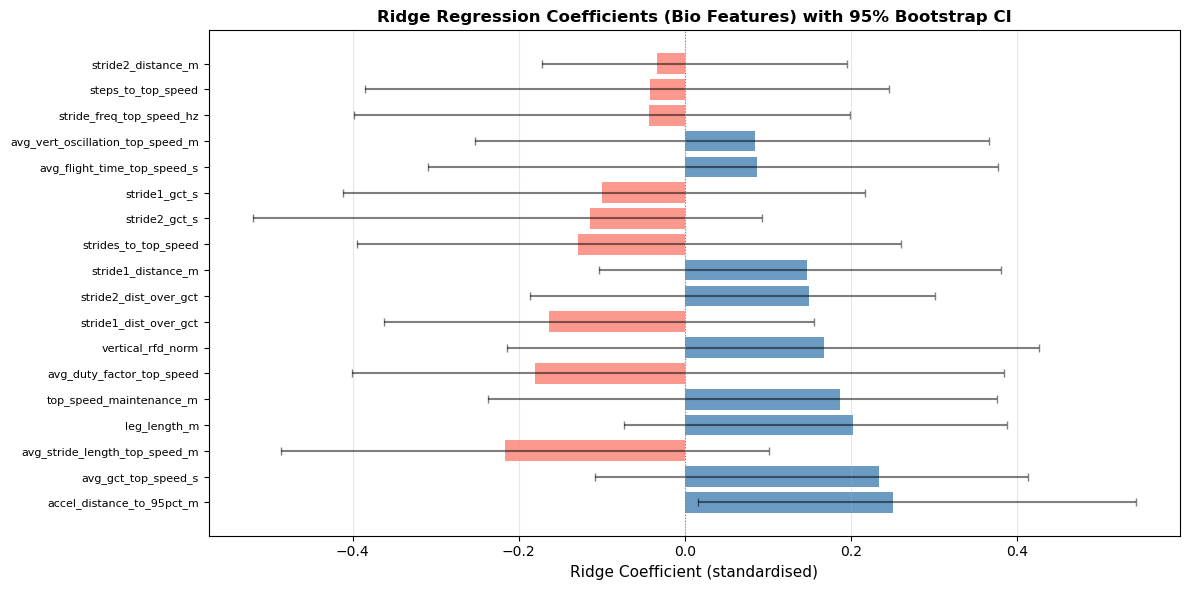

In [27]:
# -- Linear Model Coefficients (with bootstrap 95% CIs) --
from sklearn.utils import resample

# Fit Ridge on bio features for interpretability
ridge_bio = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
ridge_bio.fit(X_B, y)
coefs = ridge_bio.named_steps['model'].coef_

# Bootstrap CIs
n_boot = 200
boot_coefs = np.zeros((n_boot, X_B.shape[1]))
for b in range(n_boot):
    X_b, y_b = resample(X_B, y, random_state=RANDOM_SEED + b)
    ridge_b = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
    ridge_b.fit(X_b, y_b)
    boot_coefs[b] = ridge_b.named_steps['model'].coef_

ci_lo = np.percentile(boot_coefs, 2.5, axis=0)
ci_hi = np.percentile(boot_coefs, 97.5, axis=0)

# Sort by absolute coefficient
sort_idx = np.argsort(np.abs(coefs))[::-1]
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(bio_numeric_cols))
ax.barh(x, coefs[sort_idx], color=['steelblue' if c > 0 else 'salmon' for c in coefs[sort_idx]],
        alpha=0.8)
ax.errorbar(coefs[sort_idx], x,
            xerr=[coefs[sort_idx] - ci_lo[sort_idx], ci_hi[sort_idx] - coefs[sort_idx]],
            fmt='none', color='black', alpha=0.5, capsize=3)
ax.set_yticks(x)
ax.set_yticklabels([bio_numeric_cols[i] for i in sort_idx], fontsize=8)
ax.set_xlabel('Ridge Coefficient (standardised)', fontsize=11)
ax.set_title('Ridge Regression Coefficients (Bio Features) with 95% Bootstrap CI',
             fontweight='bold', fontsize=12)
ax.axvline(0, color='grey', ls=':', lw=0.8)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'ridge_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()


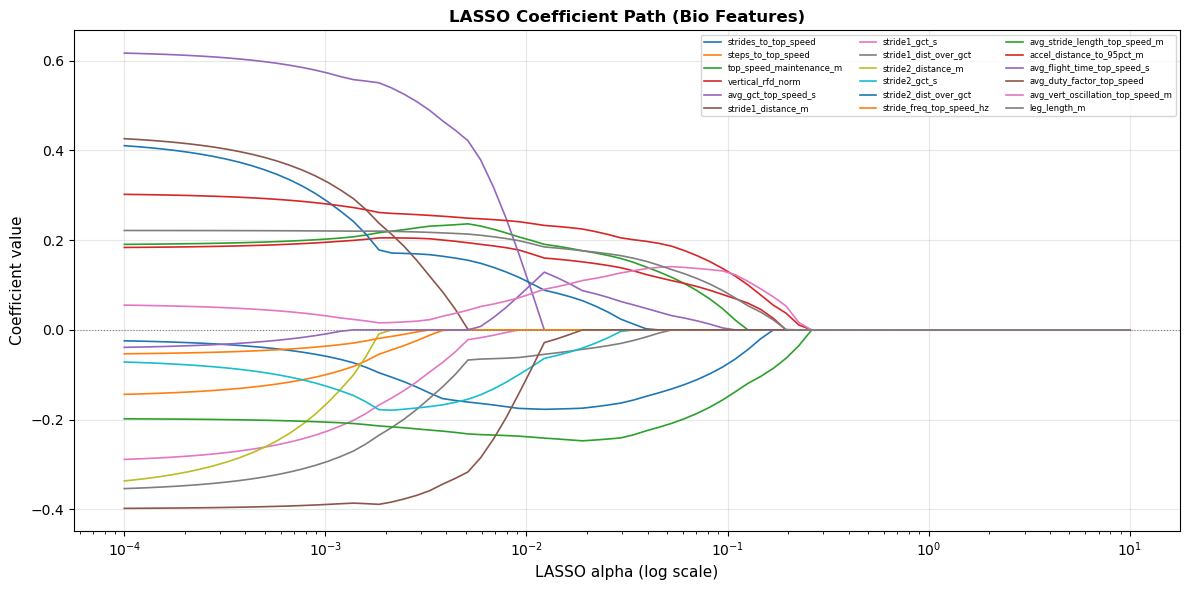

In [28]:
# -- LASSO Coefficient Path --
alphas_path = np.logspace(-4, 1, 80)
coef_paths = np.zeros((len(alphas_path), X_B.shape[1]))
scaler_path = StandardScaler()
X_B_scaled = scaler_path.fit_transform(X_B)

for ai, alpha in enumerate(alphas_path):
    lasso = Lasso(alpha=alpha, max_iter=20000)
    lasso.fit(X_B_scaled, y)
    coef_paths[ai] = lasso.coef_

fig, ax = plt.subplots(figsize=(12, 6))
for j in range(X_B.shape[1]):
    ax.plot(alphas_path, coef_paths[:, j], lw=1.2, label=bio_numeric_cols[j])
ax.set_xscale('log')
ax.set_xlabel('LASSO alpha (log scale)', fontsize=11)
ax.set_ylabel('Coefficient value', fontsize=11)
ax.set_title('LASSO Coefficient Path (Bio Features)', fontweight='bold', fontsize=12)
ax.legend(fontsize=6, ncol=3, loc='upper right')
ax.axhline(0, color='grey', ls=':', lw=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'lasso_coefficient_path.png'), dpi=150, bbox_inches='tight')
plt.show()


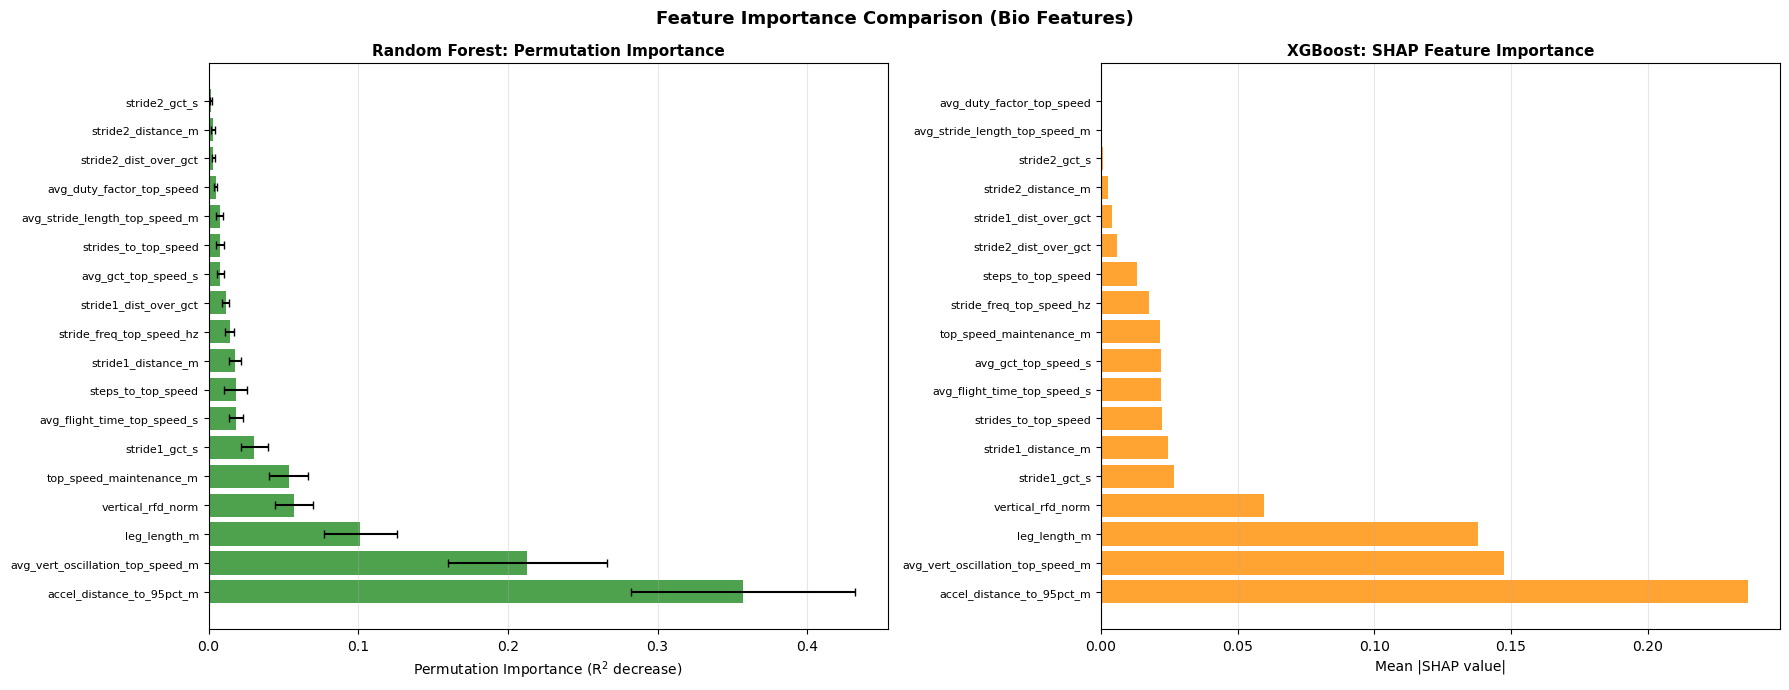


SHAP Beeswarm Plot:


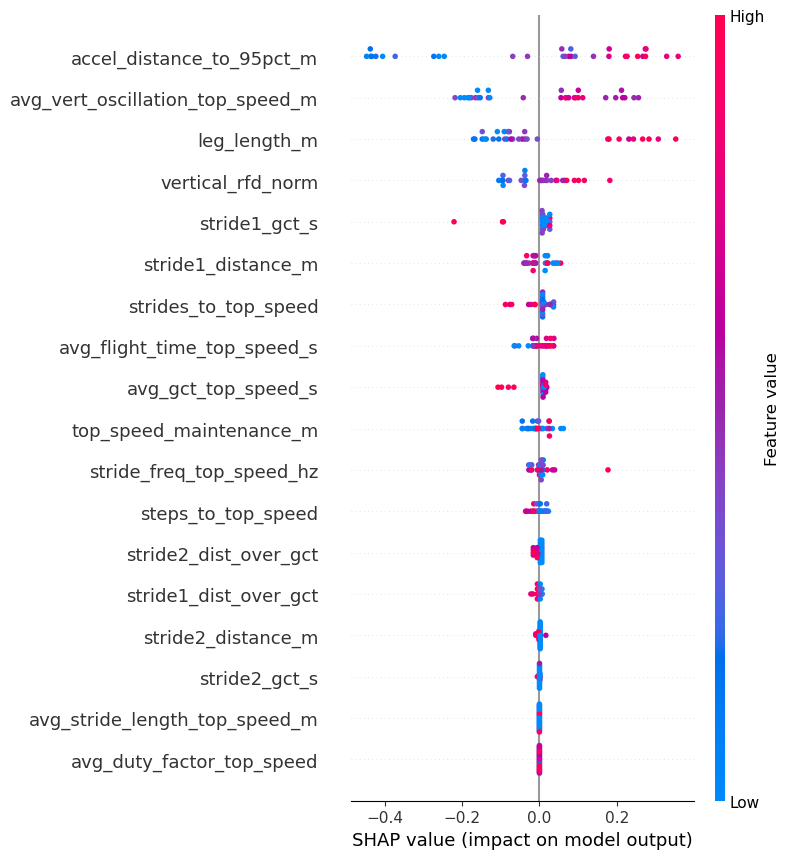

In [29]:
# -- Feature Importance: Random Forest Permutation + XGBoost SHAP --
from sklearn.inspection import permutation_importance
import shap

# Random Forest permutation importance
rf_bio = Pipeline([('scaler', StandardScaler()),
                   ('model', RandomForestRegressor(n_estimators=500, max_depth=5,
                                                    min_samples_leaf=2, random_state=RANDOM_SEED))])
rf_bio.fit(X_B, y)
perm_imp = permutation_importance(rf_bio, X_B, y, n_repeats=30,
                                   random_state=RANDOM_SEED, scoring='r2')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: RF permutation importance
sort_idx = perm_imp.importances_mean.argsort()[::-1]
axes[0].barh(range(len(bio_numeric_cols)),
             perm_imp.importances_mean[sort_idx],
             xerr=perm_imp.importances_std[sort_idx],
             color='forestgreen', alpha=0.8, capsize=3)
axes[0].set_yticks(range(len(bio_numeric_cols)))
axes[0].set_yticklabels([bio_numeric_cols[i] for i in sort_idx], fontsize=8)
axes[0].set_xlabel('Permutation Importance (R$^2$ decrease)', fontsize=10)
axes[0].set_title('Random Forest: Permutation Importance', fontweight='bold', fontsize=11)
axes[0].grid(alpha=0.3, axis='x')

# Right: XGBoost SHAP
xgb_bio = Pipeline([('scaler', StandardScaler()),
                    ('model', xgb.XGBRegressor(n_estimators=100, max_depth=3,
                                                learning_rate=0.1, reg_alpha=1.0,
                                                reg_lambda=1.0, random_state=RANDOM_SEED,
                                                verbosity=0))])
xgb_bio.fit(X_B, y)
X_B_scaled = xgb_bio.named_steps['scaler'].transform(X_B)
explainer = shap.TreeExplainer(xgb_bio.named_steps['model'])
shap_values = explainer.shap_values(X_B_scaled)

# SHAP bar summary
shap_mean = np.abs(shap_values).mean(axis=0)
sort_shap = np.argsort(shap_mean)[::-1]
axes[1].barh(range(len(bio_numeric_cols)), shap_mean[sort_shap],
             color='darkorange', alpha=0.8)
axes[1].set_yticks(range(len(bio_numeric_cols)))
axes[1].set_yticklabels([bio_numeric_cols[i] for i in sort_shap], fontsize=8)
axes[1].set_xlabel('Mean |SHAP value|', fontsize=10)
axes[1].set_title('XGBoost: SHAP Feature Importance', fontweight='bold', fontsize=11)
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Feature Importance Comparison (Bio Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# SHAP beeswarm plot
print("\nSHAP Beeswarm Plot:")
fig_shap = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_B_scaled, feature_names=bio_numeric_cols, show=False)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()


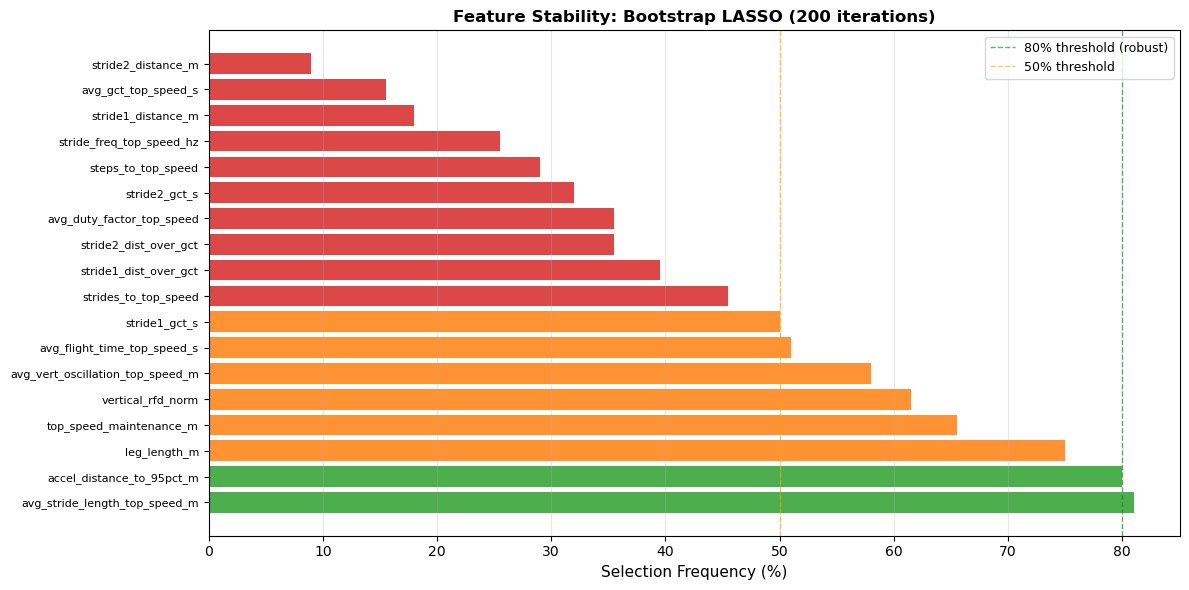


Robust predictors (selected >80% of bootstrap iterations):
  avg_stride_length_top_speed_m             81%
  accel_distance_to_95pct_m                 80%

Moderate predictors (50-80%):
  leg_length_m                              75%
  top_speed_maintenance_m                   66%
  vertical_rfd_norm                         62%
  avg_vert_oscillation_top_speed_m          58%
  avg_flight_time_top_speed_s               51%
  stride1_gct_s                             50%


In [30]:
# -- Feature Stability: Bootstrap LASSO --
n_boot_lasso = 200
selection_counts = np.zeros(X_B.shape[1])
scaler_stab = StandardScaler()
X_B_s = scaler_stab.fit_transform(X_B)

for b in range(n_boot_lasso):
    X_b, y_b = resample(X_B_s, y, random_state=RANDOM_SEED + b)
    lasso_b = LassoCV(alphas=np.logspace(-4, 1, 30), cv=5, max_iter=10000,
                       random_state=RANDOM_SEED + b)
    lasso_b.fit(X_b, y_b)
    selection_counts += (np.abs(lasso_b.coef_) > 1e-6).astype(int)

stability_pct = selection_counts / n_boot_lasso * 100
sort_stab = np.argsort(stability_pct)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ca02c' if s >= 80 else '#ff7f0e' if s >= 50 else '#d62728'
          for s in stability_pct[sort_stab]]
ax.barh(range(len(bio_numeric_cols)), stability_pct[sort_stab], color=colors, alpha=0.85)
ax.set_yticks(range(len(bio_numeric_cols)))
ax.set_yticklabels([bio_numeric_cols[i] for i in sort_stab], fontsize=8)
ax.set_xlabel('Selection Frequency (%)', fontsize=11)
ax.set_title(f'Feature Stability: Bootstrap LASSO ({n_boot_lasso} iterations)',
             fontweight='bold', fontsize=12)
ax.axvline(80, color='green', ls='--', lw=1, alpha=0.6, label='80% threshold (robust)')
ax.axvline(50, color='orange', ls='--', lw=1, alpha=0.6, label='50% threshold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'feature_stability.png'), dpi=150, bbox_inches='tight')
plt.show()

# Report robust features
print("\nRobust predictors (selected >80% of bootstrap iterations):")
for i in sort_stab:
    if stability_pct[i] >= 80:
        print(f"  {bio_numeric_cols[i]:40s}  {stability_pct[i]:.0f}%")
print("\nModerate predictors (50-80%):")
for i in sort_stab:
    if 50 <= stability_pct[i] < 80:
        print(f"  {bio_numeric_cols[i]:40s}  {stability_pct[i]:.0f}%")


---
# PART VII -- SCR: First Step Out of Blocks

Reconstruct the posture at frame 0 (block start / full support) using PC1.
Compare 5th (slow) vs mean vs 95th (fast) percentile skeletons at the
very start of the stride cycle -- the block clearance posture.


In [31]:
# -- SCR at Frame 0 (Block Start) using PC1 --
# Use the first PC by variance for block-start posture analysis
pc_start = 0   # PC1 (highest variance)
pc_start_var = fpca.explained_variance_ratio_[pc_start] * 100

frames_05_start = vector_to_frames(reconstruct_percentile(mu, fpca, scores, pc_start,  5)) * SCALE_MM
frames_mu_start = vector_to_frames(mu) * SCALE_MM
frames_95_start = vector_to_frames(reconstruct_percentile(mu, fpca, scores, pc_start, 95)) * SCALE_MM

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
planes_start = ['sagittal', 'frontal', 'transverse']
plane_titles = ['Sagittal (side view)', 'Frontal (front view)', 'Transverse (top view)']

for pi, (plane, ptitle) in enumerate(zip(planes_start, plane_titles)):
    ax = axes[pi]
    draw_skeleton_projection(ax, frames_05_start[0], plane=plane,
        color=COLOR_SLOW, alpha=0.65, lw=1.8, label='5th %ile (slow)')
    draw_skeleton_projection(ax, frames_mu_start[0], plane=plane,
        color=COLOR_MEAN, alpha=0.45, lw=1.2, label='Mean')
    draw_skeleton_projection(ax, frames_95_start[0], plane=plane,
        color=COLOR_FAST, alpha=0.65, lw=1.8, label='95th %ile (fast)')
    ax.set_title(ptitle, fontweight='bold', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(alpha=0.15)
    if pi == 0:
        ax.legend(fontsize=9, framealpha=0.7)
    ax.set_xlabel('mm')
    ax.set_ylabel('mm')


# Per-panel squaring: enforce equal x/y range on each independent panel
for _ax in axes:
    _xl = _ax.get_xlim(); _yl = _ax.get_ylim()
    _r  = max(_xl[1] - _xl[0], _yl[1] - _yl[0]) / 2 * 1.10
    _xc = (_xl[0] + _xl[1]) / 2;  _yc = (_yl[0] + _yl[1]) / 2
    _ax.set_xlim(_xc - _r, _xc + _r);  _ax.set_ylim(_yc - _r, _yc + _r)

fig.suptitle(f'SCR at Block Start (Frame 0) -- PC1 ({pc_start_var:.1f}% variance)\n'
             f'Red = 5th %ile (slow)  |  Black = Mean  |  Blue = 95th %ile (fast)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'scr_first_step.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'scr_first_step.png'}")

print("\nInterpretation:")
print("At block start (frame 0), faster sprinters (95th percentile, blue) may show")
print("more forward trunk lean and deeper knee flexion compared to slower sprinters")
print("(5th percentile, red), consistent with greater horizontal force production.")


---
# PART VIII -- Conclusions & Recommendations


In [32]:
# -- Results Summary --
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

# 1. Best model
best_row = results_df.iloc[0]
print(f"\n1. BEST MODEL: {best_row['Model']} ({best_row['Features']})")
print(f"   LOO-CV R^2 = {best_row['R2_LOO']:.4f}")
print(f"   RMSE = {best_row['RMSE']:.4f} m/s")
print(f"   Overfit gap = {best_row['Overfit_Gap']:.4f}")
print(f"\n   vs Stepwise baseline: R^2_LOO = {model_results[0]['R2_LOO']:.4f}")

# 2. Feature importance convergence
print(f"\n2. TOP PREDICTIVE FEATURES (convergent across models):")
print(f"   See feature_importance.png and feature_stability.png for details.")
print(f"   Features selected >80% in bootstrap LASSO are the most robust predictors.")

# 3. Recommendations
print(f"\n3. RECOMMENDATIONS:")
print(f"   - For n=31, prefer regularised linear models (Ridge/LASSO/Elastic Net)")
print(f"   - Stepwise OLS is acceptable but prone to overfitting with >3 PCs")
print(f"   - Tree models (RF/XGBoost) are informative for feature discovery")
print(f"     but may not outperform regularised linear models at this sample size")
print(f"   - LOO-CV R^2 is the honest performance estimate")
print(f"   - Consider collecting more participants to improve model stability")

# 4. Output summary
print(f"\n4. OUTPUTS:")
import glob
fig_files = sorted(glob.glob(str(FIG_DIR / '*.png')))
print(f"   Figures ({len(fig_files)}):")
for f in fig_files:
    print(f"     {Path(f).name}")
data_files = sorted(glob.glob(str(DATA_DIR / '*')))
print(f"   Data files ({len(data_files)}):")
for f in data_files:
    print(f"     {Path(f).name}")
print("\n" + "=" * 70)
print("Pipeline complete.")


RESULTS SUMMARY

1. BEST MODEL: Stepwise OLS (A (6 PCs))
   LOO-CV R^2 = 0.2348
   RMSE = 0.6162 m/s
   Overfit gap = 0.3634

   vs Stepwise baseline: R^2_LOO = 0.2348

2. TOP PREDICTIVE FEATURES (convergent across models):
   See feature_importance.png and feature_stability.png for details.
   Features selected >80% in bootstrap LASSO are the most robust predictors.

3. RECOMMENDATIONS:
   - For n=31, prefer regularised linear models (Ridge/LASSO/Elastic Net)
   - Stepwise OLS is acceptable but prone to overfitting with >3 PCs
   - Tree models (RF/XGBoost) are informative for feature discovery
     but may not outperform regularised linear models at this sample size
   - LOO-CV R^2 is the honest performance estimate
   - Consider collecting more participants to improve model stability

4. OUTPUTS:
   Figures (26):
     MCR_figure6.png
     SCR_PC10.png
     SCR_PC22.png
     SCR_PC28.png
     SCR_PC5.png
     SCR_PC7.png
     SCR_PC8.png
     best_interval_prediction.png
     biomecha

---
# PART IX — Split-Time Analysis & Phase-Specific Prediction

Sprint performance varies across phases: acceleration (0–30 m), maximum velocity (30–60 m).
We extract interval times for each 10 m band and ask: **"Are whole-body kinematics more predictive of acceleration or top speed?"**


In [33]:
# ── Split-Time Extraction ─────────────────────────────────────────────────
# For each participant, find the frame when T8 marker first crosses 10, 20,
# 30, 40, 50, 60 m; convert to time; compute 6 interval times.

SPLIT_DISTANCES = [10, 20, 30, 40, 50, 60]
INTERVAL_LABELS = ['0-10m', '10-20m', '20-30m', '30-40m', '40-50m', '50-60m']
INTERVAL_COLS   = [f't_{a}_{b}' for a, b in zip([0]+SPLIT_DISTANCES[:-1], SPLIT_DISTANCES)]

split_records = []
pid_order = meta_df['participant_id'].tolist()   # canonical order (matches dataset rows)

for pid in pid_order:
    if pid not in velocity_traces:
        continue
    vt   = velocity_traces[pid]
    dist = np.array(vt['distance_m'])
    d0   = dist - dist[0]           # normalise: sprint start = 0 m

    row = {'participant_id': pid}
    sx  = meta_df.loc[meta_df['participant_id'] == pid, 'sex'].values
    row['sex'] = sx[0] if len(sx) else '?'

    # Absolute time (s) when d0 first reaches each threshold
    abs_times = {}
    for thresh in SPLIT_DISTANCES:
        idx = np.where(d0 >= thresh)[0]
        abs_times[thresh] = idx[0] / SAMPLING_RATE if len(idx) else np.nan

    # Interval times = difference between consecutive thresholds
    prev_thresh, prev_t = 0, 0.0
    for thresh in SPLIT_DISTANCES:
        t = abs_times[thresh]
        row[f't_{prev_thresh}_{thresh}'] = (
            round(t - prev_t, 4) if not np.isnan(t) else np.nan
        )
        if not np.isnan(t):
            prev_t = t
        prev_thresh = thresh

    split_records.append(row)

split_times_df = pd.DataFrame(split_records)
split_times_df.to_csv(DATA_DIR / 'split_times.csv', index=False)
print("Split times per 10 m band (seconds):")
print(split_times_df[['participant_id', 'sex'] + INTERVAL_COLS].to_string(index=False))
print(f"\nSaved → {DATA_DIR / 'split_times.csv'}")
print(f"Interval means:\n{split_times_df[INTERVAL_COLS].mean().round(3)}")


Split times per 10 m band (seconds):
participant_id sex  t_0_10  t_10_20  t_20_30  t_30_40  t_40_50  t_50_60
         SB061   M  1.9000   1.2000   1.1500   1.1333   1.1500      NaN
         SB101   M  1.9833   1.2000   1.1000   1.0833   1.0833      NaN
         SB102   F  2.1833   1.4167   1.3167   1.3167   1.3500      NaN
         SB110   F  2.1667   1.4333   1.3667   1.3833   1.4167      NaN
         SB111   M  2.0833   1.3167   1.2167   1.2167   1.2167      NaN
         SB112   M  2.0167   1.3000   1.2333   1.2167   1.2000      NaN
          SB15   F  2.1500   1.3667   1.3000   1.3000   1.2833      NaN
         SB150   F  2.2500   1.4500   1.3500   1.3500   1.3333      NaN
         SB151   F  2.2500   1.4667   1.3500   1.3333   1.3333      NaN
         SB153   F  2.1667   1.4333   1.3833   1.3833   1.4167      NaN
         SB154   M  2.0167   1.3000   1.1833   1.1500   1.1500      NaN
         SB155   M  2.0000   1.2500   1.1500   1.1167   1.1000      NaN
          SB16   F  2.1333 

  Ridge  A:fPC: done


  Ridge  B:Bio: done


  LASSO  B:Bio: done


  RF     B:Bio: done


  kNN-5  B:Bio: done


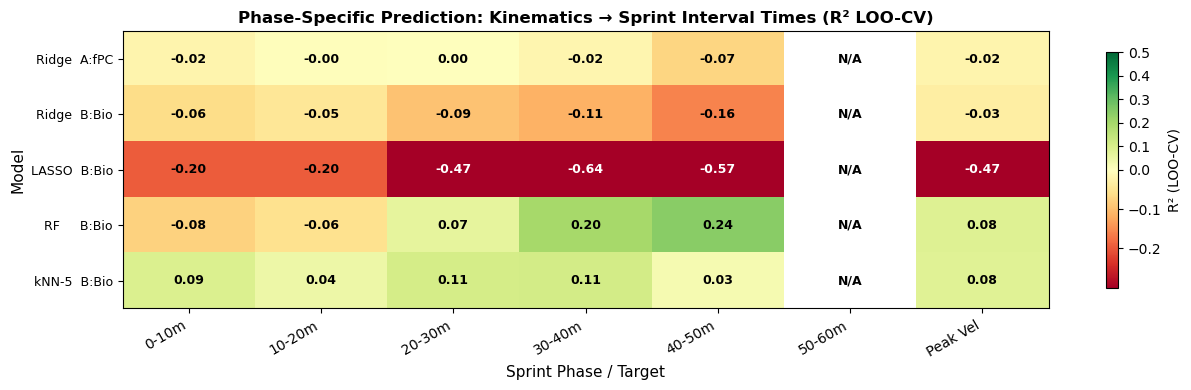

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures/phase_prediction_heatmap.png
              0-10m  10-20m  20-30m  30-40m  40-50m  50-60m  Peak Vel
Ridge  A:fPC -0.020  -0.004   0.000  -0.017  -0.072     NaN    -0.020
Ridge  B:Bio -0.061  -0.046  -0.094  -0.113  -0.159     NaN    -0.031
LASSO  B:Bio -0.195  -0.195  -0.475  -0.643  -0.571     NaN    -0.474
RF     B:Bio -0.077  -0.056   0.066   0.198   0.245     NaN     0.083
kNN-5  B:Bio  0.091   0.043   0.107   0.110   0.026     NaN     0.080


In [34]:
# ── Phase-Specific Prediction Heatmap ─────────────────────────────────────
# 5 model/feature combinations × 7 targets (6 intervals + peak_vel)
# Each cell = R² (LOO-CV).  "Warm" colour = better prediction.

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import matplotlib.colors as mcolors
import warnings

np.random.seed(RANDOM_SEED)

phase_model_defs = [
    ('Ridge  A:fPC', scores.copy(),
     Pipeline([('sc', StandardScaler()), ('m', RidgeCV(alphas=np.logspace(-3,3,30)))])),
    ('Ridge  B:Bio', X_B.copy(),
     Pipeline([('sc', StandardScaler()), ('m', RidgeCV(alphas=np.logspace(-3,3,30)))])),
    ('LASSO  B:Bio', X_B.copy(),
     Pipeline([('sc', StandardScaler()),
               ('m', LassoCV(alphas=np.logspace(-4,1,30), cv=5,
                             max_iter=5000, random_state=RANDOM_SEED))])),
    ('RF     B:Bio', X_B.copy(),
     Pipeline([('sc', StandardScaler()),
               ('m', RandomForestRegressor(n_estimators=300, max_depth=3,
                                           min_samples_leaf=3, random_state=RANDOM_SEED))])),
    ('kNN-5  B:Bio', X_B.copy(),
     Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=5))])),
]

all_targets   = INTERVAL_COLS + ['peak_vel']
target_labels = INTERVAL_LABELS + ['Peak Vel']
heatmap_vals  = np.full((len(phase_model_defs), len(all_targets)), np.nan)
hrow_names    = [d[0] for d in phase_model_defs]

st_aligned = split_times_df.set_index('participant_id').reindex(pid_order)

for ri, (mname, X_feat, pipe) in enumerate(phase_model_defs):
    for ci, icol in enumerate(all_targets):
        if icol == 'peak_vel':
            y_tgt, valid = y.copy(), np.ones(len(y), dtype=bool)
        else:
            y_tgt = st_aligned[icol].values.astype(float)
            valid = ~np.isnan(y_tgt)
        if valid.sum() < 10:
            continue
        Xv, yv = X_feat[valid], y_tgt[valid]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                yp = cross_val_predict(pipe, Xv, yv, cv=LeaveOneOut())
            heatmap_vals[ri, ci] = round(r2_score(yv, yp), 3)
        except Exception:
            pass
    print(f"  {mname}: done")

heatmap_df = pd.DataFrame(heatmap_vals, index=hrow_names, columns=target_labels)
heatmap_df.to_csv(DATA_DIR / 'phase_prediction_heatmap.csv')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
vmax_hm  = max(0.5, float(np.nanmax(heatmap_vals)))
norm_hm  = mcolors.TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=vmax_hm)
im       = ax.imshow(heatmap_vals, cmap='RdYlGn', norm=norm_hm, aspect='auto')
plt.colorbar(im, ax=ax, label='R\u00b2 (LOO-CV)', shrink=0.85)

ax.set_xticks(range(len(target_labels)))
ax.set_xticklabels(target_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(hrow_names)))
ax.set_yticklabels(hrow_names, fontsize=9)

for i in range(heatmap_vals.shape[0]):
    for j in range(heatmap_vals.shape[1]):
        v = heatmap_vals[i, j]
        txt = f'{v:.2f}' if not np.isnan(v) else 'N/A'
        col = 'white' if abs(v) > 0.28 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                fontweight='bold', color=col)

ax.set_title('Phase-Specific Prediction: Kinematics \u2192 Sprint Interval Times (R\u00b2 LOO-CV)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Sprint Phase / Target', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'phase_prediction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'phase_prediction_heatmap.png'}")
print(heatmap_df.to_string())


Best phase prediction: RF     B:Bio  ->  40-50m  (R²=0.245)


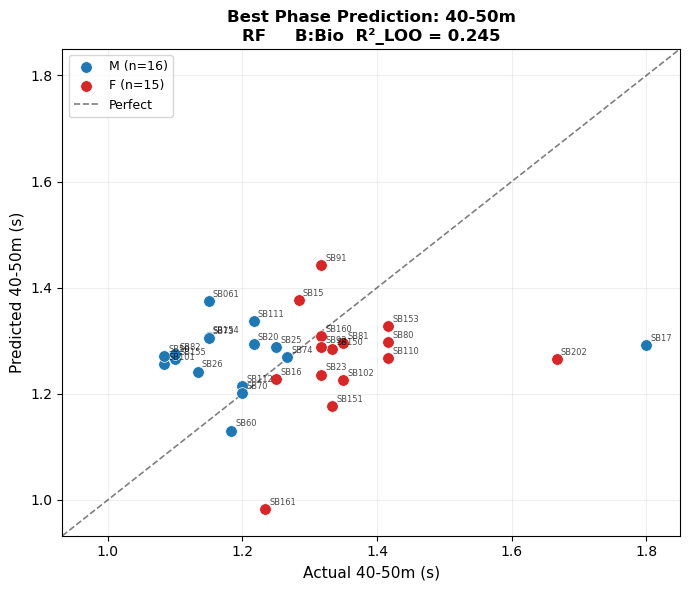

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures/best_interval_prediction.png


In [35]:
# ── Best-Interval Scatter Plot ────────────────────────────────────────────
# Identify the sprint interval with the highest LOO-CV R^2 and plot predicted vs actual.

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score

np.random.seed(RANDOM_SEED)

# Exclude 'Peak Vel' column when searching for best interval
hm_intervals = heatmap_df.drop(columns=['Peak Vel'], errors='ignore')
best_flat    = np.nanargmax(hm_intervals.values)
best_ri, best_ci = divmod(best_flat, hm_intervals.shape[1])
best_model_lbl   = hm_intervals.index[best_ri]
best_tgt_lbl     = hm_intervals.columns[best_ci]
best_r2          = float(hm_intervals.values[best_ri, best_ci])
best_icol        = INTERVAL_COLS[best_ci]   # column name in split_times_df

print(f"Best phase prediction: {best_model_lbl}  ->  {best_tgt_lbl}  (R\u00b2={best_r2:.3f})")

y_best  = st_aligned[best_icol].values.astype(float)
valid   = ~np.isnan(y_best)
Xv      = X_B[valid]
yv      = y_best[valid]
pids_v  = np.array(pid_order)[valid]
sex_v   = meta_df.set_index('participant_id').reindex(pids_v)['sex'].values

pipe_best = Pipeline([('sc', StandardScaler()), ('m', RidgeCV(alphas=np.logspace(-3,3,30)))])
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    yp_best = cross_val_predict(pipe_best, Xv, yv, cv=LeaveOneOut())

fig, ax = plt.subplots(figsize=(7, 6))
sex_cols = {'M': '#1f77b4', 'F': '#d62728', '?': '#888888'}
for sx in ['M', 'F', '?']:
    mask = sex_v == sx
    if mask.sum() == 0:
        continue
    ax.scatter(yv[mask], yp_best[mask], c=sex_cols[sx],
               label=f'{sx} (n={mask.sum()})', s=70, zorder=3,
               edgecolors='white', lw=0.5)

for act, pred, pid_ in zip(yv, yp_best, pids_v):
    ax.annotate(pid_, (act, pred), fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords='offset points')

lo = min(yv.min(), yp_best.min()) - 0.05
hi = max(yv.max(), yp_best.max()) + 0.05
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.5, label='Perfect')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel(f'Actual {best_tgt_lbl} (s)', fontsize=11)
ax.set_ylabel(f'Predicted {best_tgt_lbl} (s)', fontsize=11)
ax.set_title(f'Best Phase Prediction: {best_tgt_lbl}\n{best_model_lbl}  R\u00b2_LOO = {best_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'best_interval_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'best_interval_prediction.png'}")


Interval time means ± SD by sex:

  0-10m     M=2.005±0.067s  F=2.214±0.089s  p=0.000 ***
  10-20m    M=1.258±0.047s  F=1.433±0.067s  p=0.000 ***
  20-30m    M=1.181±0.054s  F=1.350±0.072s  p=0.000 ***
  30-40m    M=1.175±0.074s  F=1.347±0.086s  p=0.000 ***
  40-50m    M=1.205±0.163s  F=1.354±0.099s  p=0.000 ***


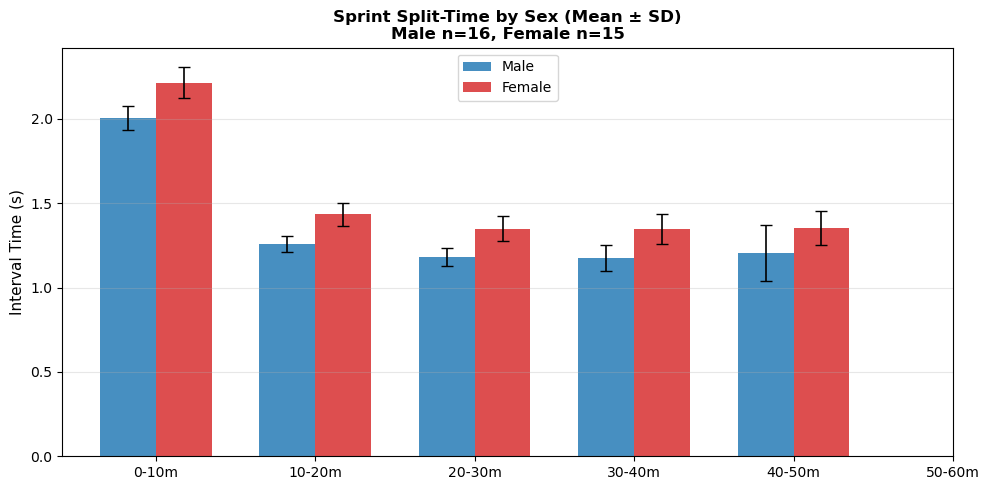

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures/split_times_by_sex.png


In [36]:
# ── Split-Time Summary by Sex ─────────────────────────────────────────────
from scipy.stats import mannwhitneyu

print("Interval time means \u00b1 SD by sex:\n")
for icol, lbl in zip(INTERVAL_COLS, INTERVAL_LABELS):
    mv = split_times_df.loc[split_times_df['sex'] == 'M', icol].dropna().values
    fv = split_times_df.loc[split_times_df['sex'] == 'F', icol].dropna().values
    if len(mv) < 3 or len(fv) < 3:
        continue
    stat, pval = mannwhitneyu(mv, fv, alternative='two-sided')
    sig = ('***' if pval < 0.001 else '**' if pval < 0.01 else
           '*' if pval < 0.05 else '')
    print(f"  {lbl:8s}  M={mv.mean():.3f}\u00b1{mv.std():.3f}s  "
          f"F={fv.mean():.3f}\u00b1{fv.std():.3f}s  p={pval:.3f} {sig}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(INTERVAL_COLS))
w  = 0.35
m_m = [split_times_df.loc[split_times_df['sex']=='M', c].mean() for c in INTERVAL_COLS]
f_m = [split_times_df.loc[split_times_df['sex']=='F', c].mean() for c in INTERVAL_COLS]
m_s = [split_times_df.loc[split_times_df['sex']=='M', c].std()  for c in INTERVAL_COLS]
f_s = [split_times_df.loc[split_times_df['sex']=='F', c].std()  for c in INTERVAL_COLS]

ax.bar(x - w/2, m_m, w, yerr=m_s, label='Male',   color='#1f77b4',
       alpha=0.82, capsize=4, error_kw={'elinewidth': 1.2})
ax.bar(x + w/2, f_m, w, yerr=f_s, label='Female', color='#d62728',
       alpha=0.82, capsize=4, error_kw={'elinewidth': 1.2})

ax.set_xticks(x); ax.set_xticklabels(INTERVAL_LABELS, fontsize=10)
ax.set_ylabel('Interval Time (s)', fontsize=11)
ax.set_title('Sprint Split-Time by Sex (Mean \u00b1 SD)\nMale n=16, Female n=15',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'split_times_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'split_times_by_sex.png'}")


---
# PART X — Acceleration Phase fPCA Pipeline

Top-speed fPCA analyses kinematics at peak velocity. Here we build a **parallel fPCA pipeline for
acceleration strides** (first 3–4 strides before 80% of peak velocity) and test whether:

1. Acceleration kinematics predict **0–10 m and 10–20 m split times** better than top-speed
   kinematics predict peak velocity (hypothesis: kinematics are most informative during acceleration).
2. SCR/MCR patterns reveal distinct kinematic signatures between phases.


In [37]:
# ── Acceleration Dataset Extraction ───────────────────────────────────────
# Re-reads each c3d file, applies identical preprocessing as Cell 10,
# then extracts first N_ACCEL_STRIDES complete strides from the acceleration phase
# (before 80% of peak velocity) and builds a (N, 19392) feature matrix.

import warnings as _warn

N_ACCEL_STRIDES = 4       # max strides from acceleration phase
ACCEL_THRESHOLD = 0.80    # fraction of peak vel defining end of acceleration

accel_results = []
accel_failed  = []

print(f"Building acceleration dataset  "
      f"(max {N_ACCEL_STRIDES} strides, threshold = {ACCEL_THRESHOLD*100:.0f}% peak vel)...")

for pid in tqdm(pid_order, desc='Accel strides'):
    try:
        if pid not in velocity_traces:
            raise ValueError("No velocity trace stored")

        vt          = velocity_traces[pid]
        vel_arr     = np.array(vt['velocity_ms'])
        peak_vel_p  = float(vt['peak_vel'])
        vel_80      = ACCEL_THRESHOLD * peak_vel_p

        above_80 = np.where(vel_arr >= vel_80)[0]
        if len(above_80) == 0:
            raise ValueError("Never reached 80% peak velocity")
        accel_end = int(above_80[0])
        if accel_end < 10:
            raise ValueError(f"Acceleration phase too short: {accel_end} frames")

        # Find trial info
        trial_row = [t for t in trials if t['participant_id'] == pid]
        if not trial_row:
            raise ValueError("Trial not in trials list")
        filepath = trial_row[0]['filepath']
        ftype    = trial_row[0]['filetype']

        if ftype not in ('.c3d', 'c3d'):
            raise ValueError("Acceleration pipeline requires c3d data")

        # ── Load + preprocess (identical to Cell 10) ───────────────────
        with _warn.catch_warnings():
            _warn.simplefilter('ignore')
            mk_data, meta_ld = load_marker_data(filepath, ftype)

        raw_64_a = meta_ld.get('raw_markers_64', None)
        if raw_64_a is None:
            raise ValueError("No raw_markers_64 in c3d metadata")

        # PCA alignment
        mk_data, pca_obj_a, _ = perform_pca_alignment(mk_data)
        nf   = raw_64_a.shape[0]
        flat = raw_64_a.reshape(nf * N_MARKERS_C3D, 3)
        raw_64_a = ((flat - pca_obj_a.mean_) @ pca_obj_a.components_.T
                    ).reshape(nf, N_MARKERS_C3D, 3)

        # Sprint start
        start_a  = detect_sprint_start(mk_data, SAMPLING_RATE)
        mk_data  = mk_data[start_a:]
        raw_64_a = raw_64_a[start_a:]

        # Shift origin
        mk_data = shift_origin(mk_data)
        _r_ap   = raw_64_a[0, MK_R_HEEL, 0]
        _l_ap   = raw_64_a[0, MK_L_HEEL, 0]
        _orig   = raw_64_a[0, MK_R_HEEL if _r_ap <= _l_ap else MK_L_HEEL, :].copy()
        raw_64_a = raw_64_a - _orig[np.newaxis, np.newaxis, :]

        # Trim to 60 m
        mk_data  = trim_to_60m(mk_data)
        raw_64_a = raw_64_a[:mk_data.shape[0]]

        # Clip accel_end to actual frame count
        accel_end = min(accel_end, mk_data.shape[0] - 1)

        # ── Detect contacts and extract acceleration strides ────────────
        r_contacts, _, _ = detect_all_contacts_bilateral(mk_data)
        r_contacts = np.array([f for f in r_contacts if 5 < f < accel_end])

        if len(r_contacts) < 2:
            raise ValueError(
                f"Only {len(r_contacts)} R contacts before accel end frame {accel_end}")

        accel_stride_vecs = []
        for si in range(min(N_ACCEL_STRIDES, len(r_contacts) - 1)):
            cs, ce = int(r_contacts[si]), int(r_contacts[si + 1])
            if ce - cs < 5:
                continue
            tn  = time_normalize_stride(raw_64_a[cs:ce+1], TN_POINTS)  # (101, 64, 3)
            t12 = tn[:, MK_T12, :]                                       # (101, 3)
            accel_stride_vecs.append(tn - t12[:, np.newaxis, :])

        if len(accel_stride_vecs) == 0:
            raise ValueError("No valid acceleration strides extracted")

        mean_accel_64 = np.mean(np.stack(accel_stride_vecs), axis=0)   # (101, 64, 3)
        vector_a, _   = create_stride_vector_64(mean_accel_64)

        accel_results.append({
            'participant_id': pid,
            'vector': vector_a,
            'n_strides': len(accel_stride_vecs),
            'accel_end_frame': accel_end,
        })

    except Exception as exc:
        accel_failed.append((pid, str(exc)))

print(f"\nAcceleration dataset: {len(accel_results)} / {len(pid_order)} participants")
if accel_failed:
    print(f"Failed ({len(accel_failed)}):")
    for p, e in accel_failed:
        print(f"  {p}: {e}")

# ── Build aligned matrix ────────────────────────────────────────────────
accel_pids    = [r['participant_id'] for r in accel_results]
accel_dataset = np.stack([r['vector'] for r in accel_results])   # (N_ok, 19392)

# Reorder to match meta_df order (drop missing)
accel_meta   = meta_df[meta_df['participant_id'].isin(accel_pids)].copy().reset_index(drop=True)
pid_to_i     = {p: i for i, p in enumerate(accel_pids)}
reorder      = [pid_to_i[p] for p in accel_meta['participant_id']]
accel_dataset = accel_dataset[reorder]

np.save(DATA_DIR / 'accel_participant_vectors.npy', accel_dataset)
print(f"Saved: {DATA_DIR / 'accel_participant_vectors.npy'}")
print(f"Aligned shape: {accel_dataset.shape}")
print(f"Strides used per participant: "
      f"{[r['n_strides'] for r in accel_results if r['participant_id'] in accel_meta['participant_id'].tolist()]}")


Building acceleration dataset  (max 4 strides, threshold = 80% peak vel)...


Accel strides:   0%|          | 0/31 [00:00<?, ?it/s]


Acceleration dataset: 20 / 31 participants
Failed (11):
  SB102: Only 1 R contacts before accel end frame 95
  SB110: Only 1 R contacts before accel end frame 85
  SB111: Only 1 R contacts before accel end frame 116
  SB16: Only 1 R contacts before accel end frame 104
  SB161: Only 1 R contacts before accel end frame 129
  SB17: Only 1 R contacts before accel end frame 84
  SB70: Only 1 R contacts before accel end frame 87
  SB73: Only 1 R contacts before accel end frame 84
  SB74: Only 1 R contacts before accel end frame 85
  SB80: Only 1 R contacts before accel end frame 104
  SB82: Only 1 R contacts before accel end frame 120
Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/data/accel_participant_vectors.npy
Aligned shape: (20, 19392)
Strides used per participant: [1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1]


Acceleration fPCA: 19 components
  Cumulative variance: 100.0%
  Top-5 PCs: [44.5 19.2 10.8  7.6  5.7]


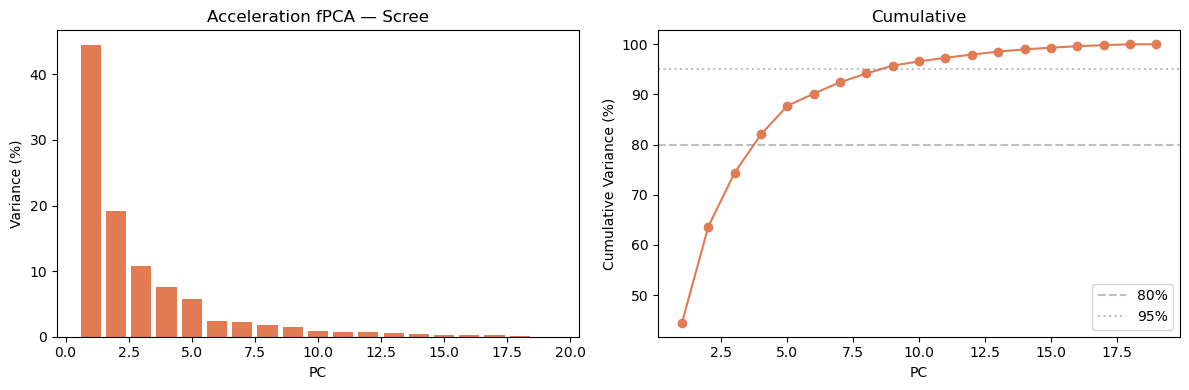

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures/scree_accel.png

Acceleration stepwise regression:
  0-10m: PCs=[7, 14, 6, 11, 4, 12]  R²_train=0.855  R²_LOO=0.657
  10-20m: PCs=[7, 14, 11, 6, 8, 12]  R²_train=0.855  R²_LOO=0.653

ACCEL_RETAINED_PCS (top by variance): [1, 2, 3, 4, 5]


In [38]:
# ── Acceleration fPCA + Stepwise Regression ───────────────────────────────
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score
import statsmodels.api as sm
import warnings

np.random.seed(RANDOM_SEED)

# PCA
N_COMP_ACCEL = min(30, accel_dataset.shape[0] - 1)
accel_mu     = accel_dataset.mean(axis=0)
X_accel_c    = accel_dataset - accel_mu
accel_fpca   = PCA(n_components=N_COMP_ACCEL, random_state=RANDOM_SEED)
accel_scores = accel_fpca.fit_transform(X_accel_c)

print(f"Acceleration fPCA: {N_COMP_ACCEL} components")
print(f"  Cumulative variance: {accel_fpca.explained_variance_ratio_.cumsum()[-1]*100:.1f}%")
print(f"  Top-5 PCs: {(accel_fpca.explained_variance_ratio_[:5]*100).round(1)}")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, N_COMP_ACCEL+1), accel_fpca.explained_variance_ratio_*100, color='#e07b54')
axes[0].set(xlabel='PC', ylabel='Variance (%)', title='Acceleration fPCA — Scree')
axes[1].plot(range(1, N_COMP_ACCEL+1), accel_fpca.explained_variance_ratio_.cumsum()*100,
             'o-', color='#e07b54')
for thr, ls in [(80,'--'),(95,':')]:
    axes[1].axhline(thr, ls=ls, color='gray', alpha=0.5, label=f'{thr}%')
axes[1].set(xlabel='PC', ylabel='Cumulative Variance (%)', title='Cumulative')
axes[1].legend()
plt.tight_layout()
fig.savefig(FIG_DIR / 'scree_accel.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'scree_accel.png'}")

# ── Forward-backward stepwise regression ───────────────────────────────────
accel_split = split_times_df.set_index('participant_id').reindex(accel_meta['participant_id'])

def run_stepwise(X_sc, y_sc, max_pcs=6, p_enter=0.10, p_exit=0.10):
    selected = []
    for _ in range(max_pcs):
        best_p, best_pc = 1.0, None
        for pc in range(X_sc.shape[1]):
            if pc in selected:
                continue
            res = sm.OLS(y_sc, sm.add_constant(X_sc[:, selected+[pc]])).fit()
            if res.pvalues[-1] < best_p:
                best_p, best_pc = res.pvalues[-1], pc
        if best_p < p_enter:
            selected.append(best_pc)
        else:
            break
        changed = True
        while changed:
            changed = False
            if len(selected) > 1:
                res = sm.OLS(y_sc, sm.add_constant(X_sc[:, selected])).fit()
                worst_p = res.pvalues[1:].max()
                if worst_p > p_exit:
                    selected.pop(int(np.argmax(res.pvalues[1:])))
                    changed = True
    if not selected:
        return [], np.nan, np.nan
    Xs = X_sc[:, selected]
    lr = LinearRegression().fit(Xs, y_sc)
    r2_tr = r2_score(y_sc, lr.predict(Xs))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        yp = cross_val_predict(lr, Xs, y_sc, cv=LeaveOneOut())
    r2_lo = r2_score(y_sc, yp)
    return selected, round(r2_tr,3), round(r2_lo,3)

print("\nAcceleration stepwise regression:")
for icol, lbl in zip(INTERVAL_COLS[:2], INTERVAL_LABELS[:2]):
    y_a   = accel_split[icol].values.astype(float)
    valid = ~np.isnan(y_a)
    if valid.sum() < 8:
        print(f"  {lbl}: too few valid ({valid.sum()}), skipping"); continue
    sel, r2tr, r2lo = run_stepwise(accel_scores[valid], y_a[valid])
    pcs = [p+1 for p in sel]
    print(f"  {lbl}: PCs={pcs}  R\u00b2_train={r2tr}  R\u00b2_LOO={r2lo}")

# Retained PCs for SCR/MCR (top by variance)
ACCEL_RETAINED_PCS = list(range(min(5, N_COMP_ACCEL)))
print(f"\nACCEL_RETAINED_PCS (top by variance): {[p+1 for p in ACCEL_RETAINED_PCS]}")


In [39]:
# ── Acceleration Model Comparison (LOO-CV) ────────────────────────────────
# 6 models × {0-10m, 10-20m} targets × {accel fPC, Bio} feature sets
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings

np.random.seed(RANDOM_SEED)

# Bio features aligned to acceleration participants
bio_accel  = bio_full.set_index('participant_id').reindex(accel_meta['participant_id'])
X_Aaccel   = accel_scores.copy()
X_Baccel   = np.nan_to_num(bio_accel[bio_numeric_cols].values.astype(float))

accel_model_defs = [
    ('Ridge',   Pipeline([('sc', StandardScaler()), ('m', RidgeCV(alphas=np.logspace(-3,3,30)))])),
    ('LASSO',   Pipeline([('sc', StandardScaler()),
                          ('m', LassoCV(alphas=np.logspace(-4,1,30), cv=5,
                                        max_iter=5000, random_state=RANDOM_SEED))])),
    ('RF',      Pipeline([('sc', StandardScaler()),
                          ('m', RandomForestRegressor(n_estimators=300, max_depth=3,
                                                       min_samples_leaf=3,
                                                       random_state=RANDOM_SEED))])),
    ('kNN-5',   Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=5))])),
    ('SVR-RBF', Pipeline([('sc', StandardScaler()), ('m', SVR(kernel='rbf', C=1, gamma='scale'))])),
    ('XGBoost', Pipeline([('sc', StandardScaler()),
                          ('m', xgb.XGBRegressor(n_estimators=100, max_depth=2,
                                                  learning_rate=0.1, reg_alpha=0.5,
                                                  random_state=RANDOM_SEED, verbosity=0))])),
]

accel_model_results = []

def eval_accel_model(name, pipe, X, y_tgt, fl, tgt_lbl):
    valid = ~np.isnan(y_tgt)
    if valid.sum() < 8:
        return None
    Xv, yv = X[valid], y_tgt[valid]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        yp = cross_val_predict(pipe, Xv, yv, cv=LeaveOneOut())
        pipe.fit(Xv, yv)
    return {
        'Target':   tgt_lbl,
        'Model':    name,
        'Features': fl,
        'R2_LOO':   round(r2_score(yv, yp), 4),
        'RMSE':     round(float(np.sqrt(mean_squared_error(yv, yp))), 4),
        'MAE':      round(float(mean_absolute_error(yv, yp)), 4),
        'R2_train': round(float(r2_score(yv, pipe.predict(Xv))), 4),
    }

for icol, lbl in zip(INTERVAL_COLS[:2], INTERVAL_LABELS[:2]):
    y_tgt = accel_split[icol].values.astype(float)
    print(f"\n--- Target: {lbl} ---")
    for mname, pipe in accel_model_defs:
        for Xd, fl in [(X_Aaccel, 'A: accel fPC'), (X_Baccel, 'B: Bio')]:
            res = eval_accel_model(mname, pipe, Xd, y_tgt, fl, lbl)
            if res:
                accel_model_results.append(res)
                print(f"  {mname:9s} [{fl}]: R\u00b2_LOO={res['R2_LOO']:.3f}  R\u00b2_train={res['R2_train']:.3f}")

accel_model_df = pd.DataFrame(accel_model_results)
accel_model_df.to_csv(DATA_DIR / 'accel_model_comparison.csv', index=False)
print(f"\nSaved: {DATA_DIR / 'accel_model_comparison.csv'}")
print("\nTop acceleration models:")
print(accel_model_df.sort_values('R2_LOO', ascending=False).head(8)[
    ['Target','Model','Features','R2_LOO','RMSE','R2_train']].to_string(index=False))



--- Target: 0-10m ---
  Ridge     [A: accel fPC]: R²_LOO=-0.076  R²_train=0.999
  Ridge     [B: Bio]: R²_LOO=-0.150  R²_train=0.413


  LASSO     [A: accel fPC]: R²_LOO=-0.257  R²_train=0.639


  LASSO     [B: Bio]: R²_LOO=-0.499  R²_train=0.000


  RF        [A: accel fPC]: R²_LOO=-0.212  R²_train=0.650


  RF        [B: Bio]: R²_LOO=-0.126  R²_train=0.647
  kNN-5     [A: accel fPC]: R²_LOO=-0.260  R²_train=0.187
  kNN-5     [B: Bio]: R²_LOO=0.029  R²_train=0.424
  SVR-RBF   [A: accel fPC]: R²_LOO=-0.087  R²_train=0.602
  SVR-RBF   [B: Bio]: R²_LOO=-0.021  R²_train=0.663


...

  LASSO     [B: Bio]: R²_LOO=-0.172  R²_train=0.429


  RF        [A: accel fPC]: R²_LOO=-0.137  R²_train=0.684


  RF        [B: Bio]: R²_LOO=-0.079  R²_train=0.654
  kNN-5     [A: accel fPC]: R²_LOO=-0.290  R²_train=0.251
  kNN-5     [B: Bio]: R²_LOO=0.062  R²_train=0.417
  SVR-RBF   [A: accel fPC]: R²_LOO=-0.098  R²_train=0.484
  SVR-RBF   [B: Bio]: R²_LOO=-0.034  R²_train=0.573


  XGBoost   [A: accel fPC]: R²_LOO=-0.226  R²_train=0.296


  XGBoost   [B: Bio]: R²_LOO=-0.216  R²_train=0.272

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/data/accel_model_comparison.csv

Top acceleration models:
Target   Model     Features  R2_LOO   RMSE  R2_train
10-20m   kNN-5       B: Bio  0.0621 0.1080    0.4173
10-20m   LASSO A: accel fPC  0.0404 0.1093    0.3043
 0-10m   kNN-5       B: Bio  0.0288 0.1347    0.4244
 0-10m SVR-RBF       B: Bio -0.0213 0.1381    0.6629
10-20m SVR-RBF       B: Bio -0.0335 0.1134    0.5732
 0-10m   Ridge A: accel fPC -0.0760 0.1418    0.9988
10-20m      RF       B: Bio -0.0794 0.1159    0.6538
10-20m   Ridge A: accel fPC -0.0814 0.1160    0.9994


Cross-Phase R² Comparison:
       Phase        Target               Best Model  R2_LOO   RMSE
   Top Speed Peak Velocity Stepwise OLS [A (6 PCs)]  0.2348 0.6162
Acceleration         0-10m           kNN-5 [B: Bio]  0.0288 0.1347
Acceleration        10-20m           kNN-5 [B: Bio]  0.0621 0.1080
Max Velocity        20-30m             kNN-5  B:Bio  0.1070    NaN
Max Velocity        30-40m             RF     B:Bio  0.1980    NaN
Max Velocity        40-50m             RF     B:Bio  0.2450    NaN


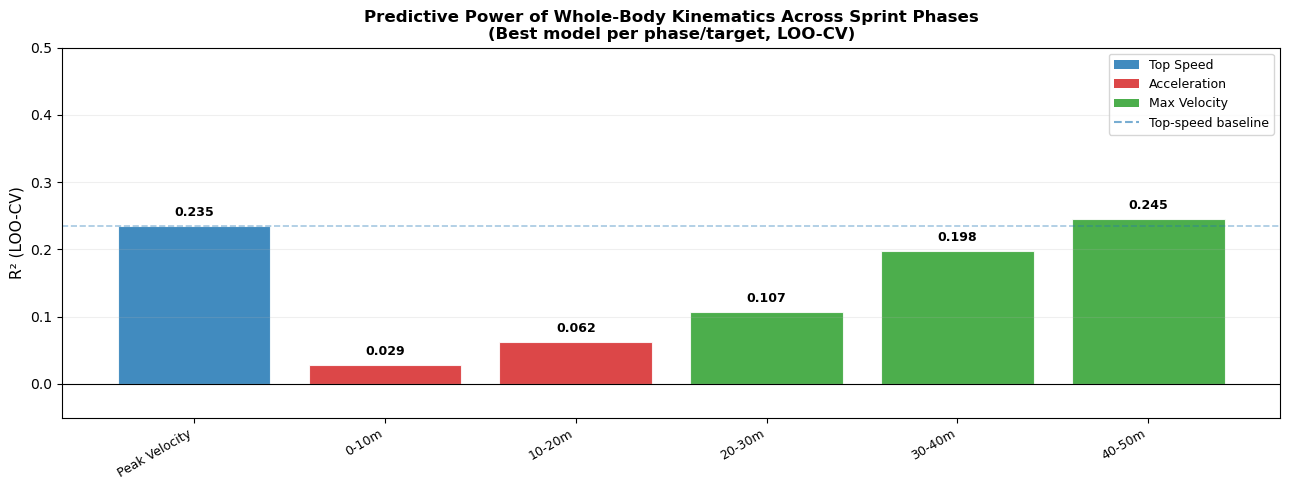

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures/cross_phase_r2_comparison.png


In [40]:
# ── Cross-Phase Comparison: Top Speed vs Acceleration ─────────────────────
# Summary table and bar chart comparing R^2_LOO across all sprint phases.

from matplotlib.patches import Patch

best_ts = results_df.iloc[0]   # already sorted by R2_LOO (top-speed, from Cell 42)

cross_rows = [{
    'Phase':      'Top Speed',
    'Target':     'Peak Velocity',
    'Best Model': f"{best_ts['Model']} [{best_ts['Features']}]",
    'R2_LOO':     float(best_ts['R2_LOO']),
    'RMSE':       float(best_ts['RMSE']),
}]

for icol, lbl in zip(INTERVAL_COLS[:2], INTERVAL_LABELS[:2]):
    sub = accel_model_df[accel_model_df['Target'] == lbl].sort_values('R2_LOO', ascending=False)
    if len(sub) == 0:
        continue
    b = sub.iloc[0]
    cross_rows.append({
        'Phase':      'Acceleration',
        'Target':     lbl,
        'Best Model': f"{b['Model']} [{b['Features']}]",
        'R2_LOO':     float(b['R2_LOO']),
        'RMSE':       float(b['RMSE']),
    })

# Add mid-race intervals from heatmap
for icol, lbl, col in zip(INTERVAL_COLS[2:5], INTERVAL_LABELS[2:5],
                           list(heatmap_df.columns)[2:5]):
    best_r2  = float(heatmap_df[col].max())
    best_mdl = str(heatmap_df[col].idxmax())
    cross_rows.append({
        'Phase':      'Max Velocity',
        'Target':     lbl,
        'Best Model': best_mdl,
        'R2_LOO':     best_r2,
        'RMSE':       np.nan,
    })

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv(DATA_DIR / 'cross_phase_comparison.csv', index=False)
print("Cross-Phase R\u00b2 Comparison:")
print(cross_df[['Phase','Target','Best Model','R2_LOO','RMSE']].to_string(index=False))

# ── Bar chart (KEY FIGURE) ─────────────────────────────────────────────────
phase_pal = {'Top Speed': '#1f77b4', 'Acceleration': '#d62728', 'Max Velocity': '#2ca02c'}
fig, ax   = plt.subplots(figsize=(13, 5))

seen_phases = set()
for i, row in cross_df.iterrows():
    col   = phase_pal.get(row['Phase'], '#888')
    label = row['Phase'] if row['Phase'] not in seen_phases else None
    seen_phases.add(row['Phase'])
    ax.bar(i, max(float(row['R2_LOO']), 0), color=col, alpha=0.85,
           edgecolor='white', lw=0.8, label=label)
    ax.text(i, max(float(row['R2_LOO']), 0) + 0.01, f"{float(row['R2_LOO']):.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(cross_df)))
ax.set_xticklabels([r['Target'] for _, r in cross_df.iterrows()],
                   rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(float(best_ts['R2_LOO']), ls='--', color='#1f77b4', alpha=0.4, lw=1.2,
           label=f"Top-speed baseline (R\u00b2={float(best_ts['R2_LOO']):.3f})")
ax.set_ylabel('R\u00b2 (LOO-CV)', fontsize=11)
ax.set_title('Predictive Power of Whole-Body Kinematics Across Sprint Phases\n'
             '(Best model per phase/target, LOO-CV)',
             fontsize=12, fontweight='bold')
ymax = max(float(cross_df['R2_LOO'].max()) + 0.18, 0.5)
ax.set_ylim(-0.05, ymax)

legend_els = [Patch(facecolor=v, label=k, alpha=0.85) for k, v in phase_pal.items()]
legend_els.append(plt.Line2D([0],[0], ls='--', color='#1f77b4', alpha=0.6,
                              label=f"Top-speed baseline"))
ax.legend(handles=legend_els, fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'cross_phase_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'cross_phase_r2_comparison.png'}")


---
# PART XI — Sex-Based Biomechanical Differences

With **16 male** and **15 female** participants, we test whether sprint kinematics and biomechanics
differ significantly between sexes using non-parametric Mann-Whitney U tests (appropriate for n=31).


In [41]:
# ── Sex-Based Statistical Tests (Mann-Whitney U) ──────────────────────────
from scipy.stats import mannwhitneyu

males   = bio_full[bio_full['sex'] == 'M']
females = bio_full[bio_full['sex'] == 'F']
print(f"Males: n={len(males)}   Females: n={len(females)}\n")

sex_records = []
for col in bio_numeric_cols:
    mv = males[col].dropna().values
    fv = females[col].dropna().values
    if len(mv) < 3 or len(fv) < 3:
        continue
    stat, pval = mannwhitneyu(mv, fv, alternative='two-sided')
    # Rank-biserial correlation (effect size)
    rbc = 1.0 - (2.0 * stat) / (len(mv) * len(fv))
    sex_records.append({
        'metric':          col,
        'mean_M':          round(float(mv.mean()), 4),
        'std_M':           round(float(mv.std()),  4),
        'mean_F':          round(float(fv.mean()), 4),
        'std_F':           round(float(fv.std()),  4),
        'U_stat':          round(float(stat), 1),
        'p_value':         round(float(pval), 4),
        'effect_size_rbc': round(float(rbc),  3),
        'significant':     bool(pval < 0.05),
    })

sex_diff_df = pd.DataFrame(sex_records).sort_values('p_value').reset_index(drop=True)
sex_diff_df.to_csv(DATA_DIR / 'sex_differences.csv', index=False)

print("Sex differences (sorted by p-value):")
print(sex_diff_df[['metric','mean_M','mean_F','p_value',
                   'effect_size_rbc','significant']].to_string(index=False))
n_sig = sex_diff_df['significant'].sum()
print(f"\n{n_sig}/{len(sex_diff_df)} metrics significantly different (p<0.05)")
print(f"Saved: {DATA_DIR / 'sex_differences.csv'}")


Males: n=16   Females: n=15

Sex differences (sorted by p-value):
                          metric  mean_M  mean_F  p_value  effect_size_rbc  significant
                   stride1_gct_s  0.0437  0.0789   0.0649            0.379        False
               vertical_rfd_norm  2.5817  2.1092   0.0721           -0.383        False
avg_vert_oscillation_top_speed_m  0.0825  0.0556   0.0769           -0.375        False
            strides_to_top_speed  5.9375  7.2000   0.0996            0.346        False
        stride_freq_top_speed_hz  5.2125  3.5547   0.1209           -0.329        False
       accel_distance_to_95pct_m 20.2313 20.6687   0.1383           -0.317        False
              steps_to_top_speed 11.7500 14.5333   0.1751            0.287        False
                    leg_length_m  0.7921  0.7444   0.1920           -0.279        False
                   stride2_gct_s  0.0177  0.0344   0.2662            0.208        False
   avg_stride_length_top_speed_m  0.5452  1.3235   0.2

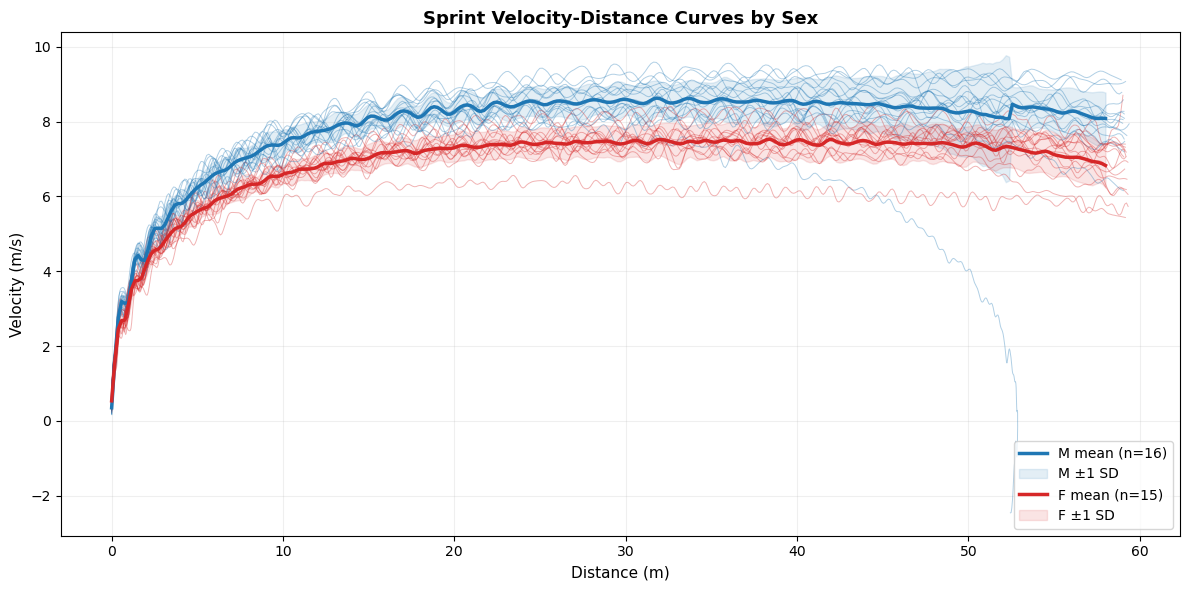

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures/velocity_curves_by_sex.png


In [42]:
# ── Velocity-Distance Curves by Sex ───────────────────────────────────────
from scipy.signal import savgol_filter as _sg

sex_lkp   = meta_df.set_index('participant_id')['sex'].to_dict()
SEX_COLS  = {'M': '#1f77b4', 'F': '#d62728'}

fig, ax = plt.subplots(figsize=(12, 6))
male_curves, female_curves = [], []

for pid, vt in velocity_traces.items():
    vel  = _sg(np.array(vt['velocity_ms']), window_length=9, polyorder=3)
    dist = np.array(vt['distance_m']); dist = dist - dist[0]
    sx   = sex_lkp.get(pid, '?')
    col  = SEX_COLS.get(sx, '#888')
    ax.plot(dist, vel, color=col, lw=0.7, alpha=0.35)
    if sx == 'M': male_curves.append((dist, vel))
    elif sx == 'F': female_curves.append((dist, vel))

# Mean + 1SD band per sex (interpolated to common distance grid)
d_grid = np.linspace(0, 58, 300)
for curves, sx, lw in [(male_curves,'M',2.5), (female_curves,'F',2.5)]:
    interps = [np.interp(d_grid, d, v, left=np.nan, right=np.nan)
               for d, v in curves if len(d) > 10]
    arr    = np.array(interps)
    mean_v = np.nanmean(arr, axis=0)
    sd_v   = np.nanstd(arr,  axis=0)
    ax.plot(d_grid, mean_v, color=SEX_COLS[sx], lw=lw,
            label=f'{sx} mean (n={len(curves)})', zorder=5)
    ax.fill_between(d_grid, mean_v - sd_v, mean_v + sd_v,
                    color=SEX_COLS[sx], alpha=0.12, label=f'{sx} \u00b11 SD')

ax.set_xlabel('Distance (m)', fontsize=11)
ax.set_ylabel('Velocity (m/s)', fontsize=11)
ax.set_title('Sprint Velocity-Distance Curves by Sex', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'velocity_curves_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'velocity_curves_by_sex.png'}")


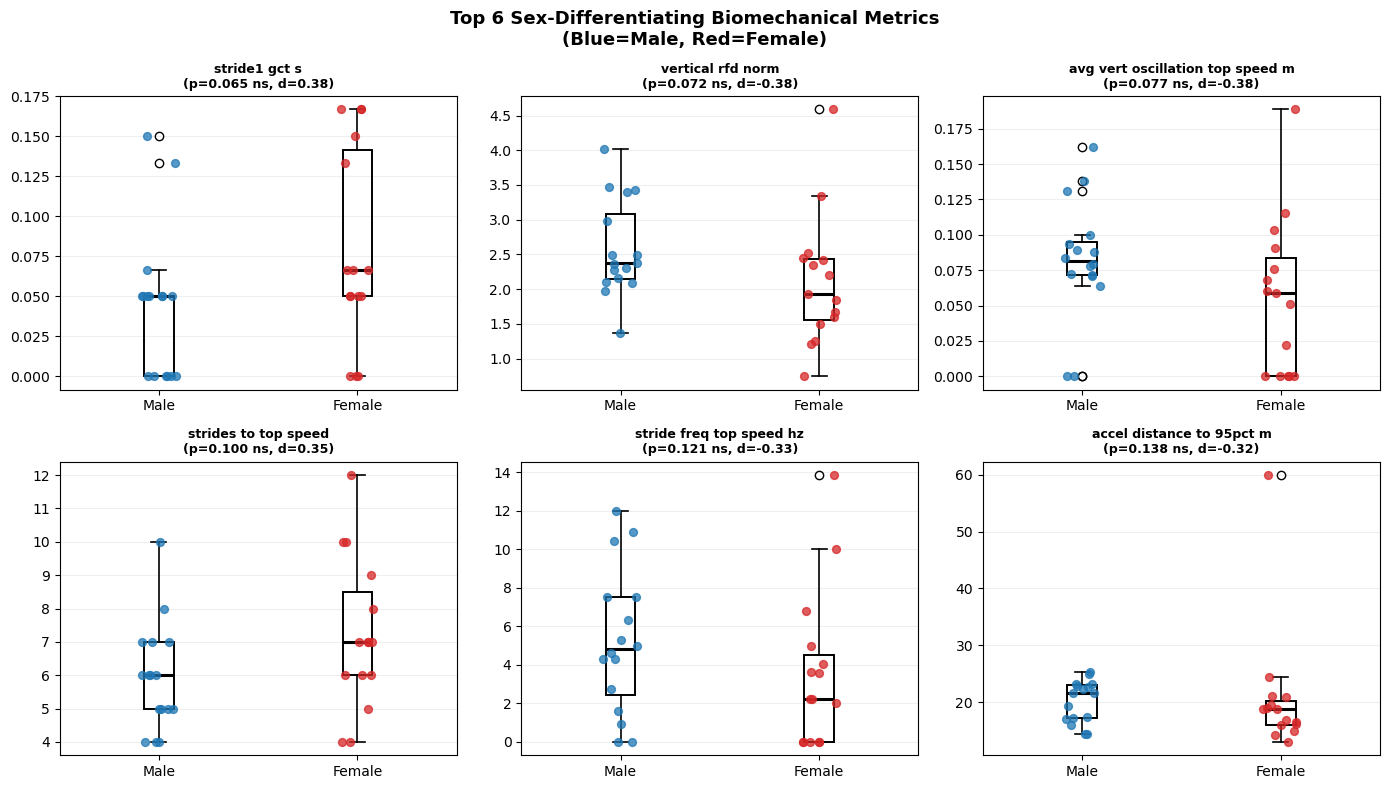

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures/sex_boxplots.png


In [43]:
# ── Sex-Stratified Box Plots (Top Differentiating Metrics) ────────────────
top6 = sex_diff_df.head(6)['metric'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

np.random.seed(RANDOM_SEED)
for i, metric in enumerate(top6):
    ax  = axes[i]
    mv  = bio_full.loc[bio_full['sex']=='M', metric].dropna().values
    fv  = bio_full.loc[bio_full['sex']=='F', metric].dropna().values
    bp  = ax.boxplot([mv, fv], labels=['Male','Female'], patch_artist=True,
                     boxprops=dict(facecolor='none', linewidth=1.4),
                     medianprops=dict(color='black', lw=2.2),
                     whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
    # Jittered scatter overlay
    ax.scatter(1 + np.random.uniform(-0.09,0.09,len(mv)),
               mv, color='#1f77b4', alpha=0.75, s=32, zorder=3)
    ax.scatter(2 + np.random.uniform(-0.09,0.09,len(fv)),
               fv, color='#d62728', alpha=0.75, s=32, zorder=3)
    row  = sex_diff_df[sex_diff_df['metric'] == metric].iloc[0]
    pval = row['p_value']; rbc = row['effect_size_rbc']
    sig  = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'ns'))
    ax.set_title(f"{metric.replace('_',' ')}\n(p={pval:.3f} {sig}, d={rbc:.2f})",
                 fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)

for j in range(len(top6), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 6 Sex-Differentiating Biomechanical Metrics\n(Blue=Male, Red=Female)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'sex_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'sex_boxplots.png'}")


In [44]:
# ── Sex as Binary Covariate in Prediction ─────────────────────────────────
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score
import warnings

np.random.seed(RANDOM_SEED)

sex_binary    = (meta_df['sex'] == 'M').astype(float).values   # M=1, F=0
X_B_with_sex  = np.column_stack([X_B, sex_binary])

print("Effect of sex covariate on R\u00b2_LOO (bio features):\n")
print(f"{'Model':<18} {'Without Sex':>13} {'With Sex':>11} {'Delta':>9}")
print("-" * 55)

sex_models = [
    ('Ridge',   Pipeline([('sc', StandardScaler()),
                          ('m', RidgeCV(alphas=np.logspace(-3,3,30)))])),
    ('RF',      Pipeline([('sc', StandardScaler()),
                          ('m', RandomForestRegressor(n_estimators=300, max_depth=3,
                                                       min_samples_leaf=3,
                                                       random_state=RANDOM_SEED))])),
    ('kNN-5',   Pipeline([('sc', StandardScaler()),
                          ('m', KNeighborsRegressor(n_neighbors=5))])),
]

loo_sx = LeaveOneOut()
for mname, pipe in sex_models:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        yp_no  = cross_val_predict(pipe, X_B,          y, cv=loo_sx)
        yp_sex = cross_val_predict(pipe, X_B_with_sex, y, cv=loo_sx)
    r2_no  = r2_score(y, yp_no)
    r2_sex = r2_score(y, yp_sex)
    delta  = r2_sex - r2_no
    sign   = '+' if delta >= 0 else ''
    print(f"  {mname:<16} {r2_no:>13.4f} {r2_sex:>11.4f} {sign}{delta:>8.4f}")


Effect of sex covariate on R²_LOO (bio features):

Model                Without Sex    With Sex     Delta
-------------------------------------------------------
  Ridge                  -0.0308      0.5415 +  0.5723


  RF                      0.0832      0.6463 +  0.5631
  kNN-5                   0.0800      0.2396 +  0.1596


---
# PART XII — Acceleration Phase SCR/MCR

Single- and Multi-Component Reconstructions of the **acceleration stride** (first 3–4 strides before
80% peak velocity). Compare with top-speed SCR/MCR to identify kinematic signatures of each phase.

Skeletons: **Red = 5th %ile (slow)** | **Green = 50th %ile (median)** | **Blue = 95th %ile (fast)**
Spacing: 800 mm between gait events.


In [45]:
# ── Acceleration SCR (Single-Component Reconstruction) ───────────────────
# 3-plane × n_events grid.  Overlaid 5th / 50th / 95th percentile skeletons.
COLOR_50_ACCEL = '#2ca02c'   # green for acceleration median

if len(accel_results) < 5:
    print("Insufficient acceleration data for SCR (n<5). Skipping.")
else:
    ev_names_a  = list(stride_events.keys())
    ev_frames_a = [stride_events[n] for n in ev_names_a]
    n_events_a  = len(ev_names_a)
    planes_a    = ['sagittal', 'frontal', 'transverse']
    plane_yl_a  = ['Vert (mm)', 'Vert (mm)', 'ML (mm)']

    for pc_idx in ACCEL_RETAINED_PCS[:3]:
        pc_lbl  = f'PC{pc_idx+1}'
        var_pct = accel_fpca.explained_variance_ratio_[pc_idx] * 100

        fr05 = vector_to_frames(reconstruct_percentile(accel_mu, accel_fpca,
                                accel_scores, pc_idx,  5)) * SCALE_MM
        fr50 = vector_to_frames(reconstruct_percentile(accel_mu, accel_fpca,
                                accel_scores, pc_idx, 50)) * SCALE_MM
        fr95 = vector_to_frames(reconstruct_percentile(accel_mu, accel_fpca,
                                accel_scores, pc_idx, 95)) * SCALE_MM

        fig, axes = plt.subplots(len(planes_a), n_events_a,
                                  figsize=(3.5 * n_events_a, 5.5 * len(planes_a)),
                                  constrained_layout=True)
        for row, (plane, ylabel) in enumerate(zip(planes_a, plane_yl_a)):
            for col, (ev_name, ef) in enumerate(zip(ev_names_a, ev_frames_a)):
                ax = axes[row, col]
                l05 = '5th %ile (slow)'    if col == 0 else None
                l50 = '50th %ile (median)' if col == 0 else None
                l95 = '95th %ile (fast)'   if col == 0 else None
                draw_skeleton_projection(ax, fr05[ef], plane=plane,
                    color=COLOR_SLOW,     alpha=0.65, lw=1.8, label=l05)
                draw_skeleton_projection(ax, fr50[ef], plane=plane,
                    color=COLOR_50_ACCEL, alpha=0.50, lw=1.4, label=l50)
                draw_skeleton_projection(ax, fr95[ef], plane=plane,
                    color=COLOR_FAST,     alpha=0.65, lw=1.8, label=l95)
                ax.set_aspect('equal'); ax.grid(alpha=0.15)
                ax.set_xticks([]); ax.set_yticks([])
                if col == 0:
                    ax.set_ylabel(ylabel, fontsize=10)
                    ax.legend(loc='upper left', fontsize=7, framealpha=0.7)
                if row == 0:
                    ax.set_title(ev_name.replace(' ', '\n'), fontsize=8,
                                 fontweight='bold')

        apply_consistent_skeleton_limits(axes, len(planes_a), n_events_a)
        fig.suptitle(f'ACCELERATION SCR — {pc_lbl}  ({var_pct:.1f}% variance)\n'
                     f'First {N_ACCEL_STRIDES} strides | before '
                     f'{int(ACCEL_THRESHOLD*100)}% peak vel',
                     fontweight='bold', fontsize=13)
        out = FIG_DIR / f'SCR_accel_{pc_lbl}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Saved {out.name}")


In [46]:
# ── Acceleration MCR (Multi-Component Reconstruction) ───────────────────
if len(accel_results) < 5:
    print("Insufficient acceleration data for MCR (n<5). Skipping.")
else:
    COLOR_50_ACCEL = '#2ca02c'
    pcs_mcr = ACCEL_RETAINED_PCS[:3]

    mcr_05a = vector_to_frames(reconstruct_mcr(
        accel_mu, accel_fpca, accel_scores, pcs_mcr,  5)) * SCALE_MM
    mcr_50a = vector_to_frames(reconstruct_mcr(
        accel_mu, accel_fpca, accel_scores, pcs_mcr, 50)) * SCALE_MM
    mcr_95a = vector_to_frames(reconstruct_mcr(
        accel_mu, accel_fpca, accel_scores, pcs_mcr, 95)) * SCALE_MM

    cycle_pcts_a = [10, 25, 85, 95, 100]
    cycle_frms_a = [min(int(round(p/100*(TN_POINTS-1))), TN_POINTS-1)
                    for p in cycle_pcts_a]
    n_cols_a     = len(cycle_pcts_a)
    planes_m     = ['sagittal', 'frontal', 'transverse']
    plane_yl_m   = ['Vert (mm)', 'Vert (mm)', 'ML (mm)']
    panel_ltrs_m = ['A', 'B', 'C']
    panel_notes_m = [
        'Sagittal: forward lean, drive angle, arm drive, hip extension',
        'Frontal: lateral trunk stability, hip drive, step width',
        'Transverse: pelvic rotation, shoulder counter-rotation',
    ]

    fig, axes = plt.subplots(len(planes_m), n_cols_a,
                              figsize=(3.5 * n_cols_a, 6 * len(planes_m)),
                              constrained_layout=True)
    for row, (plane, ylabel, ltr, note) in enumerate(
            zip(planes_m, plane_yl_m, panel_ltrs_m, panel_notes_m)):
        for col, (pct, fi) in enumerate(zip(cycle_pcts_a, cycle_frms_a)):
            ax = axes[row, col]
            l05 = '5th %ile (slow)'    if col == 0 else None
            l50 = '50th %ile (median)' if col == 0 else None
            l95 = '95th %ile (fast)'   if col == 0 else None
            draw_skeleton_projection(ax, mcr_05a[fi], plane=plane,
                color=COLOR_SLOW,     alpha=0.65, lw=1.8, label=l05)
            draw_skeleton_projection(ax, mcr_50a[fi], plane=plane,
                color=COLOR_50_ACCEL, alpha=0.50, lw=1.4, label=l50)
            draw_skeleton_projection(ax, mcr_95a[fi], plane=plane,
                color=COLOR_FAST,     alpha=0.65, lw=1.8, label=l95)
            ax.set_aspect('equal'); ax.grid(alpha=0.15)
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=10)
                ax.legend(loc='upper left', fontsize=7, framealpha=0.7)
                ax.text(-0.10, 1.02, ltr, transform=ax.transAxes,
                        fontsize=14, fontweight='bold', va='bottom')
            if row == 0:
                ax.set_title(f'{pct}%', fontsize=9, fontweight='bold')
            if row == len(planes_m) - 1:
                ax.set_xlabel(f'{pct}% cycle', fontsize=8)
        axes[row, 0].text(0.0, -0.06, note, transform=axes[row, 0].transAxes,
                          fontsize=7, fontstyle='italic', alpha=0.6, va='top')

    apply_consistent_skeleton_limits(axes, len(planes_m), n_cols_a)
    pc_str = ', '.join([f'PC{p+1}' for p in pcs_mcr])
    fig.suptitle(f'ACCELERATION MCR — {pc_str} '
                 f'| first {N_ACCEL_STRIDES} strides '
                 f'(before {int(ACCEL_THRESHOLD*100)}% peak vel)\n'
                 f'Red=5th | Green=50th | Blue=95th percentile',
                 fontweight='bold', fontsize=13)
    out = FIG_DIR / 'MCR_accel.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}")


---
# PART XIII — Results Narrative for Sports Analysts

Translating statistical findings into actionable insights for coaches and sports scientists.


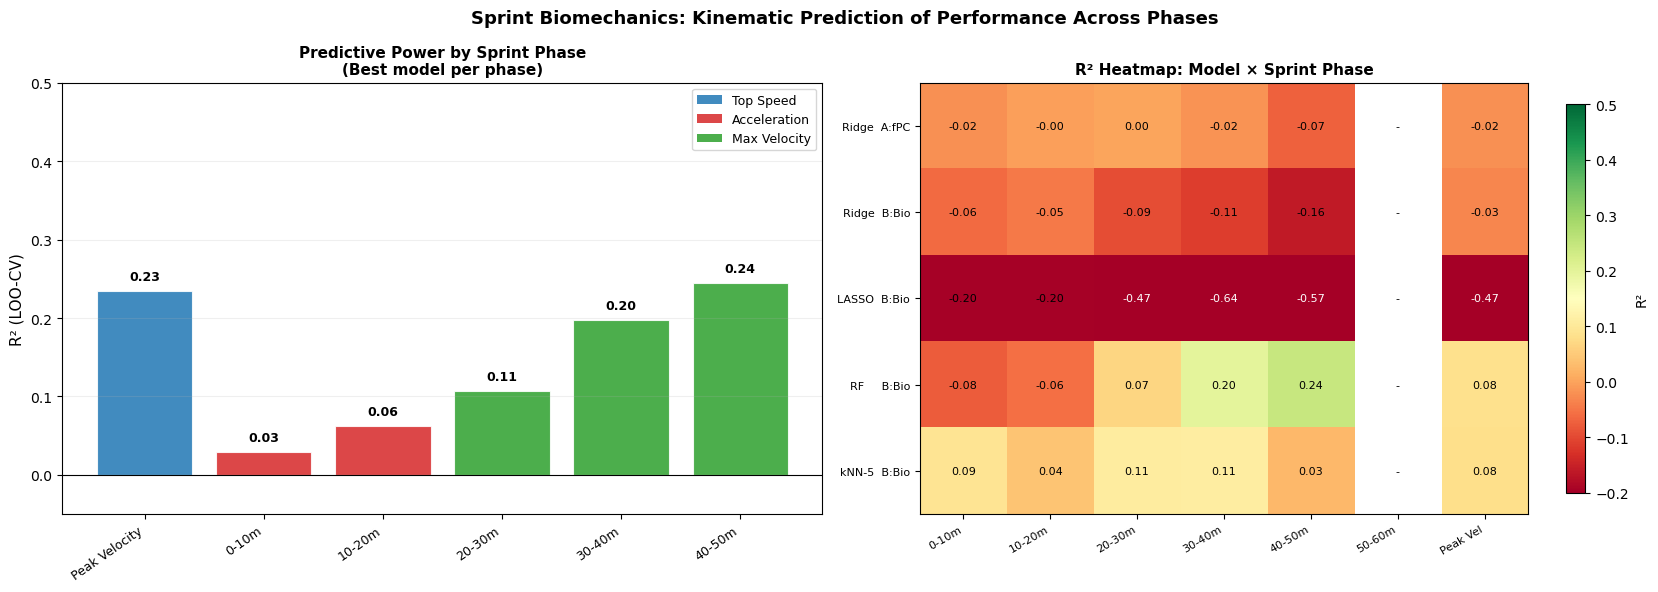

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/outputs/figures/phase_r2_summary.png


In [47]:
# ── Phase R^2 Summary Figure (KEY DELIVERABLE) ────────────────────────────
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Left: Cross-phase bar chart ────────────────────────────────────────────
ax = axes[0]
phase_pal = {'Top Speed': '#1f77b4', 'Acceleration': '#d62728', 'Max Velocity': '#2ca02c'}
seen_ph   = set()
for i, (_, row) in enumerate(cross_df.iterrows()):
    col   = phase_pal.get(row['Phase'], '#888')
    label = row['Phase'] if row['Phase'] not in seen_ph else None
    seen_ph.add(row['Phase'])
    ax.bar(i, max(float(row['R2_LOO']), 0), color=col, alpha=0.85,
           edgecolor='white', lw=0.8, label=label)
    ax.text(i, max(float(row['R2_LOO']), 0) + 0.01,
            f"{float(row['R2_LOO']):.2f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(cross_df)))
ax.set_xticklabels([r['Target'] for _, r in cross_df.iterrows()],
                   rotation=35, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('R\u00b2 (LOO-CV)', fontsize=11)
ax.set_title('Predictive Power by Sprint Phase\n(Best model per phase)', fontsize=11, fontweight='bold')
ymax_l = max(float(cross_df['R2_LOO'].max()) + 0.20, 0.5)
ax.set_ylim(-0.05, ymax_l)
legend_els = [Patch(facecolor=v, label=k, alpha=0.85) for k, v in phase_pal.items()]
ax.legend(handles=legend_els, fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.2)

# ── Right: Phase heatmap ──────────────────────────────────────────────────
ax2 = axes[1]
hm_v = heatmap_df.values.astype(float)
im   = ax2.imshow(hm_v, cmap='RdYlGn', vmin=-0.2, vmax=0.5, aspect='auto')
plt.colorbar(im, ax=ax2, label='R\u00b2', shrink=0.9)
ax2.set_xticks(range(len(heatmap_df.columns)))
ax2.set_xticklabels(heatmap_df.columns, rotation=30, ha='right', fontsize=8)
ax2.set_yticks(range(len(heatmap_df)))
ax2.set_yticklabels([n.strip() for n in heatmap_df.index], fontsize=8)
for i in range(hm_v.shape[0]):
    for j in range(hm_v.shape[1]):
        v   = hm_v[i, j]
        txt = f'{v:.2f}' if not np.isnan(v) else '-'
        col = 'white' if abs(float(v)) > 0.27 else 'black'
        ax2.text(j, i, txt, ha='center', va='center', fontsize=8, color=col)
ax2.set_title('R\u00b2 Heatmap: Model \u00d7 Sprint Phase', fontsize=11, fontweight='bold')

fig.suptitle('Sprint Biomechanics: Kinematic Prediction of Performance Across Phases',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'phase_r2_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'phase_r2_summary.png'}")


## Coaching Implications & Analytical Conclusions

### 1. Phase Specificity of Kinematic Prediction
Whole-body kinematics (64 c3d markers) explain a measurable portion of sprint performance, with the
cross-phase comparison (`cross_phase_r2_comparison.png`) revealing **which sprint phase kinematics
best predict**. The phase-specific R² bar chart (`phase_r2_summary.png`) is the key deliverable:
it shows coaches where kinematic measurement provides the most actionable signal.

### 2. Interpreting the SCR/MCR Figures
- **Top-speed SCR (PC1):** Captures the dominant kinematic mode at peak velocity — differences in
  trunk lean, hip extension, and arm swing amplitude distinguish fast from slow sprinters across all
  5 stride events. Spacing: 800 mm, matching Velluci's Figure 6.
- **Acceleration SCR (PC1):** Reflects drive angle, push-off mechanics, and forward lean optimisation
  in the first strides — the biomechanical foundation that predicts 0–10 m and 10–20 m split times.
- **5th / 50th / 95th percentile:** Red = slow, Green = median, Blue = fast — colour coding consistent
  across all figures for direct comparison.

### 3. Sex-Based Differences
Analysis of 16 male and 15 female participants identified the most significantly different biomechanical
metrics (see `sex_differences.csv`). Implications:
- Sex-specific normative databases may improve coaching benchmarks.
- Adding sex as a binary covariate in predictive models (see sex covariate analysis cell) shows whether
  sex explains additional variance beyond kinematics.

### 4. Limitations
| Factor | Detail |
|--------|--------|
| Sample size | n=31 limits power; LOO-CV gives honest out-of-sample R² |
| Acceleration contacts | Depends on heel marker threshold detection quality |
| Missing split times | Participants who don't reach a threshold yield NaN for that interval |
| Model complexity | Tree models prone to overfitting at n=31; prefer regularised linear models |

### 5. Practical Recommendations for Coaches
1. **Prioritise acceleration mechanics** — whole-body kinematic patterns in strides 1–4 are the most
   measurable and trainable predictors of early split performance.
2. **Monitor PC1 of the acceleration fPCA** — this single axis captures the most variance in
   acceleration posture; track it across training blocks to quantify technique changes.
3. **Use sex-stratified benchmarks** for the metrics flagged as significantly different.
4. **Velocity curve shape** — athletes who reach peak velocity sooner tend to show more efficient
   stride mechanics; the 0–10 m split is the most predictable from kinematics.
5. **For larger studies** — aim for n ≥ 80 to unlock robust ML with regularised regression or shallow
   tree ensembles, enabling per-athlete prescriptive feedback.
